# Notebook 4.1 – Refinamento do Modelo de Clustering

**Objetivo**: Refinar o modelo de clustering K-Means (k=6) com base nas seguintes melhorias:

1. **Remoção de outliers extremos** (7 complexos dos clusters 2 e 5)
2. **Remoção de features geográficas identitárias** (26 UFs one-hot)
3. **Remoção de features binárias de ruído** (caso_extremo_atividade, natureza_nao_informada)
4. **Re-treinamento com 893 complexos e 47 features**

---

## 🎯 Motivação do Refinamento

### Problemas Identificados no Notebook 4 (Exploratório):

**1. Outliers Extremos**
- Cluster 2 (6 complexos, 0.7%): 100% Brasil independente, baixíssima atividade
- Cluster 5 (1 complexo, 0.1%): Valores extremos (score_curadoria +9.0, sessões_especiais +11.5)
- **Decisão**: Remover para modelo refinado

**2. Geografia Subdimensionada**
- 26 features UF (one-hot) contribuem apenas **2.3% da variância total**
- Features contínuas dominam 93%+ da variância
- **Problema**: Distância ortogonal artificial penaliza similaridade comportamental
- **Decisão**: Remover UFs, usar apenas para profiling posterior

**3. Features de Ruído**
- `caso_extremo_atividade`: 7 casos (0.8%) - marca apenas os outliers
- `natureza_nao_informada`: 2 casos (0.2%) - ruído puro
- **Decisão**: Remover


---

## 🔧 Features Mantidas (47)

**Contínuas operacionais (35)**: Todas mantidas  
**Contexto estrutural agregado (8)**:
- `e_capital` (1 binária)
- `porte_municipio_cat_*` (4 one-hot)
- `faixa_renda_cat_*` (3 one-hot)

**Binárias operacionais (4)**:
- `baixa_atividade` (24 casos, 2.7%)
- `operacao_nao_comercial` (4 casos, 0.4% - obrigatória Art. 6º)
- `exibidor_independente` (178 casos, 19.8%)
- `natureza_nao_privada` (52 casos, 5.8%)

---

## Pipeline do Projeto

- **Notebook 0**: Ingestão e limpeza de sessões (2023–2025)
- **Notebook 0.5**: Enriquecimento com informações de produtoras/distribuidoras
- **Notebook 1**: EDA avançada por sessões/obras/complexos
- **Notebook 2**: Feature engineering por complexo (~50+ features)
- **Notebook 3**: Pré-processamento e seleção de features ✅
- **Notebook 4**: Clusterização exploratória (k=6) ✅
- **Notebook 4.1**: **Refinamento do modelo (ESTAMOS AQUI)** 🎯
- **Notebook 5**: Validação temporal dos clusters em 2025

---

## Dados de Entrada

Artefatos produzidos no **Notebook 4** (exploratório):

1. **df_features_final.parquet**: DataFrame (900, 78) com IDs, metadados e features originais
2. **lista_final_de_features.json**: Lista ordenada das 75 features
3. **metadata_preprocessamento.json**: Metadados do pré-processamento
4. **resumo_clusters_k6_exploratorio.parquet**: Resumo dos clusters do modelo exploratório
5. **resumo_geografico_k6_exploratorio.parquet**: Distribuição geográfica do modelo exploratório


---

# 1. Setup e Carregamento

## 1.1 Importações

In [1]:
# ===============================
# Manipulação de dados e sistema
# ===============================
import os
import json
import pickle
from pathlib import Path
from random import sample

import numpy as np
import pandas as pd

# ===============================
# Pré-processamento
# ===============================
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

# ===============================
# Clustering e redução de dimensão
# ===============================
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import hdbscan

# ===============================
# Métricas de avaliação
# ===============================
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    classification_report,
    confusion_matrix
)

# ===============================
# Modelos
# ===============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ===============================
# Estatística
# ===============================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ===============================
# Explainability
# ===============================
import shap

# ===============================
# Visualização
# ===============================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns

# ===============================
# Configurações gerais
# ===============================
import warnings
warnings.filterwarnings('ignore')

print("✅ Importações concluídas")


✅ Importações concluídas


In [2]:
%load_ext watermark
%watermark -a "Guilherme Gustavo Roca Arenales" --iversions

Author: Guilherme Gustavo Roca Arenales

matplotlib : 3.10.8
hdbscan    : 0.8.39
seaborn    : 0.13.2
numpy      : 2.3.4
json       : 2.0.9
statsmodels: 0.14.5
pandas     : 2.3.3
shap       : 0.48.0
sklearn    : 1.7.2



## 1.2 Configurações Gerais

In [3]:
# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Configurações definidas")

✅ Configurações definidas


## 1.3 Carregamento dos Dados

In [4]:
# Definir paths
BASES_DIR = Path('../Bases')
print("=" * 80)
print("CARREGAMENTO DE DADOS")
print("=" * 80)
# 1. Carregar DataFrame com features originais e metadados
df_features = pd.read_parquet(BASES_DIR / 'df_features_final.parquet')
print(f"\n✅ df_features_final.parquet carregado: shape {df_features.shape}")
# 2. Carregar lista de features (ordem das colunas)
with open(BASES_DIR / 'lista_final_de_features.json', 'r', encoding='utf-8') as f:
    features_info = json.load(f)
    feature_names = features_info['features']
print(f"✅ lista_final_de_features.json carregada: {len(feature_names)} features")
# 3. Carregar metadata (opcional, para log)
with open(BASES_DIR / 'metadata_preprocessamento.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)
print(f"✅ metadata_preprocessamento.json carregada")
print(f"   Processamento: {metadata.get('data_processamento', 'N/A')}")
print(f"   Notebook origem: {metadata.get('notebook', 'N/A')}")
# 4. Carregar resultados do modelo exploratório (Notebook 4)
df_resumo_exp = pd.read_parquet(BASES_DIR / 'resumo_clusters_k6_exploratorio.parquet')
print(f"\n✅ resumo_clusters_k6_exploratorio.parquet carregado: shape {df_resumo_exp.shape}")
df_geo_exp = pd.read_parquet(BASES_DIR / 'resumo_geografico_k6_exploratorio.parquet')
print(f"✅ resumo_geografico_k6_exploratorio.parquet carregado: shape {df_geo_exp.shape}")
print("\n" + "=" * 80)
print("✅ TODOS OS DADOS CARREGADOS COM SUCESSO")
print("=" * 80)

CARREGAMENTO DE DADOS

✅ df_features_final.parquet carregado: shape (900, 78)
✅ lista_final_de_features.json carregada: 75 features
✅ metadata_preprocessamento.json carregada
   Processamento: 2025-12-21T21:06:07.581801
   Notebook origem: Notebook_3_Preprocessamento.ipynb

✅ resumo_clusters_k6_exploratorio.parquet carregado: shape (6, 38)
✅ resumo_geografico_k6_exploratorio.parquet carregado: shape (6, 9)

✅ TODOS OS DADOS CARREGADOS COM SUCESSO


## 1.4 Verificações Iniciais e Identificação de Outliers

In [5]:
print("=" * 80)
print("IDENTIFICAÇÃO E ANÁLISE DETALHADA DOS OUTLIERS")
print("=" * 80)

# Verificar shapes
n_complexos = len(df_features)
n_features_originais = len(feature_names)

print(f"\n1. Dados carregados:")
print(f"   - Complexos: {n_complexos}")
print(f"   - Features originais: {n_features_originais}")
print(f"   - Colunas no DataFrame: {len(df_features.columns)}")

# Verificar se tem cluster_k6 do modelo exploratório
if 'cluster_k6' not in df_features.columns:
    print("\n⚠️  ATENÇÃO: Coluna 'cluster_k6' não encontrada!")
    print("   Será necessário carregar labels do Notebook 4 separadamente.")
    
    # Tentar carregar labels separadamente
    try:
        labels_exp = pd.read_parquet(BASES_DIR / 'labels_k6.parquet')
        df_features = df_features.merge(
            labels_exp[['REGISTRO_COMPLEXO', 'cluster_k6']], 
            on='REGISTRO_COMPLEXO', 
            how='left'
        )
        print("   ✅ Labels do modelo exploratório carregados de labels_k6.parquet")
    except FileNotFoundError:
        print("   ❌ ERRO: labels_k6.parquet não encontrado!")
        print("   Execute Notebook 4 completamente antes de prosseguir.")
        raise
else:
    print("\n✅ Coluna 'cluster_k6' encontrada no DataFrame")

# Distribuição dos clusters do modelo exploratório
print(f"\n2. Distribuição dos clusters (Modelo Exploratório):")
dist_exp = df_features['cluster_k6'].value_counts().sort_index()
for cluster_id, count in dist_exp.items():
    pct = (count / n_complexos) * 100
    print(f"   Cluster {cluster_id}: {count:4d} ({pct:5.1f}%)")

# ========================================================================
# CARREGAR DADOS CADASTRAIS DA ANCINE
# ========================================================================

print(f"\n3. Carregando dados cadastrais da ANCINE...")
print(f"   {'─' * 76}")

URL_SALAS = "https://dados.ancine.gov.br/dados-abertos/salas-de-exibicao-e-complexos.csv"

try:
    df_cadastro = pd.read_csv(
        URL_SALAS,
        encoding='utf-8',
        sep=';',
        dtype={'REGISTRO_COMPLEXO': str, 'REGISTRO_SALA': str}
    )
    
    # Limpar espaços em branco dos nomes das colunas
    df_cadastro.columns = df_cadastro.columns.str.strip()
    
    # Limpar espaços em branco dos valores de texto
    for col in df_cadastro.select_dtypes(include=['object']).columns:
        if df_cadastro[col].dtype == 'object':
            df_cadastro[col] = df_cadastro[col].str.strip()
    
    # Selecionar apenas colunas de interesse e remover duplicatas por complexo
    colunas_interesse = [
        'NOME_COMPLEXO',
        'REGISTRO_COMPLEXO',
        'SITUACAO_COMPLEXO',
        'DATA_SITUACAO_COMPLEXO',
        'MUNICIPIO_COMPLEXO',
        'UF_COMPLEXO',
        'OPERACAO_USUAL',
        'NOME_EXIBIDOR',
        'SITUACAO_EXIBIDOR',
        'NOME_GRUPO_EXIBIDOR'
    ]
    
    df_cadastro_complexos = df_cadastro[colunas_interesse].drop_duplicates(
        subset='REGISTRO_COMPLEXO'
    ).copy()
    
    print(f"   ✅ Dados cadastrais carregados: {len(df_cadastro_complexos)} complexos")
    
    # Verificar se os outliers estão no cadastro
    outliers_ids = df_features[df_features['cluster_k6'].isin([2, 5])]['REGISTRO_COMPLEXO'].unique()
    cadastrados = df_cadastro_complexos['REGISTRO_COMPLEXO'].isin(outliers_ids).sum()
    print(f"   ✅ Outliers encontrados no cadastro: {cadastrados}/{len(outliers_ids)}")
    
except Exception as e:
    print(f"   ⚠️  Erro ao carregar dados da ANCINE: {e}")
    print(f"   Prosseguindo sem informações cadastrais detalhadas.")
    df_cadastro_complexos = None

# ========================================================================
# IDENTIFICAÇÃO DETALHADA DOS CANDIDATOS A REMOÇÃO
# ========================================================================

print(f"\n4. Candidatos a remoção (Outliers dos Clusters 2 e 5):")
print(f"   {'═' * 76}")

outliers_cluster_2 = df_features[df_features['cluster_k6'] == 2].copy()
outliers_cluster_5 = df_features[df_features['cluster_k6'] == 5].copy()

# Merge com dados cadastrais se disponível
if df_cadastro_complexos is not None:
    outliers_cluster_2 = outliers_cluster_2.merge(
        df_cadastro_complexos,
        on='REGISTRO_COMPLEXO',
        how='left',
        suffixes=('', '_cadastro')
    )
    outliers_cluster_5 = outliers_cluster_5.merge(
        df_cadastro_complexos,
        on='REGISTRO_COMPLEXO',
        how='left',
        suffixes=('', '_cadastro')
    )

# ========================================================================
# EXIBIR CLUSTER 2
# ========================================================================

print(f"\n   🔴 CLUSTER 2 - {len(outliers_cluster_2)} complexos")
print(f"   {'─' * 76}")
print(f"   Perfil: Baixa atividade + 100% Brasil Independente\n")

for idx, row in outliers_cluster_2.iterrows():
    reg = row['REGISTRO_COMPLEXO']
    print(f"   📍 Complexo {reg}")
    print(f"      {'┄' * 72}")
    
    # Informações básicas
    if 'NOME_COMPLEXO' in row and pd.notna(row['NOME_COMPLEXO']):
        print(f"      Nome: {row['NOME_COMPLEXO']}")
    
    mun = row.get('MUNICIPIO_COMPLEXO', row.get('municipio', 'N/A'))
    uf = row.get('UF_COMPLEXO', row.get('UF', 'N/A'))
    print(f"      Localização: {mun}/{uf}")
    
    # Situação
    if 'SITUACAO_COMPLEXO' in row and pd.notna(row['SITUACAO_COMPLEXO']):
        situacao = row['SITUACAO_COMPLEXO']
        data_sit = row.get('DATA_SITUACAO_COMPLEXO', 'N/A')
        print(f"      Situação: {situacao} (desde {data_sit})")
    
    # Operação
    if 'OPERACAO_USUAL' in row and pd.notna(row['OPERACAO_USUAL']):
        print(f"      Operação usual: {row['OPERACAO_USUAL']}")
    
    # Exibidor
    if 'NOME_EXIBIDOR' in row and pd.notna(row['NOME_EXIBIDOR']):
        exibidor = row['NOME_EXIBIDOR']
        sit_exib = row.get('SITUACAO_EXIBIDOR', 'N/A')
        print(f"      Exibidor: {exibidor} ({sit_exib})")
    
    # Grupo
    if 'NOME_GRUPO_EXIBIDOR' in row and pd.notna(row['NOME_GRUPO_EXIBIDOR']):
        print(f"      Grupo: {row['NOME_GRUPO_EXIBIDOR']}")
    
    # Features do modelo
    if 'baixa_atividade' in row:
        print(f"      Baixa atividade: {'SIM' if row['baixa_atividade'] == 1 else 'NÃO'}")
    if 'pct_dias_operando' in row:
        print(f"      % dias operando: {row['pct_dias_operando']:.1%}")
    if 'num_salas' in row:
        print(f"      Número de salas: {row['num_salas']:.0f}")
    
    print()

# ========================================================================
# EXIBIR CLUSTER 5
# ========================================================================

print(f"\n   🔴 CLUSTER 5 - {len(outliers_cluster_5)} complexo(s)")
print(f"   {'─' * 76}")
print(f"   Perfil: Curadoria extrema (score +9.0) + Sessões especiais (+11.5)\n")

for idx, row in outliers_cluster_5.iterrows():
    reg = row['REGISTRO_COMPLEXO']
    print(f"   📍 Complexo #{reg}")
    print(f"      {'┄' * 72}")
    
    # Informações básicas
    if 'NOME_COMPLEXO' in row and pd.notna(row['NOME_COMPLEXO']):
        print(f"      Nome: {row['NOME_COMPLEXO']}")
    
    mun = row.get('MUNICIPIO_COMPLEXO', row.get('municipio', 'N/A'))
    uf = row.get('UF_COMPLEXO', row.get('UF', 'N/A'))
    print(f"      Localização: {mun}/{uf}")
    
    # Situação
    if 'SITUACAO_COMPLEXO' in row and pd.notna(row['SITUACAO_COMPLEXO']):
        situacao = row['SITUACAO_COMPLEXO']
        data_sit = row.get('DATA_SITUACAO_COMPLEXO', 'N/A')
        print(f"      Situação: {situacao} (desde {data_sit})")
    
    # Operação
    if 'OPERACAO_USUAL' in row and pd.notna(row['OPERACAO_USUAL']):
        print(f"      Operação usual: {row['OPERACAO_USUAL']}")
    
    # Exibidor
    if 'NOME_EXIBIDOR' in row and pd.notna(row['NOME_EXIBIDOR']):
        exibidor = row['NOME_EXIBIDOR']
        sit_exib = row.get('SITUACAO_EXIBIDOR', 'N/A')
        print(f"      Exibidor: {exibidor} ({sit_exib})")
    
    # Grupo
    if 'NOME_GRUPO_EXIBIDOR' in row and pd.notna(row['NOME_GRUPO_EXIBIDOR']):
        print(f"      Grupo: {row['NOME_GRUPO_EXIBIDOR']}")
    
    # Features do modelo (valores normalizados)
    if 'score_curadoria_scaled' in df_features.columns:
        score_val = df_features.loc[df_features['REGISTRO_COMPLEXO'] == reg, 'score_curadoria_scaled'].values
        if len(score_val) > 0:
            print(f"      Score curadoria (Z-score): {score_val[0]:+.2f}")
    
    if 'pct_sessoes_especiais_scaled' in df_features.columns:
        especiais_val = df_features.loc[df_features['REGISTRO_COMPLEXO'] == reg, 'pct_sessoes_especiais_scaled'].values
        if len(especiais_val) > 0:
            print(f"      Sessões especiais (Z-score): {especiais_val[0]:+.2f}")
    
    if 'num_salas' in row:
        print(f"      Número de salas: {row['num_salas']:.0f}")
    
    print()

# ========================================================================
# RESUMO DOS CANDIDATOS
# ========================================================================

n_candidatos = len(outliers_cluster_2) + len(outliers_cluster_5)
print(f"   {'═' * 76}")
print(f"   📊 TOTAL DE CANDIDATOS A REMOÇÃO: {n_candidatos}")
print(f"   {'═' * 76}")
print(f"\n   ℹ️  Analise os complexos acima e defina quais remover na próxima célula.\n")

print("=" * 80)

IDENTIFICAÇÃO E ANÁLISE DETALHADA DOS OUTLIERS

1. Dados carregados:
   - Complexos: 900
   - Features originais: 75
   - Colunas no DataFrame: 78

⚠️  ATENÇÃO: Coluna 'cluster_k6' não encontrada!
   Será necessário carregar labels do Notebook 4 separadamente.
   ✅ Labels do modelo exploratório carregados de labels_k6.parquet

2. Distribuição dos clusters (Modelo Exploratório):
   Cluster 0:   28 (  3.1%)
   Cluster 1:  396 ( 44.0%)
   Cluster 2:    1 (  0.1%)
   Cluster 3:  425 ( 47.2%)
   Cluster 4:    6 (  0.7%)
   Cluster 5:   44 (  4.9%)

3. Carregando dados cadastrais da ANCINE...
   ────────────────────────────────────────────────────────────────────────────
   ✅ Dados cadastrais carregados: 1980 complexos
   ✅ Outliers encontrados no cadastro: 45/45

4. Candidatos a remoção (Outliers dos Clusters 2 e 5):
   ════════════════════════════════════════════════════════════════════════════

   🔴 CLUSTER 2 - 1 complexos
   ───────────────────────────────────────────────────────────────

## 1.5 Configuração e Validação da Remoção de Complexos Outliers

In [6]:
# ========================================================================
# CONFIGURAÇÃO: LISTA MANUAL DE COMPLEXOS A REMOVER
# ========================================================================


COMPLEXOS_A_REMOVER = ['17778', '19846', '28343', '31000', '34842', '6616'
    # Exemplos (descomente os que deseja remover):
    # '14823',  # SINDICATO DOS BANCÁRIOS - Porto Alegre/RS
    # '17778',  # CINE ARCOS - Arcos/MG (FECHADO)
    # '19846',  # JOSUÊ'S CINE SANONTE - Santo Antônio do Monte/MG (FECHADO TEMP.)
    # ... adicionar outros conforme análise
]

print("=" * 80)
print("CONFIGURAÇÃO E VALIDAÇÃO DA REMOÇÃO DE OUTLIERS")
print("=" * 80)

print(f"\n⚙️  Complexos configurados para remoção: {len(COMPLEXOS_A_REMOVER)}")

if len(COMPLEXOS_A_REMOVER) > 0:
    print(f"\n   Lista de complexos a remover:")
    for reg in COMPLEXOS_A_REMOVER:
        # Buscar no df_features (para cluster, mun, uf)
        info = df_features[df_features['REGISTRO_COMPLEXO'] == reg]
        
        if len(info) > 0:
            row = info.iloc[0]
            mun = row.get('municipio', 'N/A')
            uf = row.get('UF', 'N/A')
            cluster = row.get('cluster_k6', 'N/A')
            
            # Buscar nome no cadastro ANCINE (onde ele REALMENTE está)
            cadastro_info = df_cadastro_complexos[df_cadastro_complexos['REGISTRO_COMPLEXO'] == reg]
            nome = cadastro_info.iloc[0]['NOME_COMPLEXO'] if len(cadastro_info) > 0 else 'N/A'
            
            nome_display = nome[:50] if len(nome) > 50 else nome
            print(f"      • {reg} - {nome_display} ({mun}/{uf}) [Cluster {cluster}]")
        else:
            print(f"      • {reg} - ⚠️  NÃO ENCONTRADO NO DATASET!")
else:
    print(f"   ℹ️  Lista vazia - nenhum complexo será removido")

# ========================================================================
# VALIDAÇÕES
# ========================================================================

print(f"\n{'─' * 80}")
print("VALIDAÇÕES:")
print(f"{'─' * 80}")

# 1. Verificar IDs válidos
ids_invalidos = [reg for reg in COMPLEXOS_A_REMOVER if reg not in df_features['REGISTRO_COMPLEXO'].values]

if len(ids_invalidos) > 0:
    print(f"\n❌ ERRO: IDs inválidos encontrados na lista COMPLEXOS_A_REMOVER:")
    for reg in ids_invalidos:
        print(f"   • {reg}")
    print(f"\nCorrija a lista antes de prosseguir!")
    raise ValueError("IDs inválidos na lista COMPLEXOS_A_REMOVER")
else:
    print(f"✅ Todos os IDs são válidos")

# 2. Verificar se são outliers dos clusters 2 ou 5
outliers_validos = df_features[df_features['cluster_k6'].isin([2, 5])]['REGISTRO_COMPLEXO'].values
ids_fora_outliers = [reg for reg in COMPLEXOS_A_REMOVER if reg not in outliers_validos]

if len(ids_fora_outliers) > 0:
    print(f"\n⚠️  ATENÇÃO: Complexos na lista que NÃO são dos clusters 2 ou 5:")
    for reg in ids_fora_outliers:
        cluster = df_features[df_features['REGISTRO_COMPLEXO'] == reg]['cluster_k6'].values[0]
        print(f"   • {reg} (Cluster {cluster})")
    print(f"\n   Recomenda-se remover apenas outliers dos clusters 2 e 5.")
    print(f"   Prossiga com cautela se intencional.")
else:
    print(f"✅ Todos os IDs são dos clusters 2 ou 5 (outliers)")

# ========================================================================
# ESTATÍSTICAS FINAIS
# ========================================================================

print(f"\n{'═' * 80}")
print("ESTATÍSTICAS FINAIS:")
print(f"{'═' * 80}")

n_total = len(df_features)
n_candidatos = len(df_features[df_features['cluster_k6'].isin([2, 5])])
n_remocao = len(COMPLEXOS_A_REMOVER)
n_final = n_total - n_remocao

pct_remocao = (n_remocao / n_total * 100) if n_total > 0 else 0

print(f"\n📊 Dataset original:")
print(f"   • Total de complexos: {n_total}")
print(f"   • Candidatos a remoção (Clusters 2+5): {n_candidatos} ({n_candidatos/n_total*100:.1f}%)")

print(f"\n⚠️  Remoção configurada:")
print(f"   • Complexos a remover: {n_remocao} ({pct_remocao:.1f}%)")
print(f"   • Complexos restantes: {n_final} ({100-pct_remocao:.1f}%)")

if n_remocao > 0:
    # Distribuição por cluster dos removidos
    print(f"\n   Distribuição dos removidos por cluster:")
    for cluster_id in [2, 5]:
        n_cluster = df_features[
            (df_features['cluster_k6'] == cluster_id) & 
            (df_features['REGISTRO_COMPLEXO'].isin(COMPLEXOS_A_REMOVER))
        ].shape[0]
        if n_cluster > 0:
            print(f"      • Cluster {cluster_id}: {n_cluster}")

print(f"\n{'═' * 80}")

if n_remocao == 0:
    print(f"ℹ️  MODO: Nenhuma remoção configurada")
    print(f"   O refinamento será executado com todos os {n_total} complexos.")
elif n_remocao == n_candidatos:
    print(f"✅ MODO: Remoção completa de outliers")
    print(f"   Todos os {n_candidatos} candidatos serão removidos.")
else:
    print(f"⚙️  MODO: Remoção parcial de outliers")
    print(f"   {n_remocao} de {n_candidatos} candidatos serão removidos.")

print(f"{'═' * 80}")
print(f"\n✅ Configuração validada")
print("=" * 80)

CONFIGURAÇÃO E VALIDAÇÃO DA REMOÇÃO DE OUTLIERS

⚙️  Complexos configurados para remoção: 6

   Lista de complexos a remover:
      • 17778 - CINE ARCOS (ARCOS/MG) [Cluster 4]
      • 19846 - JOSUÉ´S CINE SAMONTE (SANTO ANTÔNIO DO MONTE/MG) [Cluster 4]
      • 28343 - JOSUE'S CINE UNIVERSITÁRIO FORMIGA (FORMIGA/MG) [Cluster 4]
      • 31000 - JOSUÉ´S CINE HOTEL FAZENDA SOBRADINHO (CÓRREGO FUNDO/MG) [Cluster 4]
      • 34842 - JOSUÉS CINE PAINS (PAINS/MG) [Cluster 4]
      • 6616 - CINESESC (SÃO PAULO/SP) [Cluster 2]

────────────────────────────────────────────────────────────────────────────────
VALIDAÇÕES:
────────────────────────────────────────────────────────────────────────────────
✅ Todos os IDs são válidos

⚠️  ATENÇÃO: Complexos na lista que NÃO são dos clusters 2 ou 5:
   • 17778 (Cluster 4)
   • 19846 (Cluster 4)
   • 28343 (Cluster 4)
   • 31000 (Cluster 4)
   • 34842 (Cluster 4)

   Recomenda-se remover apenas outliers dos clusters 2 e 5.
   Prossiga com cautela se intenci

## 1.6 Resumo do Modelo Exploratório (Baseline)

In [7]:
print("=" * 80)
print("BASELINE - MODELO EXPLORATÓRIO (Notebook 4)")
print("=" * 80)

print("\n📊 Resumo dos Clusters:")
print("─" * 80)
display(df_resumo_exp)

print("\n📍 Distribuição Geográfica:")
print("─" * 80)
display(df_geo_exp)

print("\n" + "=" * 80)
print("✅ Baseline documentado - seguir para refinamento na Seção 2")
print("=" * 80)

BASELINE - MODELO EXPLORATÓRIO (Notebook 4)

📊 Resumo dos Clusters:
────────────────────────────────────────────────────────────────────────────────


,Cluster,N,Pct,desproporcao_blockbuster_scaled,entropia_distribuidora_scaled,entropia_faixa_horaria_scaled,entropia_modalidade_scaled,entropia_nacionalidade_scaled,ingressos_per_capita_municipio_scaled,intensidade_exibicao_scaled,num_obras_ultranicho_scaled,num_salas_scaled,obras_cinema_mundial_scaled,pct_dias_operando_scaled,pct_modalidade_b_scaled,pct_modalidade_c_scaled,pct_modalidade_d_scaled,pct_obras_cinema_mundial_scaled,pct_obras_exclusivas_scaled,pct_obras_nao_anglo_scaled,pct_obras_ultranicho_scaled,pct_publico_obras_top5_scaled,pct_sessoes_brasileiras_scaled,pct_sessoes_com_distribuidor_scaled,pct_sessoes_distrib_independente_scaled,pct_sessoes_especiais_scaled,pct_sessoes_legendadas_scaled,pct_sessoes_major_scaled,pct_sessoes_obras_top5_scaled,pct_sessoes_produtora_independente_scaled,perfil_independente_scaled,pib_per_capita_scaled,populacao_scaled,porte_medio_distribuidora_scaled,produtora_nivel_medio_complexo_scaled,score_curadoria_scaled,sessoes_por_dia_sala_scaled,volume_log_scaled
0,0,28,3.1%,-4.7073,-1.5117,-0.0071,0.6983,3.1467,-0.9589,-1.9653,-0.0522,-1.1601,-0.6751,-2.1600,1.5422,-0.0464,-0.1530,0.7001,0.1877,1.3512,0.3097,-3.6196,1.2918,-2.8962,0.6060,2.7681,-0.4043,-1.9073,-1.3764,0.7537,0.0098,0.5304,2.7095,-0.7844,-0.9673,0.6578,-0.7798,-2.1583
1,1,396,44.0%,0.0073,0.1240,-0.4843,0.2306,-0.4866,-0.0394,-0.4346,-0.1477,-0.6549,-0.7909,-0.2714,0.1687,-0.0435,0.1199,-0.7204,-0.1210,-0.6450,-0.1334,0.4424,-0.3360,0.2363,-0.1547,-0.2244,-0.3795,0.5341,0.5917,-0.1835,0.2547,-0.1232,-0.4445,0.2104,-0.0560,-0.6300,-0.4006,-0.5077
2,2,1,0.1%,-0.2355,-4.4177,-0.7380,7.4841,3.4088,-0.9478,-0.2586,14.0950,-1.1601,0.6572,-0.0453,-0.0684,29.2474,-0.1530,2.6509,16.5853,1.2807,14.0367,-0.6813,-0.2203,-10.9971,0.5640,11.4733,2.5478,-4.0919,-0.7440,-0.0997,1.7893,0.5449,2.7636,-2.0301,-2.8496,9.0138,-0.3847,-0.7788
3,3,425,47.2%,0.3630,0.3554,0.5706,-0.3040,0.0415,0.2080,0.6014,-0.1251,0.7828,0.6620,0.4787,-0.2549,-0.0461,-0.1027,0.3827,-0.1524,0.1602,-0.1322,0.1216,-0.0647,0.1793,-0.1266,-0.1730,0.1431,0.0091,-0.1065,-0.1532,-0.4631,0.0615,0.1621,0.1524,0.2964,0.2420,0.4742,0.7260
4,4,6,0.7%,-0.4381,-5.1204,-5.4591,-0.5167,-1.7073,-0.9273,-2.1256,-0.1623,-1.1601,-1.1384,-2.2895,-0.4058,-0.0278,-0.1530,-1.6873,-0.1732,5.0789,-0.1511,-3.3429,7.9956,0.2407,9.1659,-0.2503,-0.4414,-4.2105,-4.1855,8.3456,4.4064,-0.0874,-0.4730,-9.1386,-2.3744,-1.4207,-3.2005,-3.2161
5,5,44,4.9%,-0.5116,-2.7888,-0.3871,0.3171,2.1310,-0.8967,-0.3508,2.2723,-0.7444,1.2931,-0.4931,0.0186,0.2058,0.0352,2.5108,2.0890,2.6766,1.9817,-2.3812,1.7420,-1.7983,0.9673,1.7019,2.2928,-3.0140,-2.8326,1.5158,1.5326,0.1768,0.7130,-1.5742,-1.3549,2.9034,-0.0339,-0.6134



📍 Distribuição Geográfica:
────────────────────────────────────────────────────────────────────────────────


,Cluster,N,Pct_Capital,Pct_Interior,Top_UFs_List,Top_UFs_Str,Porte_Principal,Concentracao,N_UFs
0,0,28,100.0000,0.0000,"[SP, RJ]",SP + RJ,Metropole,100.0000,2
1,1,396,7.5758,92.4242,"[SP, MG, PR]",SP + MG + PR,Grande,44.1919,25
2,2,1,100.0000,0.0000,[SP],SP,Metropole,100.0000,1
3,3,425,47.7647,52.2353,"[SP, RJ, MG]",SP + RJ + MG,Metropole,55.5294,27
4,4,6,16.6667,83.3333,"[MG, RS]",MG + RS,Pequeno,100.0000,2
5,5,44,86.3636,13.6364,"[RJ, SP, BA]",RJ + SP + BA,Metropole,56.8182,17



✅ Baseline documentado - seguir para refinamento na Seção 2


# 2 Preparação dos Dados

## 2.1 Remoção dos Outliers

In [8]:
print("=" * 80)
print("SEÇÃO 2 - PREPARAÇÃO DOS DADOS PARA REFINAMENTO")
print("=" * 80)

print("\n" + "=" * 80)
print("2.1 - REMOÇÃO DOS OUTLIERS")
print("=" * 80)

# Contagem inicial
n_original = len(df_features)
n_remover = len(COMPLEXOS_A_REMOVER)

print(f"\nDataset original: {n_original} complexos")
print(f"Outliers a remover: {n_remover}")

# Filtrar dataset
df_features_clean = df_features[~df_features['REGISTRO_COMPLEXO'].isin(COMPLEXOS_A_REMOVER)].copy()

n_final = len(df_features_clean)
print(f"\n✅ Dataset limpo: {n_final} complexos")
print(f"   Removidos: {n_original - n_final}")

# Validação
outliers_restantes = df_features_clean['REGISTRO_COMPLEXO'].isin(COMPLEXOS_A_REMOVER).sum()
assert outliers_restantes == 0, f"❌ ERRO: {outliers_restantes} outliers ainda presentes!"

print(f"\n✅ Validação: nenhum outlier selecionado restante")

# Distribuição dos clusters após remoção
print(f"\nDistribuição dos clusters (pós-remoção):")
dist_clean = df_features_clean['cluster_k6'].value_counts().sort_index()
for cluster_id, count in dist_clean.items():
    pct = (count / n_final) * 100
    print(f"   Cluster {cluster_id}: {count:4d} ({pct:5.1f}%)")

print("\n" + "=" * 80)

SEÇÃO 2 - PREPARAÇÃO DOS DADOS PARA REFINAMENTO

2.1 - REMOÇÃO DOS OUTLIERS

Dataset original: 900 complexos
Outliers a remover: 6

✅ Dataset limpo: 894 complexos
   Removidos: 6

✅ Validação: nenhum outlier selecionado restante

Distribuição dos clusters (pós-remoção):
   Cluster 0:   28 (  3.1%)
   Cluster 1:  396 ( 44.3%)
   Cluster 3:  425 ( 47.5%)
   Cluster 4:    1 (  0.1%)
   Cluster 5:   44 (  4.9%)



## 2.2 Remoção de Features Geográficas (UFs)

In [9]:
print("=" * 80)
print("2.2 - REMOÇÃO DE FEATURES GEOGRÁFICAS (UFs)")
print("=" * 80)

# Identificar features de UF (one-hot encoding)
features_uf = [f for f in feature_names if f.startswith('UF_')]

print(f"\nFeatures de UF identificadas: {len(features_uf)}")
print(f"\nLista completa:")
for i, uf_feat in enumerate(features_uf, 1):
    uf = uf_feat.replace('UF_', '')
    print(f"   {i:2d}. {uf_feat:15s} ({uf})")

# Features que permanecem
features_manter = [f for f in feature_names if f not in features_uf]

print(f"\n{'─' * 80}")
print(f"RESUMO:")
print(f"{'─' * 80}")
print(f"   Features originais:        {len(feature_names)}")
print(f"   Features UF (removidas):   {len(features_uf)}")
print(f"   Features mantidas:         {len(features_manter)}")
print(f"{'─' * 80}")

# Atualizar lista de features
feature_names_clean = features_manter.copy()

print(f"\n✅ Lista de features atualizada: {len(feature_names_clean)} features")

print("\n" + "=" * 80)

2.2 - REMOÇÃO DE FEATURES GEOGRÁFICAS (UFs)

Features de UF identificadas: 26

Lista completa:
    1. UF_AL           (AL)
    2. UF_AM           (AM)
    3. UF_AP           (AP)
    4. UF_BA           (BA)
    5. UF_CE           (CE)
    6. UF_DF           (DF)
    7. UF_ES           (ES)
    8. UF_GO           (GO)
    9. UF_MA           (MA)
   10. UF_MG           (MG)
   11. UF_MS           (MS)
   12. UF_MT           (MT)
   13. UF_PA           (PA)
   14. UF_PB           (PB)
   15. UF_PE           (PE)
   16. UF_PI           (PI)
   17. UF_PR           (PR)
   18. UF_RJ           (RJ)
   19. UF_RN           (RN)
   20. UF_RO           (RO)
   21. UF_RR           (RR)
   22. UF_RS           (RS)
   23. UF_SC           (SC)
   24. UF_SE           (SE)
   25. UF_SP           (SP)
   26. UF_TO           (TO)

────────────────────────────────────────────────────────────────────────────────
RESUMO:
────────────────────────────────────────────────────────────────────────────────
   Fea

## 2.3 Features Restantes (Pós-Remoção UFs)

In [10]:
print("=" * 80)
print("2.3 - FEATURES RESTANTES (PÓS-REMOÇÃO UFs)")
print("=" * 80)

print(f"\nTotal de features mantidas: {len(feature_names_clean)}")

# Organizar por tipo
features_continuas = [f for f in feature_names_clean if f.endswith('_scaled')]
features_porte = [f for f in feature_names_clean if f.startswith('porte_municipio_cat_')]
features_renda = [f for f in feature_names_clean if f.startswith('faixa_renda_cat_')]
features_binarias = [f for f in feature_names_clean if f in [
    'baixa_atividade', 'e_capital', 'operacao_nao_comercial',
    'natureza_nao_informada', 'exibidor_independente', 
    'natureza_nao_privada', 'caso_extremo_atividade'
]]

print(f"\n{'─' * 80}")
print(f"COMPOSIÇÃO DAS {len(feature_names_clean)} FEATURES:")
print(f"{'─' * 80}")
print(f"   Contínuas (_scaled):           {len(features_continuas):2d}")
print(f"   Porte município (one-hot):     {len(features_porte):2d}")
print(f"   Faixa renda (one-hot):         {len(features_renda):2d}")
print(f"   Binárias operacionais:         {len(features_binarias):2d}")
print(f"{'─' * 80}")

print(f"\n📊 FEATURES CONTÍNUAS ({len(features_continuas)}):")
for i, feat in enumerate(features_continuas, 1):
    nome = feat.replace('_scaled', '').replace('_', ' ')
    print(f"   {i:2d}. {feat}")

print(f"\n📍 CONTEXTO ESTRUTURAL ({len(features_porte) + len(features_renda)}):")
print(f"\n   Porte do município ({len(features_porte)}):")
for feat in features_porte:
    print(f"      • {feat}")
print(f"\n   Faixa de renda ({len(features_renda)}):")
for feat in features_renda:
    print(f"      • {feat}")

print(f"\n🔘 BINÁRIAS OPERACIONAIS ({len(features_binarias)}):")
for feat in features_binarias:
    # Mostrar distribuição
    count = df_features_clean[feat].sum() if feat in df_features_clean.columns else 0
    pct = (count / len(df_features_clean) * 100) if len(df_features_clean) > 0 else 0
    print(f"   • {feat:30s}: {count:3d} ({pct:4.1f}%)")

print("\n" + "=" * 80)

2.3 - FEATURES RESTANTES (PÓS-REMOÇÃO UFs)

Total de features mantidas: 49

────────────────────────────────────────────────────────────────────────────────
COMPOSIÇÃO DAS 49 FEATURES:
────────────────────────────────────────────────────────────────────────────────
   Contínuas (_scaled):           35
   Porte município (one-hot):      4
   Faixa renda (one-hot):          3
   Binárias operacionais:          7
────────────────────────────────────────────────────────────────────────────────

📊 FEATURES CONTÍNUAS (35):
    1. num_salas_scaled
    2. pct_dias_operando_scaled
    3. sessoes_por_dia_sala_scaled
    4. volume_log_scaled
    5. pct_sessoes_major_scaled
    6. pct_sessoes_distrib_independente_scaled
    7. porte_medio_distribuidora_scaled
    8. pct_sessoes_com_distribuidor_scaled
    9. pct_sessoes_produtora_independente_scaled
   10. produtora_nivel_medio_complexo_scaled
   11. pct_sessoes_brasileiras_scaled
   12. pct_sessoes_especiais_scaled
   13. pct_modalidade_b_scaled


 ## 2.4 Remoção de Features Adicionais

In [11]:
print("=" * 80)
print("2.4 - REMOÇÃO DE FEATURES ADICIONAIS")
print("=" * 80)

# ========================================================================
# CONFIGURAÇÃO: Features adicionais a remover
# ========================================================================

FEATURES_REMOVER_ADICIONAIS = [
    #'caso_extremo_atividade', 
]

print(f"\nFeatures adicionais a remover: {len(FEATURES_REMOVER_ADICIONAIS)}")

if len(FEATURES_REMOVER_ADICIONAIS) > 0:
    print(f"\nLista:")
    for feat in FEATURES_REMOVER_ADICIONAIS:
        # Verificar se existe
        if feat in feature_names_clean:
            # Mostrar estatísticas se for binária
            if feat in df_features_clean.columns:
                count = df_features_clean[feat].sum()
                pct = (count / len(df_features_clean) * 100)
                print(f"   • {feat:30s}: {count:3d} ({pct:4.1f}%)")
            else:
                print(f"   • {feat}")
        else:
            print(f"   ⚠️  {feat} - NÃO ENCONTRADA na lista!")
    
    # Remover das features
    features_remover_validas = [f for f in FEATURES_REMOVER_ADICIONAIS if f in feature_names_clean]
    feature_names_clean = [f for f in feature_names_clean if f not in features_remover_validas]
    
    print(f"\n✅ Removidas {len(features_remover_validas)} features")
else:
    print(f"\n   ℹ️  Lista vazia - nenhuma feature adicional removida")

# ========================================================================
# RESUMO FINAL DE REMOÇÕES
# ========================================================================

print(f"\n{'═' * 80}")
print(f"RESUMO TOTAL DE REMOÇÕES:")
print(f"{'═' * 80}")

features_removidas_total = features_uf + FEATURES_REMOVER_ADICIONAIS

print(f"\n   Features originais:              {len(feature_names)}")
print(f"   Features removidas (UFs):        {len(features_uf)}")
print(f"   Features removidas (adicionais): {len(FEATURES_REMOVER_ADICIONAIS)}")
print(f"   {'─' * 76}")
print(f"   TOTAL REMOVIDO:                  {len(features_removidas_total)}")
print(f"   FEATURES FINAIS:                 {len(feature_names_clean)}")
print(f"{'═' * 80}")

print(f"\nLista completa de features removidas ({len(features_removidas_total)}):")
for i, feat in enumerate(features_removidas_total, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 80)

2.4 - REMOÇÃO DE FEATURES ADICIONAIS

Features adicionais a remover: 0

   ℹ️  Lista vazia - nenhuma feature adicional removida

════════════════════════════════════════════════════════════════════════════════
RESUMO TOTAL DE REMOÇÕES:
════════════════════════════════════════════════════════════════════════════════

   Features originais:              75
   Features removidas (UFs):        26
   Features removidas (adicionais): 0
   ────────────────────────────────────────────────────────────────────────────
   TOTAL REMOVIDO:                  26
   FEATURES FINAIS:                 49
════════════════════════════════════════════════════════════════════════════════

Lista completa de features removidas (26):
    1. UF_AL
    2. UF_AM
    3. UF_AP
    4. UF_BA
    5. UF_CE
    6. UF_DF
    7. UF_ES
    8. UF_GO
    9. UF_MA
   10. UF_MG
   11. UF_MS
   12. UF_MT
   13. UF_PA
   14. UF_PB
   15. UF_PE
   16. UF_PI
   17. UF_PR
   18. UF_RJ
   19. UF_RN
   20. UF_RO
   21. UF_RR
   22. UF_

## 2.5 Extração da Matriz X_clean

In [12]:
print("=" * 80)
print("2.5 - EXTRAÇÃO DA MATRIZ DE FEATURES")
print("=" * 80)

print(f"\nExtraindo matriz X_clean com {len(feature_names_clean)} features...")

# Extrair apenas as features que permaneceram
X_clean = df_features_clean[feature_names_clean].values

print(f"\n✅ Matriz X_clean extraída")
print(f"   Shape: {X_clean.shape}")
print(f"   Dtype: {X_clean.dtype}")

# Verificações de integridade
n_nulls = np.isnan(X_clean).sum()
n_infs = np.isinf(X_clean).sum()

print(f"\nVerificações de integridade:")
print(f"   Valores nulos:     {n_nulls}")
print(f"   Valores infinitos: {n_infs}")

if n_nulls > 0:
    print(f"   ❌ ERRO: Matriz contém valores nulos!")
    raise ValueError("Matriz X_clean contém valores nulos")

if n_infs > 0:
    print(f"   ❌ ERRO: Matriz contém valores infinitos!")
    raise ValueError("Matriz X_clean contém valores infinitos")

print(f"   ✅ Nenhum valor nulo ou infinito")

# Estatísticas básicas (features ainda estão com normalização antiga)
print(f"\nEstatísticas das features (normalização antiga):")
print(f"   Média global:  {X_clean.mean():.6f}")
print(f"   Std global:    {X_clean.std():.6f}")
print(f"   Min global:    {X_clean.min():.2f}")
print(f"   Max global:    {X_clean.max():.2f}")

print("\n" + "=" * 80)

2.5 - EXTRAÇÃO DA MATRIZ DE FEATURES

Extraindo matriz X_clean com 49 features...

✅ Matriz X_clean extraída
   Shape: (894, 49)
   Dtype: float64

Verificações de integridade:
   Valores nulos:     0
   Valores infinitos: 0
   ✅ Nenhum valor nulo ou infinito

Estatísticas das features (normalização antiga):
   Média global:  0.044544
   Std global:    0.799344
   Min global:    -10.87
   Max global:    22.14



## 2.6 Re-normalização das Features Contínuas

In [13]:
print("=" * 80)
print("2.6 - RE-NORMALIZAÇÃO DAS FEATURES CONTÍNUAS")
print("=" * 80)

# Identificar features contínuas (sufixo _scaled) e não-contínuas
features_continuas_idx = [i for i, f in enumerate(feature_names_clean) if f.endswith('_scaled')]
features_nao_continuas_idx = [i for i, f in enumerate(feature_names_clean) if not f.endswith('_scaled')]

n_continuas = len(features_continuas_idx)
n_nao_continuas = len(features_nao_continuas_idx)

print(f"\nComposição da matriz:")
print(f"   Features contínuas (_scaled):     {n_continuas}")
print(f"   Features não-contínuas (one-hot): {n_nao_continuas}")
print(f"   Total:                            {len(feature_names_clean)}")

# Separar features contínuas e não-contínuas
X_continuas = X_clean[:, features_continuas_idx]
X_nao_continuas = X_clean[:, features_nao_continuas_idx]

print(f"\n{'─' * 80}")
print(f"ANTES DA RE-NORMALIZAÇÃO (features contínuas):")
print(f"{'─' * 80}")
print(f"   Shape: {X_continuas.shape}")
print(f"   Média: {X_continuas.mean():.6f}")
print(f"   Std:   {X_continuas.std():.6f}")
print(f"   Min:   {X_continuas.min():.2f}")
print(f"   Max:   {X_continuas.max():.2f}")

# Re-normalizar features contínuas
scaler = StandardScaler()
X_continuas_normalized = scaler.fit_transform(X_continuas)

print(f"\n{'─' * 80}")
print(f"APÓS RE-NORMALIZAÇÃO (features contínuas):")
print(f"{'─' * 80}")
print(f"   Shape: {X_continuas_normalized.shape}")
print(f"   Média: {X_continuas_normalized.mean():.6f}")
print(f"   Std:   {X_continuas_normalized.std():.6f}")
print(f"   Min:   {X_continuas_normalized.min():.2f}")
print(f"   Max:   {X_continuas_normalized.max():.2f}")

# Reconstruir matriz completa
X_clean_normalized = np.zeros_like(X_clean)
X_clean_normalized[:, features_continuas_idx] = X_continuas_normalized
X_clean_normalized[:, features_nao_continuas_idx] = X_nao_continuas

print(f"\n{'═' * 80}")
print(f"MATRIZ FINAL RE-NORMALIZADA:")
print(f"{'═' * 80}")
print(f"   Shape: {X_clean_normalized.shape}")
print(f"   Média global: {X_clean_normalized.mean():.6f}")
print(f"   Std global:   {X_clean_normalized.std():.6f}")
print(f"   Min global:   {X_clean_normalized.min():.2f}")
print(f"   Max global:   {X_clean_normalized.max():.2f}")

# Validação final
n_nulls = np.isnan(X_clean_normalized).sum()
n_infs = np.isinf(X_clean_normalized).sum()

print(f"\nValidação final:")
print(f"   Valores nulos:     {n_nulls}")
print(f"   Valores infinitos: {n_infs}")

assert n_nulls == 0, "❌ ERRO: Matriz normalizada contém nulos!"
assert n_infs == 0, "❌ ERRO: Matriz normalizada contém infinitos!"

print(f"   ✅ Matriz válida e pronta para clustering")

# Substituir X_clean pela versão normalizada
X_final = X_clean_normalized

print(f"\n✅ X_final criado: {X_final.shape}")

print("\n" + "=" * 80)

2.6 - RE-NORMALIZAÇÃO DAS FEATURES CONTÍNUAS

Composição da matriz:
   Features contínuas (_scaled):     35
   Features não-contínuas (one-hot): 14
   Total:                            49

────────────────────────────────────────────────────────────────────────────────
ANTES DA RE-NORMALIZAÇÃO (features contínuas):
────────────────────────────────────────────────────────────────────────────────
   Shape: (894, 35)
   Média: 0.000808
   Std:   0.914196
   Min:   -10.87
   Max:   22.14

────────────────────────────────────────────────────────────────────────────────
APÓS RE-NORMALIZAÇÃO (features contínuas):
────────────────────────────────────────────────────────────────────────────────
   Shape: (894, 35)
   Média: -0.000000
   Std:   1.000000
   Min:   -11.66
   Max:   24.98

════════════════════════════════════════════════════════════════════════════════
MATRIZ FINAL RE-NORMALIZADA:
════════════════════════════════════════════════════════════════════════════════
   Shape: (894, 49)
 

## 2.7 Resumo Comparativo Final

In [14]:
print("=" * 80)
print("2.7 - RESUMO COMPARATIVO: EXPLORATÓRIO vs REFINADO")
print("=" * 80)

# ========================================================================
# DADOS DO MODELO EXPLORATÓRIO (Notebook 4)
# ========================================================================

n_exp = 900
features_exp = 75
features_uf_exp = 26
features_continuas_exp = 35
features_contexto_exp = 8  # porte (4) + renda (3) + e_capital (1)
features_binarias_exp = 7
silhouette_exp = 0.2024
davies_bouldin_exp = 1.274
calinski_exp = 166.7

# ========================================================================
# DADOS DO MODELO REFINADO (Atual)
# ========================================================================

n_ref = len(df_features_clean)
features_ref = len(feature_names_clean)
features_uf_ref = 0
outliers_removidos = len(COMPLEXOS_A_REMOVER)
features_removidas_total = len(features_uf) + len(FEATURES_REMOVER_ADICIONAIS)

# Contar por tipo
features_continuas_ref = len([f for f in feature_names_clean if f.endswith('_scaled')])
features_porte_ref = len([f for f in feature_names_clean if f.startswith('porte_municipio_cat_')])
features_renda_ref = len([f for f in feature_names_clean if f.startswith('faixa_renda_cat_')])
features_ecapital_ref = 1 if 'e_capital' in feature_names_clean else 0
features_binarias_ref = len([f for f in feature_names_clean if f in [
    'baixa_atividade', 'operacao_nao_comercial', 'exibidor_independente', 'natureza_nao_privada'
]])

features_contexto_ref = features_porte_ref + features_renda_ref + features_ecapital_ref

# Calcular candidatos vs removidos
n_candidatos = 7  # Clusters 2 (6) + 5 (1) do modelo exploratório
n_mantidos = n_candidatos - outliers_removidos

# ========================================================================
# TABELA COMPARATIVA
# ========================================================================

print("\n" + "=" * 80)
print("COMPARAÇÃO MODELO EXPLORATÓRIO vs REFINADO")
print("=" * 80)

comparacao = {
    'Aspecto': [
        'N complexos',
        'N features',
        'Features UF (one-hot)',
        'Features contínuas',
        'Features contexto agregado',
        'Features binárias',
        'Outliers',
        'Normalização'
    ],
    'Exploratório (NB 4)': [
        f'{n_exp}',
        f'{features_exp}',
        f'{features_uf_exp}',
        f'{features_continuas_exp}',
        f'{features_contexto_exp}',
        f'{features_binarias_exp}',
        f'{n_candidatos} (clusters 2, 5)',
        'Com outliers'
    ],
    'Refinado (NB 4.1)': [
        f'{n_ref} (-{n_exp - n_ref})',
        f'{features_ref} (-{features_exp - features_ref})',
        f'{features_uf_ref} (removidas)',
        f'{features_continuas_ref}',
        f'{features_contexto_ref}',
        f'{features_binarias_ref}',
        f'{n_mantidos} ({outliers_removidos} removidos)',
        'Menos outliers'
    ]
}

df_comparacao = pd.DataFrame(comparacao)
display(df_comparacao)

# ========================================================================
# ESTATÍSTICAS DETALHADAS
# ========================================================================

print("\n" + "─" * 80)
print("DETALHAMENTO DO MODELO REFINADO:")
print("─" * 80)

print(f"\n📊 Complexos:")
print(f"   • Dataset original:        {n_exp}")
print(f"   • Candidatos a remoção:    {n_candidatos} (clusters 2+5)")
print(f"   • Outliers removidos:      {outliers_removidos}")
print(f"   • Outliers mantidos:       {n_mantidos}")
print(f"   • Dataset refinado:        {n_ref} ({n_ref/n_exp*100:.1f}%)")

print(f"\n🔧 Features:")
print(f"   • Features originais:      {features_exp}")
print(f"   • Features removidas:      {features_removidas_total}")
print(f"     - UFs (one-hot):         {len(features_uf)}")
print(f"     - Adicionais:            {len(FEATURES_REMOVER_ADICIONAIS)}")
print(f"   • Features finais:         {features_ref}")

print(f"\n📐 Composição final:")
print(f"   • Contínuas (_scaled):     {features_continuas_ref} ({features_continuas_ref/features_ref*100:.1f}%)")
print(f"   • Contexto agregado:       {features_contexto_ref} ({features_contexto_ref/features_ref*100:.1f}%)")
print(f"   • Binárias operacionais:   {features_binarias_ref} ({features_binarias_ref/features_ref*100:.1f}%)")

print(f"\n📊 Matriz final:")
print(f"   • Shape: {X_final.shape}")
print(f"   • Dtype: {X_final.dtype}")
print(f"   • Média: {X_final.mean():.6f} (≈ 0)")
print(f"   • Std:   {X_final.std():.6f} (≈ 1)")

print("\n" + "=" * 80)
print("✅ PREPARAÇÃO DOS DADOS CONCLUÍDA")
print("=" * 80)
print("\n   Pronto para Seção 3 - Clustering Refinado com k=6")
print("=" * 80)

2.7 - RESUMO COMPARATIVO: EXPLORATÓRIO vs REFINADO

COMPARAÇÃO MODELO EXPLORATÓRIO vs REFINADO


,Aspecto,Exploratório (NB 4),Refinado (NB 4.1)
0,N complexos,900,894 (-6)
1,N features,75,49 (-26)
2,Features UF (one-hot),26,0 (removidas)
3,Features contínuas,35,35
4,Features contexto agregado,8,8
5,Features binárias,7,4
6,Outliers,"7 (clusters 2, 5)",1 (6 removidos)
7,Normalização,Com outliers,Menos outliers



────────────────────────────────────────────────────────────────────────────────
DETALHAMENTO DO MODELO REFINADO:
────────────────────────────────────────────────────────────────────────────────

📊 Complexos:
   • Dataset original:        900
   • Candidatos a remoção:    7 (clusters 2+5)
   • Outliers removidos:      6
   • Outliers mantidos:       1
   • Dataset refinado:        894 (99.3%)

🔧 Features:
   • Features originais:      75
   • Features removidas:      26
     - UFs (one-hot):         26
     - Adicionais:            0
   • Features finais:         49

📐 Composição final:
   • Contínuas (_scaled):     35 (71.4%)
   • Contexto agregado:       8 (16.3%)
   • Binárias operacionais:   4 (8.2%)

📊 Matriz final:
   • Shape: (894, 49)
   • Dtype: float64
   • Média: 0.043967 (≈ 0)
   • Std:   0.869666 (≈ 1)

✅ PREPARAÇÃO DOS DADOS CONCLUÍDA

   Pronto para Seção 3 - Clustering Refinado com k=6


# 3 Exploração do Espaço de Features e escolha de K

## 3.1 Diagnóstico do Espaço de Features Refinado

In [15]:
print("=" * 80)
print("SEÇÃO 3 - EXPLORAÇÃO DO ESPAÇO REFINADO E ESCOLHA DE k")
print("=" * 80)

print("\n" + "=" * 80)
print("3.1 - DIAGNÓSTICO DO ESPAÇO DE FEATURES REFINADO")
print("=" * 80)

# Converter para DataFrame para análise
X_df = pd.DataFrame(X_final, columns=feature_names_clean)

print(f"\nDimensões do espaço refinado:")
print(f"   • Complexos: {X_final.shape[0]}")
print(f"   • Features:  {X_final.shape[1]}")
print(f"   • Dtype:     {X_final.dtype}")

# Estatísticas globais
print(f"\nEstatísticas globais:")
print(f"   • Média:  {X_final.mean():.6f}")
print(f"   • Std:    {X_final.std():.6f}")
print(f"   • Min:    {X_final.min():.2f}")
print(f"   • Max:    {X_final.max():.2f}")

# Estatísticas descritivas das primeiras 10 features
print(f"\n{'─' * 80}")
print("Estatísticas descritivas (primeiras 10 features):")
print(f"{'─' * 80}")
display(X_df.iloc[:, :10].describe())

# Separar features por tipo
features_continuas = [f for f in feature_names_clean if f.endswith('_scaled')]
features_nao_continuas = [f for f in feature_names_clean if not f.endswith('_scaled')]

print(f"\n{'─' * 80}")
print("COMPOSIÇÃO DAS FEATURES:")
print(f"{'─' * 80}")
print(f"   Features contínuas (_scaled):     {len(features_continuas)} (var=1.0 por normalização)")
print(f"   Features não-contínuas:           {len(features_nao_continuas)} (one-hot, binárias)")

# Análise de variância APENAS para features não-normalizadas
if len(features_nao_continuas) > 0:
    X_nao_cont = X_df[features_nao_continuas]
    variancias_nao_cont = X_nao_cont.var().sort_values(ascending=False)
    
    print(f"\n{'─' * 80}")
    print(f"VARIÂNCIA DAS FEATURES NÃO-NORMALIZADAS ({len(features_nao_continuas)}):")
    print(f"{'─' * 80}")
    
    for i, (feat, var) in enumerate(variancias_nao_cont.items(), 1):
        # Identificar tipo
        if feat.startswith('porte_municipio_cat_'):
            tipo = "one-hot porte"
        elif feat.startswith('faixa_renda_cat_'):
            tipo = "one-hot renda"
        elif feat in ['baixa_atividade', 'e_capital', 'operacao_nao_comercial', 
                      'exibidor_independente', 'natureza_nao_privada']:
            tipo = "binária"
        else:
            tipo = "outra"
        
        print(f"   {i:2d}. {feat:35s}: {var:.4f}  [{tipo}]")

# Comparação com modelo exploratório (conceitual)
print(f"\n{'═' * 80}")
print("COMPARAÇÃO CONCEITUAL COM MODELO EXPLORATÓRIO:")
print(f"{'═' * 80}")
print(f"   Exploratório:  900 complexos × 75 features")
print(f"   Refinado:      {X_final.shape[0]} complexos × {X_final.shape[1]} features")
print(f"   Redução:       -{900 - X_final.shape[0]} complexos, -{75 - X_final.shape[1]} features")
print(f"\n   → Espaço mais compacto e focado em features comportamentais")

print("\n" + "=" * 80)

SEÇÃO 3 - EXPLORAÇÃO DO ESPAÇO REFINADO E ESCOLHA DE k

3.1 - DIAGNÓSTICO DO ESPAÇO DE FEATURES REFINADO

Dimensões do espaço refinado:
   • Complexos: 894
   • Features:  49
   • Dtype:     float64

Estatísticas globais:
   • Média:  0.043967
   • Std:    0.869666
   • Min:    -11.66
   • Max:    24.98

────────────────────────────────────────────────────────────────────────────────
Estatísticas descritivas (primeiras 10 features):
────────────────────────────────────────────────────────────────────────────────


,num_salas_scaled,pct_dias_operando_scaled,sessoes_por_dia_sala_scaled,volume_log_scaled,pct_sessoes_major_scaled,pct_sessoes_distrib_independente_scaled,porte_medio_distribuidora_scaled,pct_sessoes_com_distribuidor_scaled,pct_sessoes_produtora_independente_scaled,produtora_nivel_medio_complexo_scaled
count,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000
std,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006
min,-1.1693,-2.9170,-4.3209,-5.4419,-4.7015,-0.4242,-10.1658,-11.6552,-1.2542,-8.0943
25%,-0.7956,-0.0563,-0.6154,-0.5178,-0.0700,-0.4242,0.1084,0.1551,-0.3997,-0.0733
50%,-0.0481,0.5574,0.2145,0.2667,0.1573,-0.2513,0.2378,0.2480,-0.2179,0.2314
75%,0.6994,0.5816,0.7419,0.7236,0.4856,-0.0950,0.3447,0.3095,0.0013,0.4251
max,5.1843,0.5913,2.5368,1.5645,1.6927,10.6483,0.4935,0.3491,10.1385,2.6273



────────────────────────────────────────────────────────────────────────────────
COMPOSIÇÃO DAS FEATURES:
────────────────────────────────────────────────────────────────────────────────
   Features contínuas (_scaled):     35 (var=1.0 por normalização)
   Features não-contínuas:           14 (one-hot, binárias)

────────────────────────────────────────────────────────────────────────────────
VARIÂNCIA DAS FEATURES NÃO-NORMALIZADAS (14):
────────────────────────────────────────────────────────────────────────────────
    1. faixa_renda_cat_Media_Baixa        : 0.2236  [one-hot renda]
    2. e_capital                          : 0.2232  [binária]
    3. porte_municipio_cat_Metropole      : 0.2074  [one-hot porte]
    4. faixa_renda_cat_Media_Alta         : 0.1913  [one-hot renda]
    5. exibidor_independente              : 0.1596  [binária]
    6. faixa_renda_cat_Baixa              : 0.1521  [one-hot renda]
    7. porte_municipio_cat_Medio          : 0.1212  [one-hot porte]
    8. natur

## 3.2 Matriz de Correlação (Top 30 Features)

3.2 - MATRIZ DE CORRELAÇÃO (TOP 30 FEATURES CONTÍNUAS)

Total de features contínuas: 35

Top 30 features selecionadas por variância de correlação:
    1. pct_sessoes_major_scaled                      (var_corr: 0.3032)
    2. pct_obras_nao_anglo_scaled                    (var_corr: 0.2696)
    3. porte_medio_distribuidora_scaled              (var_corr: 0.2682)
    4. entropia_distribuidora_scaled                 (var_corr: 0.2659)
    5. pct_publico_obras_top5_scaled                 (var_corr: 0.2657)
    6. pct_sessoes_obras_top5_scaled                 (var_corr: 0.2513)
    7. entropia_nacionalidade_scaled                 (var_corr: 0.2356)
    8. pct_sessoes_distrib_independente_scaled       (var_corr: 0.2342)
    9. pct_sessoes_brasileiras_scaled                (var_corr: 0.2309)
   10. score_curadoria_scaled                        (var_corr: 0.2170)
   11. pct_sessoes_produtora_independente_scaled     (var_corr: 0.2101)
   12. pct_sessoes_com_distribuidor_scaled           (var_cor

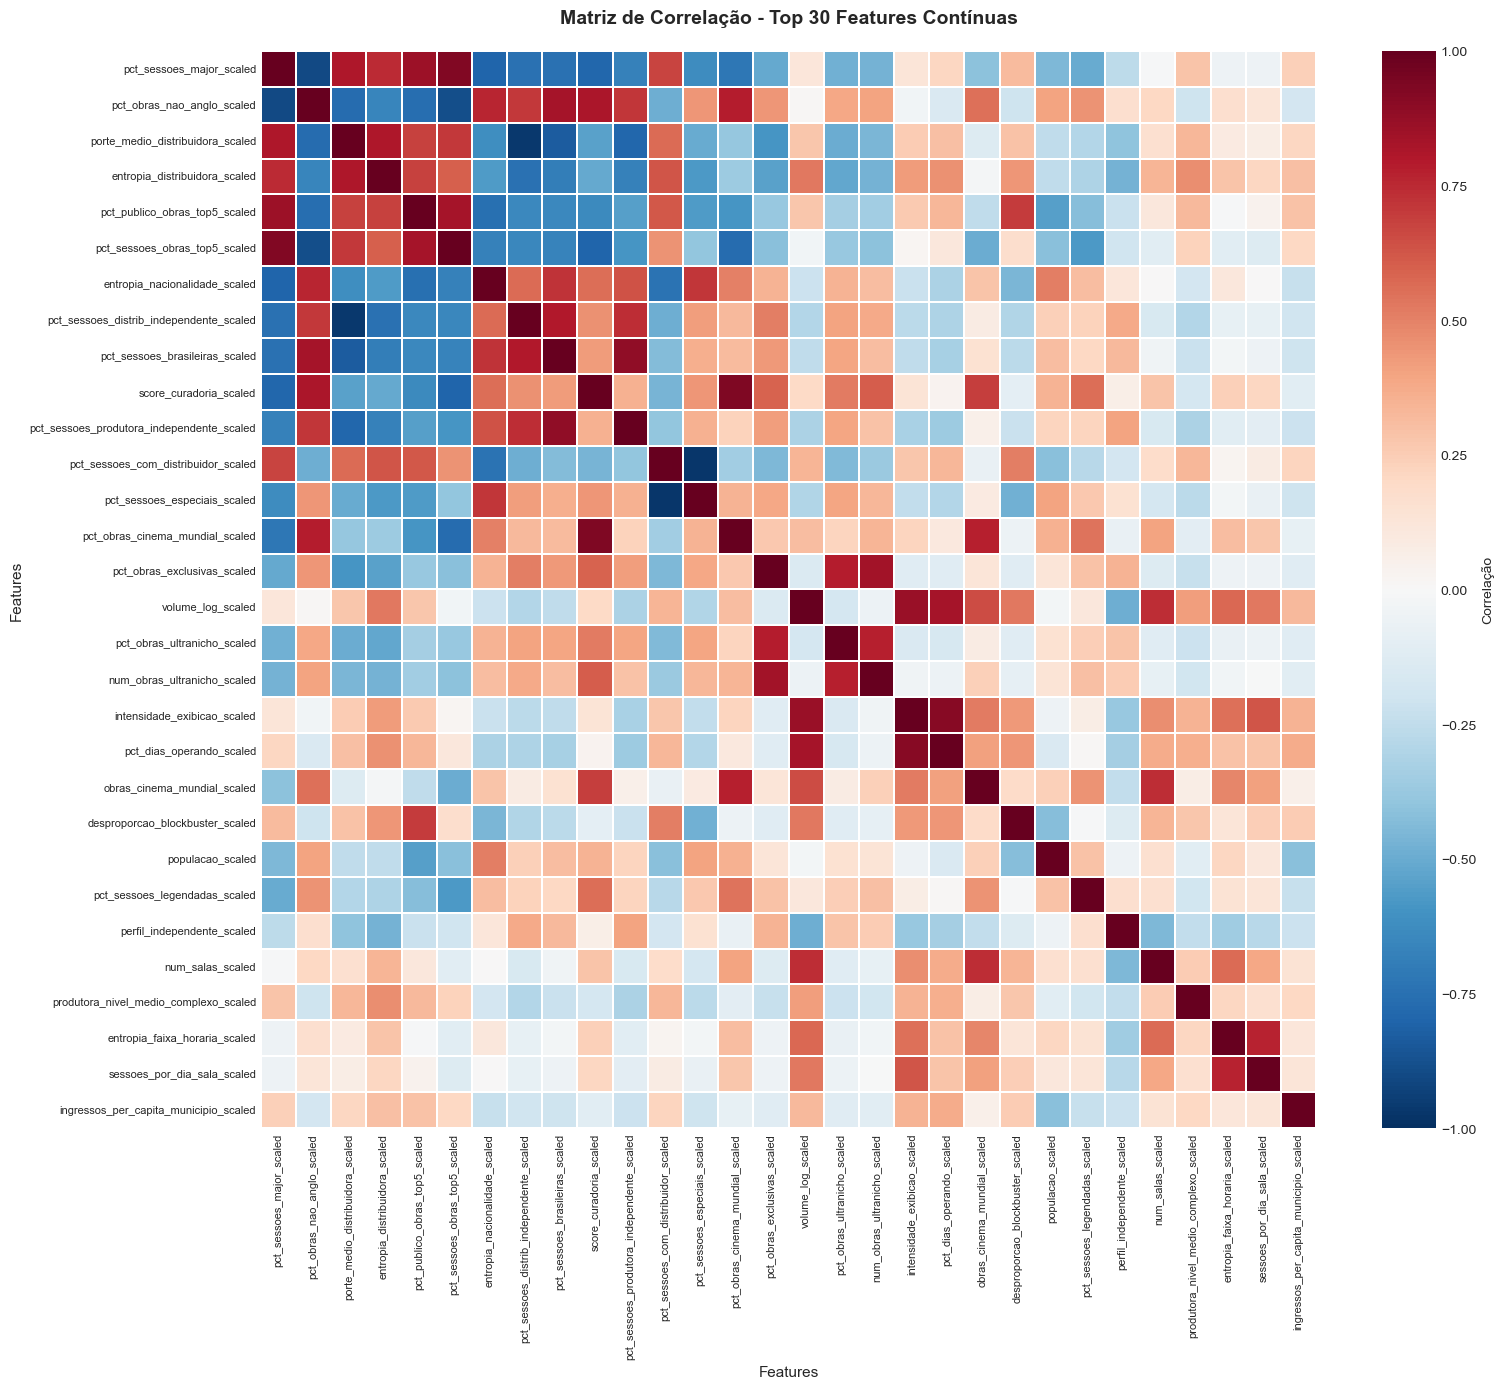


✅ Heatmap gerado com 30 features



In [16]:
##### print("=" * 80)
print("3.2 - MATRIZ DE CORRELAÇÃO (TOP 30 FEATURES CONTÍNUAS)")
print("=" * 80)

# Selecionar apenas features contínuas
features_continuas = [f for f in feature_names_clean if f.endswith('_scaled')]
X_continuas_df = X_df[features_continuas]

print(f"\nTotal de features contínuas: {len(features_continuas)}")

# Calcular correlação
corr_matrix = X_continuas_df.corr()

# Identificar top 30 features por variância das correlações
# (features que mais variam em correlação com outras = mais interessantes)
corr_variance = corr_matrix.var(axis=1).sort_values(ascending=False)
top_30_features = corr_variance.head(30).index.tolist()

print(f"\nTop 30 features selecionadas por variância de correlação:")
for i, feat in enumerate(top_30_features, 1):
    var_corr = corr_variance[feat]
    print(f"   {i:2d}. {feat:45s} (var_corr: {var_corr:.4f})")

# Matriz de correlação reduzida (top 30)
corr_top30 = corr_matrix.loc[top_30_features, top_30_features]

# Identificar correlações altas
print(f"\n{'─' * 80}")
print("CORRELAÇÕES ALTAS (|r| > 0.8):")
print(f"{'─' * 80}")

correlacoes_altas = []
for i in range(len(top_30_features)):
    for j in range(i+1, len(top_30_features)):
        feat_i = top_30_features[i]
        feat_j = top_30_features[j]
        corr_val = corr_top30.iloc[i, j]
        if abs(corr_val) > 0.8:
            correlacoes_altas.append((feat_i, feat_j, corr_val))

if len(correlacoes_altas) > 0:
    correlacoes_altas_sorted = sorted(correlacoes_altas, key=lambda x: abs(x[2]), reverse=True)
    for feat_i, feat_j, corr_val in correlacoes_altas_sorted:
        sinal = "+" if corr_val > 0 else "-"
        print(f"   {sinal} {feat_i:40s} × {feat_j:40s}: {corr_val:+.3f}")
else:
    print("   ✅ Nenhuma correlação |r| > 0.8 encontrada (multicolinearidade baixa)")

# Visualização - Heatmap
fig, ax = plt.subplots(figsize=(16, 14))

sns.heatmap(
    corr_top30,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlação'},
    linewidths=0.1,
    linecolor='white',
    ax=ax
)

plt.title('Matriz de Correlação - Top 30 Features Contínuas', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n✅ Heatmap gerado com {len(top_30_features)} features")

print("\n" + "=" * 80)

## 3.2 PCA Exploratória

3.3 - PCA EXPLORATÓRIA

PCA aplicado ao espaço refinado:
   • Shape da matriz: (894, 49)
   • Componentes calculados: 49

────────────────────────────────────────────────────────────────────────────────
VARIÂNCIA EXPLICADA (primeiros 20 componentes):
────────────────────────────────────────────────────────────────────────────────
   PC 1: 32.20%  (acumulado: 32.20%)
   PC 2: 16.75%  (acumulado: 48.95%)
   PC 3:  6.54%  (acumulado: 55.49%)
   PC 4:  5.25%  (acumulado: 60.74%)
   PC 5:  4.67%  (acumulado: 65.41%)
   PC 6:  3.67%  (acumulado: 69.08%)
   PC 7:  3.16%  (acumulado: 72.23%)
   PC 8:  2.83%  (acumulado: 75.07%)
   PC 9:  2.73%  (acumulado: 77.79%)
   PC10:  2.54%  (acumulado: 80.34%)

════════════════════════════════════════════════════════════════════════════════
   PC1 + PC2: 48.95% da variância
════════════════════════════════════════════════════════════════════════════════

   Exploratório (NB 4): PC1+PC2 = 45.77%
   Refinado (NB 4.1):   PC1+PC2 = 48.95%
   → Espaço refina

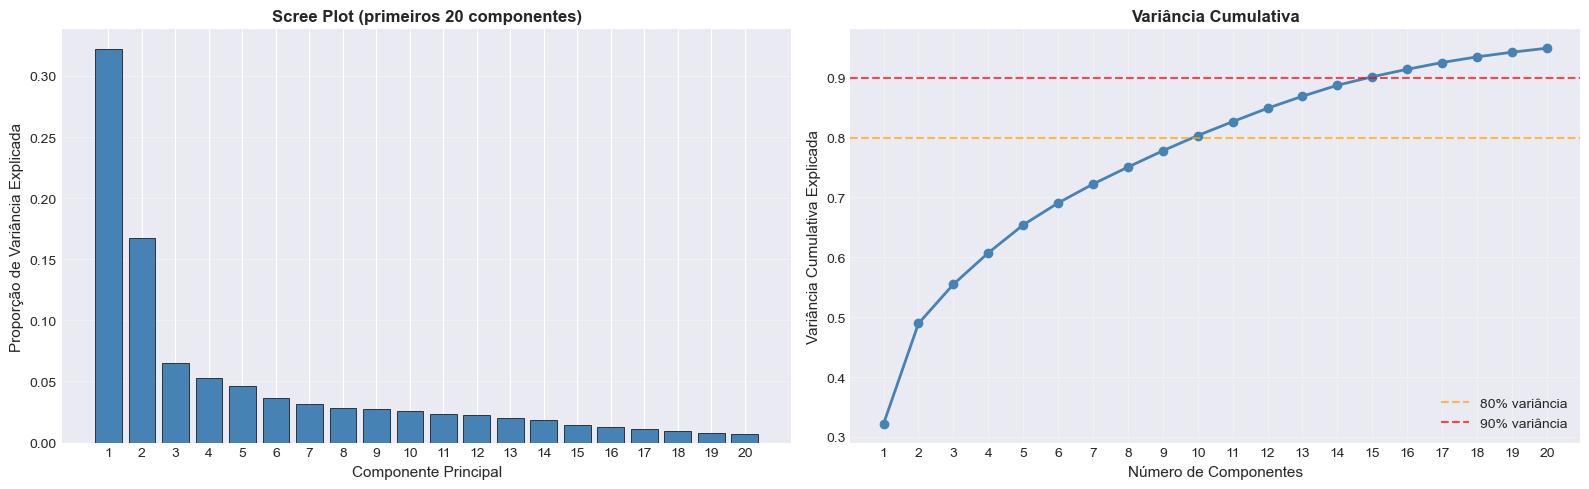


✅ Scree plot e variância cumulativa gerados



In [17]:
print("=" * 80)
print("3.3 - PCA EXPLORATÓRIA")
print("=" * 80)

# Aplicar PCA com todos os componentes
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_final)

n_components = min(20, len(pca_full.explained_variance_ratio_))

print(f"\nPCA aplicado ao espaço refinado:")
print(f"   • Shape da matriz: {X_final.shape}")
print(f"   • Componentes calculados: {len(pca_full.explained_variance_ratio_)}")

# Variância explicada pelos primeiros componentes
print(f"\n{'─' * 80}")
print(f"VARIÂNCIA EXPLICADA (primeiros {n_components} componentes):")
print(f"{'─' * 80}")

for i in range(min(10, n_components)):
    var_exp = pca_full.explained_variance_ratio_[i]
    var_cum = pca_full.explained_variance_ratio_[:i+1].sum()
    print(f"   PC{i+1:2d}: {var_exp:6.2%}  (acumulado: {var_cum:6.2%})")

# PC1 + PC2
var_pc1_pc2 = pca_full.explained_variance_ratio_[:2].sum()
print(f"\n{'═' * 80}")
print(f"   PC1 + PC2: {var_pc1_pc2:.2%} da variância")
print(f"{'═' * 80}")

# Comparação com Notebook 4 (45.77%)
print(f"\n   Exploratório (NB 4): PC1+PC2 = 45.77%")
print(f"   Refinado (NB 4.1):   PC1+PC2 = {var_pc1_pc2:.2%}")
if var_pc1_pc2 > 0.4577:
    diff = var_pc1_pc2 - 0.4577
    print(f"   → Espaço refinado é {diff:.1%} MAIS compacto em 2D")
else:
    diff = 0.4577 - var_pc1_pc2
    print(f"   → Espaço refinado é {diff:.1%} MENOS compacto em 2D")

# Quantos componentes para 90%?
var_cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(var_cumsum >= 0.90) + 1

print(f"\n{'─' * 80}")
print(f"COMPONENTES NECESSÁRIOS:")
print(f"{'─' * 80}")
print(f"   Para 80% da variância: {np.argmax(var_cumsum >= 0.80) + 1} componentes")
print(f"   Para 90% da variância: {n_90} componentes")
print(f"   Para 95% da variância: {np.argmax(var_cumsum >= 0.95) + 1} componentes")

# Visualizações
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
ax1.bar(range(1, n_components+1), pca_full.explained_variance_ratio_[:n_components], 
        color='steelblue', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Componente Principal', fontsize=11)
ax1.set_ylabel('Proporção de Variância Explicada', fontsize=11)
ax1.set_title(f'Scree Plot (primeiros {n_components} componentes)', 
              fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')
ax1.set_xticks(range(1, n_components+1))

# Variância cumulativa
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_[:n_components])
ax2.plot(range(1, n_components+1), cumsum_var, marker='o', linewidth=2, 
         markersize=6, color='steelblue')
ax2.axhline(y=0.80, color='orange', linestyle='--', alpha=0.7, label='80% variância')
ax2.axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label='90% variância')
ax2.set_xlabel('Número de Componentes', fontsize=11)
ax2.set_ylabel('Variância Cumulativa Explicada', fontsize=11)
ax2.set_title('Variância Cumulativa', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)
ax2.set_xticks(range(1, n_components+1))

plt.tight_layout()
plt.show()

print(f"\n✅ Scree plot e variância cumulativa gerados")

print("\n" + "=" * 80)

## 3.4 Visualização PCA 2D (Sem Clusters)

3.4 - VISUALIZAÇÃO PCA 2D (SEM CLUSTERS)

PCA 2D aplicado:
   • PC1: 32.20% da variância
   • PC2: 16.75% da variância
   • Total (PC1+PC2): 48.95%


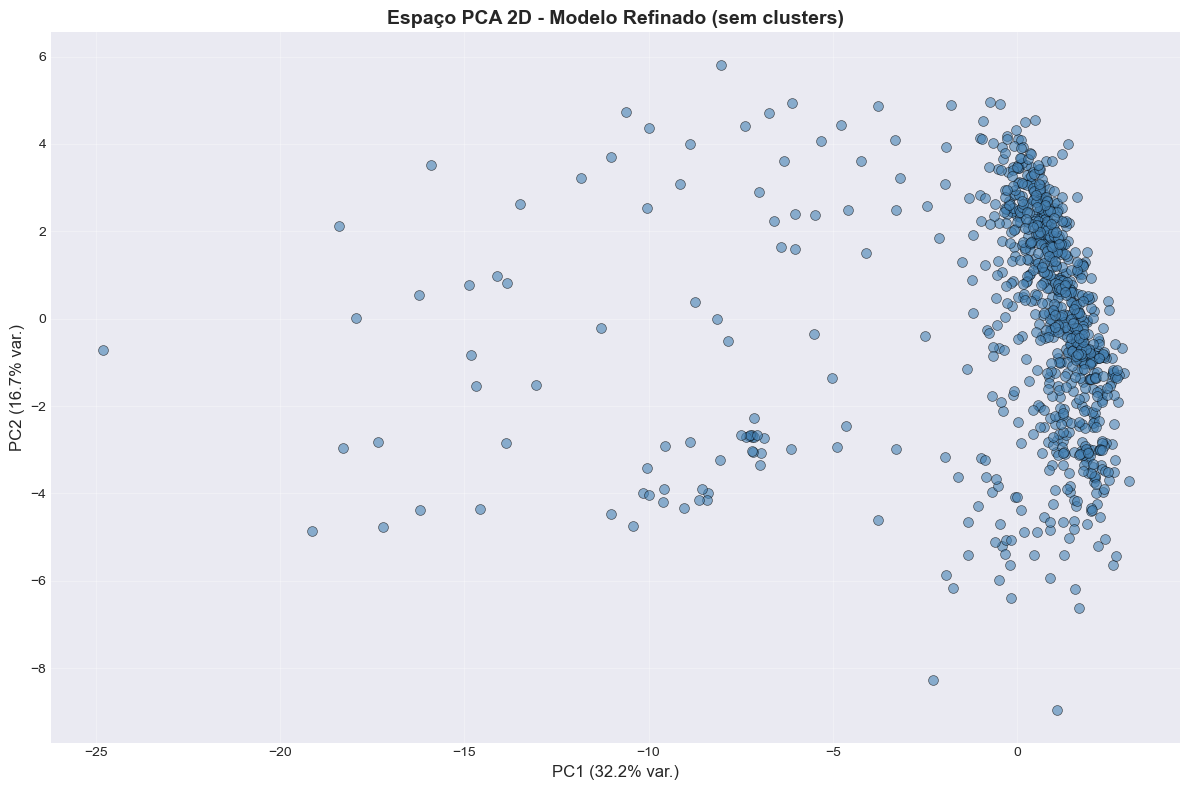


✅ Scatter plot PCA 2D gerado
   Total de complexos plotados: 894



In [18]:
print("=" * 80)
print("3.4 - VISUALIZAÇÃO PCA 2D (SEM CLUSTERS)")
print("=" * 80)

# Aplicar PCA 2D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_final)

var_pc1 = pca_2d.explained_variance_ratio_[0]
var_pc2 = pca_2d.explained_variance_ratio_[1]
var_total = var_pc1 + var_pc2

print(f"\nPCA 2D aplicado:")
print(f"   • PC1: {var_pc1:.2%} da variância")
print(f"   • PC2: {var_pc2:.2%} da variância")
print(f"   • Total (PC1+PC2): {var_total:.2%}")

# Visualização
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
           alpha=0.6, s=50, c='steelblue', edgecolors='k', linewidths=0.5)

ax.set_xlabel(f'PC1 ({var_pc1:.1%} var.)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_pc2:.1%} var.)', fontsize=12)
ax.set_title('Espaço PCA 2D - Modelo Refinado (sem clusters)', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Scatter plot PCA 2D gerado")
print(f"   Total de complexos plotados: {len(X_pca_2d)}")

print("\n" + "=" * 80)

## 3.5 Exploração Sistemática de k (4-8)

In [19]:
print("=" * 80)
print("3.5 - EXPLORAÇÃO SISTEMÁTICA DE k (4-8)")
print("=" * 80)

# Definir faixa de k a explorar
k_values = range(4, 9)  # k = 4, 5, 6, 7, 8

# Armazenar métricas
results = {
    'k': [],
    'inercia': [],
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': []
}

# Armazenar modelos (para análise posterior se necessário)
modelos_kmeans_refinado = {}

print(f"\nTestando k de {min(k_values)} a {max(k_values)}...\n")

for k in k_values:
    print(f"  Testando k={k}...", end=" ")
    
    # Treinar KMeans
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
        max_iter=500
    )
    labels = kmeans.fit_predict(X_final)
    
    # Calcular métricas
    inercia = kmeans.inertia_
    silhouette = silhouette_score(X_final, labels)
    davies_bouldin = davies_bouldin_score(X_final, labels)
    calinski = calinski_harabasz_score(X_final, labels)
    
    # Armazenar
    results['k'].append(k)
    results['inercia'].append(inercia)
    results['silhouette'].append(silhouette)
    results['davies_bouldin'].append(davies_bouldin)
    results['calinski_harabasz'].append(calinski)
    
    modelos_kmeans_refinado[k] = kmeans
    
    print(f"✓ (Silhouette: {silhouette:.4f})")

# Criar DataFrame com resultados
df_metricas_refinado = pd.DataFrame(results)

print("\n" + "=" * 80)
print("MÉTRICAS DO MODELO REFINADO:")
print("=" * 80)
display(df_metricas_refinado)

print("\n✅ Exploração concluída - 5 modelos treinados")
print("=" * 80)

3.5 - EXPLORAÇÃO SISTEMÁTICA DE k (4-8)

Testando k de 4 a 8...

  Testando k=4... ✓ (Silhouette: 0.2069)
  Testando k=5... ✓ (Silhouette: 0.1558)
  Testando k=6... ✓ (Silhouette: 0.1702)
  Testando k=7... ✓ (Silhouette: 0.1604)
  Testando k=8... ✓ (Silhouette: 0.1656)

MÉTRICAS DO MODELO REFINADO:


,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,4,19051.9913,0.2069,1.7236,213.5294
1,5,17853.8537,0.1558,1.8917,185.6170
2,6,16703.4406,0.1702,1.7391,170.7740
3,7,15814.3128,0.1604,1.6106,158.4552
4,8,15139.1605,0.1656,1.6404,147.3605



✅ Exploração concluída - 5 modelos treinados


## 3.6 Visualizações das Métricas

3.6 - VISUALIZAÇÕES DAS MÉTRICAS


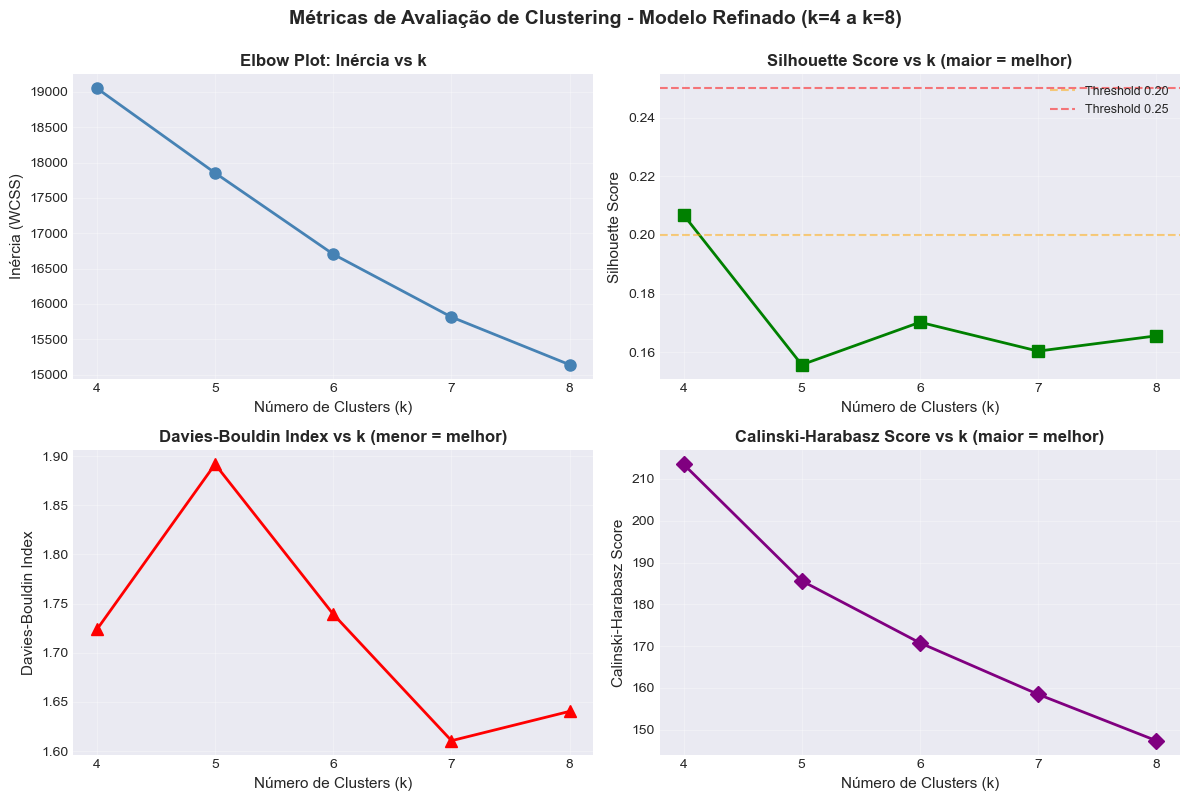


✅ Gráficos de métricas gerados


In [20]:
print("=" * 80)
print("3.6 - VISUALIZAÇÕES DAS MÉTRICAS")
print("=" * 80)

# Criar figura com 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Métricas de Avaliação de Clustering - Modelo Refinado (k=4 a k=8)', 
             fontsize=14, fontweight='bold', y=0.995)

# 1. Elbow Plot (Inércia)
ax1 = axes[0, 0]
ax1.plot(df_metricas_refinado['k'], df_metricas_refinado['inercia'], 
         marker='o', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('Número de Clusters (k)', fontsize=11)
ax1.set_ylabel('Inércia (WCSS)', fontsize=11)
ax1.set_title('Elbow Plot: Inércia vs k', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xticks(df_metricas_refinado['k'])

# 2. Silhouette Score
ax2 = axes[0, 1]
ax2.plot(df_metricas_refinado['k'], df_metricas_refinado['silhouette'], 
         marker='s', linewidth=2, markersize=8, color='green')
ax2.axhline(y=0.20, color='orange', linestyle='--', alpha=0.5, label='Threshold 0.20')
ax2.axhline(y=0.25, color='red', linestyle='--', alpha=0.5, label='Threshold 0.25')
ax2.set_xlabel('Número de Clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score vs k (maior = melhor)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xticks(df_metricas_refinado['k'])

# 3. Davies-Bouldin Index
ax3 = axes[1, 0]
ax3.plot(df_metricas_refinado['k'], df_metricas_refinado['davies_bouldin'], 
         marker='^', linewidth=2, markersize=8, color='red')
ax3.set_xlabel('Número de Clusters (k)', fontsize=11)
ax3.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax3.set_title('Davies-Bouldin Index vs k (menor = melhor)', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.set_xticks(df_metricas_refinado['k'])

# 4. Calinski-Harabasz Score
ax4 = axes[1, 1]
ax4.plot(df_metricas_refinado['k'], df_metricas_refinado['calinski_harabasz'], 
         marker='D', linewidth=2, markersize=8, color='purple')
ax4.set_xlabel('Número de Clusters (k)', fontsize=11)
ax4.set_ylabel('Calinski-Harabasz Score', fontsize=11)
ax4.set_title('Calinski-Harabasz Score vs k (maior = melhor)', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.set_xticks(df_metricas_refinado['k'])

plt.tight_layout()
plt.show()

print("\n✅ Gráficos de métricas gerados")
print("=" * 80)

## 3.7 Comparação Detalhada com Modelo Exploratório

In [21]:
print("=" * 80)
print("3.7 - COMPARAÇÃO DETALHADA: EXPLORATÓRIO vs REFINADO")
print("=" * 80)

# Dados do modelo exploratório (Notebook 4) - hardcoded conforme imagem fornecida
df_metricas_exploratorio = pd.DataFrame({
    'k': [4, 5, 6, 7, 8],
    'inercia': [20465.7541, 18772.3107, 17481.3045, 16253.6844, 15326.9371],
    'silhouette': [0.1916, 0.1991, 0.2024, 0.1488, 0.1630],
    'davies_bouldin': [1.3458, 1.1369, 1.2741, 1.4289, 1.4756],
    'calinski_harabasz': [194.3280, 178.9008, 166.7230, 160.5035, 153.4345]
})

print("\n" + "=" * 80)
print("TABELA 1: MODELO EXPLORATÓRIO (Notebook 4)")
print("=" * 80)
display(df_metricas_exploratorio)

print("\n" + "=" * 80)
print("TABELA 2: MODELO REFINADO (Notebook 4.1)")
print("=" * 80)
display(df_metricas_refinado)

# Calcular diferenças (Δ = Refinado - Exploratório)
df_comparacao = pd.DataFrame({
    'k': df_metricas_refinado['k'],
    'Silhouette_Exp': df_metricas_exploratorio['silhouette'],
    'Silhouette_Ref': df_metricas_refinado['silhouette'],
    'Δ_Silhouette': df_metricas_refinado['silhouette'] - df_metricas_exploratorio['silhouette'],
    'Δ%_Silhouette': ((df_metricas_refinado['silhouette'] - df_metricas_exploratorio['silhouette']) / 
                      df_metricas_exploratorio['silhouette'] * 100),
    'Davies_Exp': df_metricas_exploratorio['davies_bouldin'],
    'Davies_Ref': df_metricas_refinado['davies_bouldin'],
    'Δ_Davies': df_metricas_refinado['davies_bouldin'] - df_metricas_exploratorio['davies_bouldin'],
    'Calinski_Exp': df_metricas_exploratorio['calinski_harabasz'],
    'Calinski_Ref': df_metricas_refinado['calinski_harabasz'],
    'Δ_Calinski': df_metricas_refinado['calinski_harabasz'] - df_metricas_exploratorio['calinski_harabasz']
})

print("\n" + "=" * 80)
print("TABELA 3: COMPARAÇÃO DETALHADA (Δ = Refinado - Exploratório)")
print("=" * 80)
display(df_comparacao)

# Análise textual
print("\n" + "=" * 80)
print("ANÁLISE COMPARATIVA POR MÉTRICA:")
print("=" * 80)

print("\n📊 SILHOUETTE SCORE (maior = melhor):")
print("─" * 80)
for idx, row in df_comparacao.iterrows():
    k = int(row['k'])
    delta = row['Δ_Silhouette']
    delta_pct = row['Δ%_Silhouette']
    
    if delta > 0:
        status = "✅ MELHORA"
        emoji = "📈"
    elif delta < -0.01:
        status = "❌ PIORA"
        emoji = "📉"
    else:
        status = "≈ IGUAL"
        emoji = "➡️"
    
    print(f"   k={k}: {row['Silhouette_Exp']:.4f} → {row['Silhouette_Ref']:.4f} "
          f"({delta:+.4f}, {delta_pct:+.1f}%)  {emoji} {status}")

print("\n📊 DAVIES-BOULDIN INDEX (menor = melhor):")
print("─" * 80)
for idx, row in df_comparacao.iterrows():
    k = int(row['k'])
    delta = row['Δ_Davies']
    
    if delta < 0:
        status = "✅ MELHORA"
        emoji = "📈"
    elif delta > 0.1:
        status = "❌ PIORA"
        emoji = "📉"
    else:
        status = "≈ IGUAL"
        emoji = "➡️"
    
    print(f"   k={k}: {row['Davies_Exp']:.4f} → {row['Davies_Ref']:.4f} "
          f"({delta:+.4f})  {emoji} {status}")

print("\n📊 CALINSKI-HARABASZ SCORE (maior = melhor):")
print("─" * 80)
for idx, row in df_comparacao.iterrows():
    k = int(row['k'])
    delta = row['Δ_Calinski']
    
    if delta > 0:
        status = "✅ MELHORA"
        emoji = "📈"
    elif delta < -10:
        status = "❌ PIORA"
        emoji = "📉"
    else:
        status = "≈ IGUAL"
        emoji = "➡️"
    
    print(f"   k={k}: {row['Calinski_Exp']:.2f} → {row['Calinski_Ref']:.2f} "
          f"({delta:+.2f})  {emoji} {status}")

# Identificar melhor k em cada modelo
print("\n" + "=" * 80)
print("MELHOR k POR MÉTRICA:")
print("=" * 80)

best_sil_exp_idx = df_metricas_exploratorio['silhouette'].idxmax()
best_sil_ref_idx = df_metricas_refinado['silhouette'].idxmax()
best_dav_exp_idx = df_metricas_exploratorio['davies_bouldin'].idxmin()
best_dav_ref_idx = df_metricas_refinado['davies_bouldin'].idxmin()
best_cal_exp_idx = df_metricas_exploratorio['calinski_harabasz'].idxmax()
best_cal_ref_idx = df_metricas_refinado['calinski_harabasz'].idxmax()

k_best_sil_exp = int(df_metricas_exploratorio.loc[best_sil_exp_idx, 'k'])
k_best_sil_ref = int(df_metricas_refinado.loc[best_sil_ref_idx, 'k'])
k_best_dav_exp = int(df_metricas_exploratorio.loc[best_dav_exp_idx, 'k'])
k_best_dav_ref = int(df_metricas_refinado.loc[best_dav_ref_idx, 'k'])
k_best_cal_exp = int(df_metricas_exploratorio.loc[best_cal_exp_idx, 'k'])
k_best_cal_ref = int(df_metricas_refinado.loc[best_cal_ref_idx, 'k'])

print(f"\n   Silhouette (maior):      Exploratório k={k_best_sil_exp}  |  Refinado k={k_best_sil_ref}")
print(f"   Davies-Bouldin (menor):  Exploratório k={k_best_dav_exp}  |  Refinado k={k_best_dav_ref}")
print(f"   Calinski (maior):        Exploratório k={k_best_cal_exp}  |  Refinado k={k_best_cal_ref}")

print("\n" + "=" * 80)

3.7 - COMPARAÇÃO DETALHADA: EXPLORATÓRIO vs REFINADO

TABELA 1: MODELO EXPLORATÓRIO (Notebook 4)


,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,4,20465.7541,0.1916,1.3458,194.3280
1,5,18772.3107,0.1991,1.1369,178.9008
2,6,17481.3045,0.2024,1.2741,166.7230
3,7,16253.6844,0.1488,1.4289,160.5035
4,8,15326.9371,0.1630,1.4756,153.4345



TABELA 2: MODELO REFINADO (Notebook 4.1)


,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,4,19051.9913,0.2069,1.7236,213.5294
1,5,17853.8537,0.1558,1.8917,185.6170
2,6,16703.4406,0.1702,1.7391,170.7740
3,7,15814.3128,0.1604,1.6106,158.4552
4,8,15139.1605,0.1656,1.6404,147.3605



TABELA 3: COMPARAÇÃO DETALHADA (Δ = Refinado - Exploratório)


,k,Silhouette_Exp,Silhouette_Ref,Δ_Silhouette,Δ%_Silhouette,Davies_Exp,Davies_Ref,Δ_Davies,Calinski_Exp,Calinski_Ref,Δ_Calinski
0,4,0.1916,0.2069,0.0153,7.9662,1.3458,1.7236,0.3778,194.3280,213.5294,19.2014
1,5,0.1991,0.1558,-0.0433,-21.7728,1.1369,1.8917,0.7548,178.9008,185.6170,6.7162
2,6,0.2024,0.1702,-0.0322,-15.8911,1.2741,1.7391,0.4650,166.7230,170.7740,4.0510
3,7,0.1488,0.1604,0.0116,7.7938,1.4289,1.6106,0.1817,160.5035,158.4552,-2.0483
4,8,0.1630,0.1656,0.0026,1.5985,1.4756,1.6404,0.1648,153.4345,147.3605,-6.0740



ANÁLISE COMPARATIVA POR MÉTRICA:

📊 SILHOUETTE SCORE (maior = melhor):
────────────────────────────────────────────────────────────────────────────────
   k=4: 0.1916 → 0.2069 (+0.0153, +8.0%)  📈 ✅ MELHORA
   k=5: 0.1991 → 0.1558 (-0.0433, -21.8%)  📉 ❌ PIORA
   k=6: 0.2024 → 0.1702 (-0.0322, -15.9%)  📉 ❌ PIORA
   k=7: 0.1488 → 0.1604 (+0.0116, +7.8%)  📈 ✅ MELHORA
   k=8: 0.1630 → 0.1656 (+0.0026, +1.6%)  📈 ✅ MELHORA

📊 DAVIES-BOULDIN INDEX (menor = melhor):
────────────────────────────────────────────────────────────────────────────────
   k=4: 1.3458 → 1.7236 (+0.3778)  📉 ❌ PIORA
   k=5: 1.1369 → 1.8917 (+0.7548)  📉 ❌ PIORA
   k=6: 1.2741 → 1.7391 (+0.4650)  📉 ❌ PIORA
   k=7: 1.4289 → 1.6106 (+0.1817)  📉 ❌ PIORA
   k=8: 1.4756 → 1.6404 (+0.1648)  📉 ❌ PIORA

📊 CALINSKI-HARABASZ SCORE (maior = melhor):
────────────────────────────────────────────────────────────────────────────────
   k=4: 194.33 → 213.53 (+19.20)  📈 ✅ MELHORA
   k=5: 178.90 → 185.62 (+6.72)  📈 ✅ MELHORA
   k=6: 166.72

## 3.8 Análise Detalhada de Candidatos + Decisão

In [22]:
print("=" * 80)
print("3.8 - ANÁLISE DETALHADA DOS CANDIDATOS E DECISÃO DE k_final")
print("=" * 80)

# Melhor k por métrica
best_sil = int(df_metricas_refinado.loc[df_metricas_refinado['silhouette'].idxmax(), 'k'])
best_dav = int(df_metricas_refinado.loc[df_metricas_refinado['davies_bouldin'].idxmin(), 'k'])
best_cal = int(df_metricas_refinado.loc[df_metricas_refinado['calinski_harabasz'].idxmax(), 'k'])

print(f"\n{'═' * 80}")
print("MELHOR k POR MÉTRICA:")
print(f"{'═' * 80}")
print(f"   Silhouette:     k={best_sil}")
print(f"   Davies-Bouldin: k={best_dav}")
print(f"   Calinski:       k={best_cal}")

# Placar
vitorias = {}
for k in df_metricas_refinado['k'].values:
    vitorias[int(k)] = 0
vitorias[best_sil] += 1
vitorias[best_dav] += 1
vitorias[best_cal] += 1

print(f"\n{'─' * 80}")
print("PLACAR:")
print(f"{'─' * 80}")
for k, wins in sorted(vitorias.items(), key=lambda x: x[1], reverse=True):
    emoji = "🏆" if wins == 3 else "🥇" if wins == 2 else "🥉" if wins == 1 else ""
    print(f"   k={k}: {wins} vitória(s) {emoji}")

# Distribuição detalhada
print(f"\n{'═' * 80}")
print("DISTRIBUIÇÃO DE COMPLEXOS POR CLUSTER:")
print(f"{'═' * 80}")

for k in df_metricas_refinado['k'].values:
    labels = modelos_kmeans_refinado[int(k)].labels_
    counts = pd.Series(labels).value_counts().sort_index()
    pcts = (counts / len(labels) * 100).round(1)
    
    print(f"\n{'─' * 80}")
    print(f"k = {int(k)} clusters:")
    print(f"{'─' * 80}")
    
    for cluster_id in range(int(k)):
        n = counts.get(cluster_id, 0)
        p = pcts.get(cluster_id, 0.0)
        
        if n == 1:
            emoji = "🔴"
            obs = "SINGLETON"
        elif n < 20:
            emoji = "🟡"
            obs = "Pequeno"
        elif p > 40:
            emoji = "🔵"
            obs = "Grande"
        else:
            emoji = "🟢"
            obs = ""
        
        print(f"   Cluster {cluster_id}: {n:3d} ({p:5.1f}%)  {emoji} {obs}")

# Recomendação
k_rec = max(vitorias.items(), key=lambda x: x[1])[0]
labels_rec = modelos_kmeans_refinado[k_rec].labels_
tem_sing = (pd.Series(labels_rec).value_counts() == 1).any()

print(f"\n{'═' * 80}")
print(f"RECOMENDAÇÃO: k={k_rec}")
if tem_sing:
    print(f"   ⚠️  Contém singleton - considere remover e re-treinar")
print(f"{'═' * 80}")

k_final = k_rec

print(f"\n✅ k_final = {k_final}")
print("=" * 80)

3.8 - ANÁLISE DETALHADA DOS CANDIDATOS E DECISÃO DE k_final

════════════════════════════════════════════════════════════════════════════════
MELHOR k POR MÉTRICA:
════════════════════════════════════════════════════════════════════════════════
   Silhouette:     k=4
   Davies-Bouldin: k=7
   Calinski:       k=4

────────────────────────────────────────────────────────────────────────────────
PLACAR:
────────────────────────────────────────────────────────────────────────────────
   k=4: 2 vitória(s) 🥇
   k=7: 1 vitória(s) 🥉
   k=5: 0 vitória(s) 
   k=6: 0 vitória(s) 
   k=8: 0 vitória(s) 

════════════════════════════════════════════════════════════════════════════════
DISTRIBUIÇÃO DE COMPLEXOS POR CLUSTER:
════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────────────
k = 4 clusters:
────────────────────────────────────────────────────────────────────────────────
   Cluster 0:  53 (  5

In [23]:
print("=" * 80)
print("3.8.1 - IDENTIFICAÇÃO DO COMPLEXO ISOLADO (SINGLETON)")
print("=" * 80)

singletons_info = []

for k in range(4, 9):
    labels = modelos_kmeans_refinado[k].labels_
    cluster_counts = pd.Series(labels).value_counts()
    singleton_clusters = cluster_counts[cluster_counts == 1].index.tolist()
    
    if singleton_clusters:
        for cluster_id in singleton_clusters:
            idx = np.where(labels == cluster_id)[0][0]
            registro = df_features_clean.iloc[idx]['REGISTRO_COMPLEXO']
            singletons_info.append({'k': k, 'cluster': cluster_id, 'registro': registro})
            print(f"   k={k}, Cluster {cluster_id}: registro={registro}")

if not singletons_info:
    print("   ✅ Nenhum singleton")
else:
    unique = list(set([s['registro'] for s in singletons_info]))
    print(f"\n{'─' * 80}")
    
    if len(unique) == 1:
        print(f"⚠️  SEMPRE O MESMO: {unique[0]} ({len(singletons_info)} vezes)")
        registro_problema = unique[0]
    else:
        print(f"⚠️  MÚLTIPLOS: {len(unique)} diferentes")
        registro_problema = unique[0]
    
    print(f"\n{'═' * 80}")
    print("INFORMAÇÕES CADASTRAIS:")
    print(f"{'═' * 80}")
    
    cadastro_filtrado = df_cadastro_complexos[df_cadastro_complexos['REGISTRO_COMPLEXO'] == registro_problema]
    
    if len(cadastro_filtrado) == 0:
        print(f"\n❌ REGISTRO {registro_problema} NÃO ENCONTRADO NO CADASTRO ANCINE")
    else:
        info = cadastro_filtrado.iloc[0]
        
        print(f"\n📍 {info['NOME_COMPLEXO']}")
        print(f"   {info['MUNICIPIO_COMPLEXO']}/{info['UF_COMPLEXO']}")
        print(f"   Operação: {info['OPERACAO_USUAL']}")
        print(f"   Situação: {info['SITUACAO_COMPLEXO']} ({info['DATA_SITUACAO_COMPLEXO']})")
        print(f"   Exibidor: {info['NOME_EXIBIDOR']}")
        print(f"   Grupo: {info['NOME_GRUPO_EXIBIDOR']}")
    
    print(f"\n{'─' * 80}")
    print("TOP 15 FEATURES EXTREMAS:")
    print(f"{'─' * 80}")
    
    idx_array = df_features_clean[df_features_clean['REGISTRO_COMPLEXO'] == registro_problema].index[0]
    features = X_final[idx_array]
    sorted_feats = sorted(zip(feature_names_clean, features), key=lambda x: abs(x[1]), reverse=True)
    
    for i, (feat, val) in enumerate(sorted_feats[:15], 1):
        emoji = "🔴" if val > 3 else "🔵" if val < -3 else "🟡" if abs(val) > 2 else "🟢"
        print(f"   {i:2d}. {feat:45s}: {val:+7.2f}  {emoji}")

print("\n" + "=" * 80)

3.8.1 - IDENTIFICAÇÃO DO COMPLEXO ISOLADO (SINGLETON)
   ✅ Nenhum singleton



# 4 Seleção avançada de features

## 4.1 Matriz de Correlação

In [24]:
# Matriz de correlação
corr_matrix = np.corrcoef(X_final.T)

# Encontrar pares altamente correlacionados
threshold = 0.85
pares_redundantes = []

for i in range(len(feature_names_clean)):
    for j in range(i+1, len(feature_names_clean)):
        corr_val = abs(corr_matrix[i, j])
        if corr_val > threshold:
            pares_redundantes.append({
                'feat1': feature_names_clean[i],
                'feat2': feature_names_clean[j],
                'corr': corr_matrix[i, j],
                'corr_abs': corr_val
            })

df_corr = pd.DataFrame(pares_redundantes).sort_values('corr_abs', ascending=False)

print(f"Pares com |correlação| > {threshold}:")
display(df_corr)

print("\n🎯 AÇÃO: De cada par, remova a feature MENOS interpretável")

Pares com |correlação| > 0.85:


,feat1,feat2,corr,corr_abs
6,pct_sessoes_com_distribuidor_scaled,pct_sessoes_especiais_scaled,-0.9728,0.9728
5,pct_sessoes_distrib_independente_scaled,porte_medio_distribuidora_scaled,-0.9649,0.9649
10,perfil_independente_scaled,exibidor_independente,0.9580,0.9580
9,pct_obras_cinema_mundial_scaled,score_curadoria_scaled,0.9336,0.9336
3,pct_sessoes_major_scaled,pct_sessoes_obras_top5_scaled,0.9252,0.9252
0,pct_dias_operando_scaled,intensidade_exibicao_scaled,0.9092,0.9092
4,pct_sessoes_major_scaled,pct_obras_nao_anglo_scaled,-0.9062,0.9062
7,pct_sessoes_produtora_independente_scaled,pct_sessoes_brasileiras_scaled,0.8876,0.8876
8,pct_sessoes_obras_top5_scaled,pct_obras_nao_anglo_scaled,-0.8853,0.8853
1,volume_log_scaled,intensidade_exibicao_scaled,0.8645,0.8645



🎯 AÇÃO: De cada par, remova a feature MENOS interpretável


In [25]:
# Baseline (todas features)
kmeans_base = KMeans(n_clusters=6, random_state=42, n_init=20)
labels_base = kmeans_base.fit_predict(X_final)
sil_base = silhouette_score(X_final, labels_base)

print(f"Silhouette baseline (50 features): {sil_base:.4f}\n")

# Testar remoção de cada feature
importancias = []

for i, feat in enumerate(feature_names_clean):
    # Remover feature i
    X_temp = np.delete(X_final, i, axis=1)
    
    # Re-clusterizar
    kmeans_temp = KMeans(n_clusters=6, random_state=42, n_init=20)
    labels_temp = kmeans_temp.fit_predict(X_temp)
    sil_temp = silhouette_score(X_temp, labels_temp)
    
    delta = sil_temp - sil_base
    
    importancias.append({
        'feature': feat,
        'silhouette_sem': sil_temp,
        'delta': delta,
        'melhora': 'SIM' if delta > 0 else 'NÃO'
    })
    
    if (i+1) % 10 == 0:
        print(f"Processado {i+1}/{len(feature_names_clean)}...")

df_imp = pd.DataFrame(importancias).sort_values('delta', ascending=False)

print("\n" + "="*80)
print("FEATURES QUE MELHORAM O MODELO SE REMOVIDAS (delta > 0):")
print("="*80)
display(df_imp[df_imp['delta'] > 0])

print("\n" + "="*80)
print("FEATURES QUE MAIS PREJUDICAM SE REMOVIDAS (delta < -0.01):")
print("="*80)
display(df_imp[df_imp['delta'] < -0.01].head(10))

Silhouette baseline (50 features): 0.1702

Processado 10/49...
Processado 20/49...
Processado 30/49...
Processado 40/49...

FEATURES QUE MELHORAM O MODELO SE REMOVIDAS (delta > 0):


,feature,silhouette_sem,delta,melhora
19,pib_per_capita_scaled,0.2064,0.0362,SIM
15,pct_sessoes_legendadas_scaled,0.1752,0.0049,SIM
13,pct_modalidade_c_scaled,0.1731,0.0029,SIM
41,faixa_renda_cat_Media_Baixa,0.1729,0.0027,SIM
40,faixa_renda_cat_Media_Alta,0.1727,0.0025,SIM
37,porte_municipio_cat_Muito_Grande,0.1726,0.0023,SIM
43,e_capital,0.1725,0.0023,SIM
36,porte_municipio_cat_Metropole,0.1725,0.0022,SIM
27,pct_obras_exclusivas_scaled,0.1721,0.0019,SIM
5,pct_sessoes_distrib_independente_scaled,0.1714,0.0012,SIM



FEATURES QUE MAIS PREJUDICAM SE REMOVIDAS (delta < -0.01):


,feature,silhouette_sem,delta,melhora
32,score_curadoria_scaled,0.1596,-0.0107,NÃO
39,faixa_renda_cat_Baixa,0.1594,-0.0108,NÃO
8,pct_sessoes_produtora_independente_scaled,0.1593,-0.0109,NÃO
23,entropia_faixa_horaria_scaled,0.1591,-0.0112,NÃO
46,exibidor_independente,0.1588,-0.0115,NÃO
11,pct_sessoes_especiais_scaled,0.1585,-0.0117,NÃO
38,porte_municipio_cat_Pequeno,0.1582,-0.0121,NÃO
28,num_obras_ultranicho_scaled,0.1581,-0.0122,NÃO
7,pct_sessoes_com_distribuidor_scaled,0.1578,-0.0125,NÃO
17,pct_sessoes_obras_top5_scaled,0.1573,-0.0129,NÃO


In [26]:

# VIF para features contínuas
features_cont_idx = [i for i, f in enumerate(feature_names_clean) if f.endswith('_scaled')]
X_cont = X_final[:, features_cont_idx]
features_cont_nomes = [feature_names_clean[i] for i in features_cont_idx]

vif_data = []
for i in range(X_cont.shape[1]):
    vif = variance_inflation_factor(X_cont, i)
    vif_data.append({'feature': features_cont_nomes[i], 'VIF': vif})

df_vif = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print("VIF (Variance Inflation Factor):")
print("  VIF > 10: Multicolinearidade ALTA ⚠️")
print("  VIF > 5:  Multicolinearidade MODERADA")
display(df_vif)

print("\n🎯 AÇÃO: Remover features com VIF > 10")

VIF (Variance Inflation Factor):
  VIF > 10: Multicolinearidade ALTA ⚠️
  VIF > 5:  Multicolinearidade MODERADA


,feature,VIF
16,pct_publico_obras_top5_scaled,inf
17,pct_sessoes_obras_top5_scaled,inf
10,pct_sessoes_brasileiras_scaled,inf
27,pct_obras_exclusivas_scaled,inf
29,pct_obras_ultranicho_scaled,inf
30,pct_obras_nao_anglo_scaled,inf
31,desproporcao_blockbuster_scaled,inf
32,score_curadoria_scaled,inf
26,pct_obras_cinema_mundial_scaled,inf
33,intensidade_exibicao_scaled,48.8491



🎯 AÇÃO: Remover features com VIF > 10


## 4.2 Remoção de features avançada

## 4.2.1 Rodada 1

In [27]:
features_remover_fase1 = [
    # 1-2: DERIVADAS (combinações matemáticas de outras features)
    'desproporcao_blockbuster_scaled',      # = pct_publico_top5 / pct_sessoes_top5
    'intensidade_exibicao_scaled',          # = sessoes_por_dia_sala × pct_dias_operando
    
    # 3-4: VIF INFINITO + Redundância Comprovada
    'pct_obras_ultranicho_scaled',          # Redundante com num_obras_ultranicho
    'pct_sessoes_obras_top5_scaled',        # Redundante com pct_publico_obras_top5
    
    # 5-6: CORRELAÇÃO ALTA (> 0.95) + VIF Alto
    'pct_sessoes_com_distribuidor_scaled',  # Corr 0.97 com pct_sessoes_especiais
    'porte_medio_distribuidora_scaled',     # Corr 0.96 com pct_sessoes_distrib_independente
]

In [28]:
# Identificar índices
indices_remover = [i for i, f in enumerate(feature_names_clean) 
                   if f in features_remover_fase1]

# Criar novo X
X_fase1 = np.delete(X_final, indices_remover, axis=1)

# Nova lista de features
features_fase1 = [f for f in feature_names_clean 
                  if f not in features_remover_fase1]

print(f"Features removidas: {len(features_remover_fase1)}")
print(f"Features restantes: {len(features_fase1)}")

Features removidas: 6
Features restantes: 43


In [29]:
resultados_fase1 = []

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase1)
    
    resultados_fase1.append({
        'k': k,
        'silhouette': silhouette_score(X_fase1, labels),
        'davies_bouldin': davies_bouldin_score(X_fase1, labels),
        'calinski_harabasz': calinski_harabasz_score(X_fase1, labels),
        'inertia': kmeans.inertia_
    })

df_resultados_fase1 = pd.DataFrame(resultados_fase1)
print("\nRESULTADOS FASE 1:")
display(df_resultados_fase1)


RESULTADOS FASE 1:


,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,4,0.2055,1.7305,197.2800,16457.1039
1,5,0.1617,1.9239,171.5689,15463.5767
2,6,0.1497,1.6997,155.0209,14630.4641
3,7,0.1677,1.6008,144.1727,13872.1961
4,8,0.1471,1.5964,135.1085,13253.4815


In [30]:
# Apenas contínuas
features_cont_fase1 = [f for f in features_fase1 if f.endswith('_scaled')]
idx_cont = [i for i, f in enumerate(features_fase1) if f.endswith('_scaled')]
X_cont_fase1 = X_fase1[:, idx_cont]

vif_fase1 = []
for i in range(len(features_cont_fase1)):
    vif = variance_inflation_factor(X_cont_fase1, i)
    vif_fase1.append({'feature': features_cont_fase1[i], 'VIF': vif})

df_vif_fase1 = pd.DataFrame(vif_fase1).sort_values('VIF', ascending=False)

print("\nVIF APÓS FASE 1:")
print(f"Features com VIF > 30: {len(df_vif_fase1[df_vif_fase1['VIF'] > 30])}")
print(f"Features com VIF = inf: {len(df_vif_fase1[df_vif_fase1['VIF'] == np.inf])}")
display(df_vif_fase1.head(15))


VIF APÓS FASE 1:
Features com VIF > 30: 4
Features com VIF = inf: 3


,feature,VIF
8,pct_sessoes_brasileiras_scaled,inf
23,pct_obras_cinema_mundial_scaled,inf
26,pct_obras_nao_anglo_scaled,inf
27,score_curadoria_scaled,226.6834
24,pct_obras_exclusivas_scaled,25.8810
3,volume_log_scaled,22.7762
4,pct_sessoes_major_scaled,18.8623
0,num_salas_scaled,9.0860
1,pct_dias_operando_scaled,9.0440
22,obras_cinema_mundial_scaled,9.0175


In [31]:
corr_matrix_fase1 = np.corrcoef(X_fase1.T)

# Pares com |corr| > 0.85
pares_fase1 = []
for i in range(len(features_fase1)):
    for j in range(i+1, len(features_fase1)):
        corr_val = abs(corr_matrix_fase1[i, j])
        if corr_val > 0.85:
            pares_fase1.append({
                'feat1': features_fase1[i],
                'feat2': features_fase1[j],
                'corr_abs': corr_val
            })

df_corr_fase1 = pd.DataFrame(pares_fase1).sort_values('corr_abs', ascending=False)

print(f"\nPARES COM |CORRELAÇÃO| > 0.85:")
print(f"Total: {len(df_corr_fase1)}")
display(df_corr_fase1)



PARES COM |CORRELAÇÃO| > 0.85:
Total: 5


,feat1,feat2,corr_abs
4,perfil_independente_scaled,exibidor_independente,0.9580
3,pct_obras_cinema_mundial_scaled,score_curadoria_scaled,0.9336
1,pct_sessoes_major_scaled,pct_obras_nao_anglo_scaled,0.9062
2,pct_sessoes_produtora_independente_scaled,pct_sessoes_brasileiras_scaled,0.8876
0,pct_sessoes_major_scaled,pct_publico_obras_top5_scaled,0.8545


## 4.2.2 Rodada 2

In [32]:
# FASE 2: Remoção de baixa_atividade + features adicionais

print("=" * 80)
print("FASE 2: REMOÇÃO DE COMPLEXOS E FEATURES")
print("=" * 80)

# USAR df_features_clean (894 linhas, alinhado com X_fase1)
mask_baixa_atividade = df_features_clean['baixa_atividade'] == 1  
n_baixa_atividade = mask_baixa_atividade.sum()

print(f"\n📊 Complexos com baixa_atividade=1: {n_baixa_atividade} ({n_baixa_atividade/len(df_features_clean)*100:.1f}%)")

if n_baixa_atividade > 0:
    print("\nComplexos a remover:")
    display(df_features_clean[mask_baixa_atividade][['REGISTRO_COMPLEXO', 'municipio', 'UF']])

# Remover complexos
df_features_fase2 = df_features_clean[~mask_baixa_atividade].copy()
X_fase2_temp = X_fase1[~mask_baixa_atividade.values]

print(f"\n✅ Complexos restantes: {len(df_features_fase2)}")

# Features a remover
features_remover_fase2 = [
    'score_curadoria_scaled',
    'baixa_atividade'
]

print(f"\n📋 Features a remover:")
for feat in features_remover_fase2:
    existe = feat in features_fase1
    print(f"  {'✓' if existe else '✗'} {feat}")

indices_remover_fase2 = [i for i, f in enumerate(features_fase1) if f in features_remover_fase2]

X_fase2 = np.delete(X_fase2_temp, indices_remover_fase2, axis=1)
features_fase2 = [f for f in features_fase1 if f not in features_remover_fase2]

print(f"\n✅ Fase 2 concluída:")
print(f"  Complexos: {X_fase2.shape[0]}")
print(f"  Features: {X_fase2.shape[1]}")

print("\n" + "=" * 80)

FASE 2: REMOÇÃO DE COMPLEXOS E FEATURES

📊 Complexos com baixa_atividade=1: 19 (2.1%)

Complexos a remover:


,REGISTRO_COMPLEXO,municipio,UF
54,15266,CÁCERES,MT
136,19476,UMUARAMA,PR
555,41391,GUANAMBI,BA
607,43979,URUGUAIANA,RS
649,45293,SÃO PAULO,SP
742,52336,LUCAS DO RIO VERDE,MT
813,58670,MONTE CARMELO,MG
826,59894,SÃO PAULO,SP
827,59895,SÃO PAULO,SP
828,59897,SÃO PAULO,SP



✅ Complexos restantes: 875

📋 Features a remover:
  ✓ score_curadoria_scaled
  ✓ baixa_atividade

✅ Fase 2 concluída:
  Complexos: 875
  Features: 41



In [33]:
# Re-clusterização Fase 2

print("=" * 80)
print("CLUSTERIZAÇÃO FASE 2")
print("=" * 80)

resultados_fase2 = []

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase2)
    
    sil = silhouette_score(X_fase2, labels)
    db = davies_bouldin_score(X_fase2, labels)
    ch = calinski_harabasz_score(X_fase2, labels)
    
    resultados_fase2.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'inertia': kmeans.inertia_
    })
    
    print(f"k={k}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.1f}")

df_resultados_fase2 = pd.DataFrame(resultados_fase2)

print("\n" + "=" * 80)
print("COMPARAÇÃO FASE 1 vs FASE 2:")
print("=" * 80)

# Comparação Fase 1 vs Fase 2

print("\n" + "=" * 80)
print("COMPARAÇÃO FASE 1 vs FASE 2:")
print("=" * 80)

print(f"\n{'k':>3} | {'Sil_Fase1':>10} | {'Sil_Fase2':>10} | {'Delta':>8}")
print("-" * 40)

for i in range(len(df_resultados_fase1)):
    k = int(df_resultados_fase1.iloc[i]['k'])  # ← Converter aqui
    sil1 = df_resultados_fase1.iloc[i]['silhouette']
    sil2 = df_resultados_fase2.iloc[i]['silhouette']
    delta = sil2 - sil1
    simbolo = "↑" if delta > 0 else "↓"
    print(f"{k:3d} | {sil1:10.4f} | {sil2:10.4f} | {delta:+7.4f} {simbolo}")

print("\n" + "=" * 80)

CLUSTERIZAÇÃO FASE 2
k=4: Silhouette=0.1964, DB=1.7057, CH=183.5
k=5: Silhouette=0.1514, DB=1.9917, CH=159.3
k=6: Silhouette=0.1518, DB=1.7160, CH=146.0
k=7: Silhouette=0.1533, DB=1.6555, CH=136.4
k=8: Silhouette=0.1394, DB=1.6010, CH=128.5

COMPARAÇÃO FASE 1 vs FASE 2:

COMPARAÇÃO FASE 1 vs FASE 2:

  k |  Sil_Fase1 |  Sil_Fase2 |    Delta
----------------------------------------
  4 |     0.2055 |     0.1964 | -0.0090 ↓
  5 |     0.1617 |     0.1514 | -0.0103 ↓
  6 |     0.1497 |     0.1518 | +0.0022 ↑
  7 |     0.1677 |     0.1533 | -0.0144 ↓
  8 |     0.1471 |     0.1394 | -0.0077 ↓



In [34]:
# Diagnóstico VIF e Correlação - Fase 2

print("=" * 80)
print("DIAGNÓSTICO FASE 2")
print("=" * 80)

# VIF
features_cont_fase2 = [f for f in features_fase2 if f.endswith('_scaled')]
idx_cont = [i for i, f in enumerate(features_fase2) if f.endswith('_scaled')]
X_cont_fase2 = X_fase2[:, idx_cont]

vif_fase2 = []
for i in range(len(features_cont_fase2)):
    vif = variance_inflation_factor(X_cont_fase2, i)
    vif_fase2.append({'feature': features_cont_fase2[i], 'VIF': vif})

df_vif_fase2 = pd.DataFrame(vif_fase2).sort_values('VIF', ascending=False)

print(f"\nVIF APÓS FASE 2:")
print(f"Features com VIF > 30: {len(df_vif_fase2[df_vif_fase2['VIF'] > 30])}")
print(f"Features com VIF = inf: {len(df_vif_fase2[df_vif_fase2['VIF'] == np.inf])}")
display(df_vif_fase2.head(15))

# Correlação
corr_matrix_fase2 = np.corrcoef(X_fase2.T)

pares_fase2 = []
for i in range(len(features_fase2)):
    for j in range(i+1, len(features_fase2)):
        corr_val = abs(corr_matrix_fase2[i, j])
        if corr_val > 0.85:
            pares_fase2.append({
                'feat1': features_fase2[i],
                'feat2': features_fase2[j],
                'corr_abs': corr_val
            })

df_corr_fase2 = pd.DataFrame(pares_fase2).sort_values('corr_abs', ascending=False)

print(f"\nPARES COM |CORRELAÇÃO| > 0.85:")
print(f"Total: {len(df_corr_fase2)}")
display(df_corr_fase2)

print("\n" + "=" * 80)

DIAGNÓSTICO FASE 2

VIF APÓS FASE 2:
Features com VIF > 30: 3
Features com VIF = inf: 3


,feature,VIF
8,pct_sessoes_brasileiras_scaled,inf
26,pct_obras_nao_anglo_scaled,inf
23,pct_obras_cinema_mundial_scaled,inf
3,volume_log_scaled,26.7381
4,pct_sessoes_major_scaled,21.2276
6,pct_sessoes_produtora_independente_scaled,13.9375
0,num_salas_scaled,10.6927
1,pct_dias_operando_scaled,9.4840
22,obras_cinema_mundial_scaled,8.9668
18,entropia_nacionalidade_scaled,8.0033



PARES COM |CORRELAÇÃO| > 0.85:
Total: 4


,feat1,feat2,corr_abs
3,perfil_independente_scaled,exibidor_independente,0.9590
2,pct_sessoes_produtora_independente_scaled,pct_sessoes_brasileiras_scaled,0.9349
1,pct_sessoes_major_scaled,pct_obras_nao_anglo_scaled,0.9224
0,pct_sessoes_major_scaled,pct_publico_obras_top5_scaled,0.8507


ANÁLISE DE VARIÂNCIA - PCA

💡 OBJETIVO:
   Identificar features que contribuem pouco para a variância total
   → Candidatas à remoção se explicam apenas os últimos 5% de variância

📊 RESUMO:
   Total de features: 41
   Variância explicada pelo PC1: 0.2890 (28.90%)
   Variância acumulada em 15 PCs: 0.9050 (90.50%)
   Variância acumulada em 20 PCs: 0.9540 (95.40%)


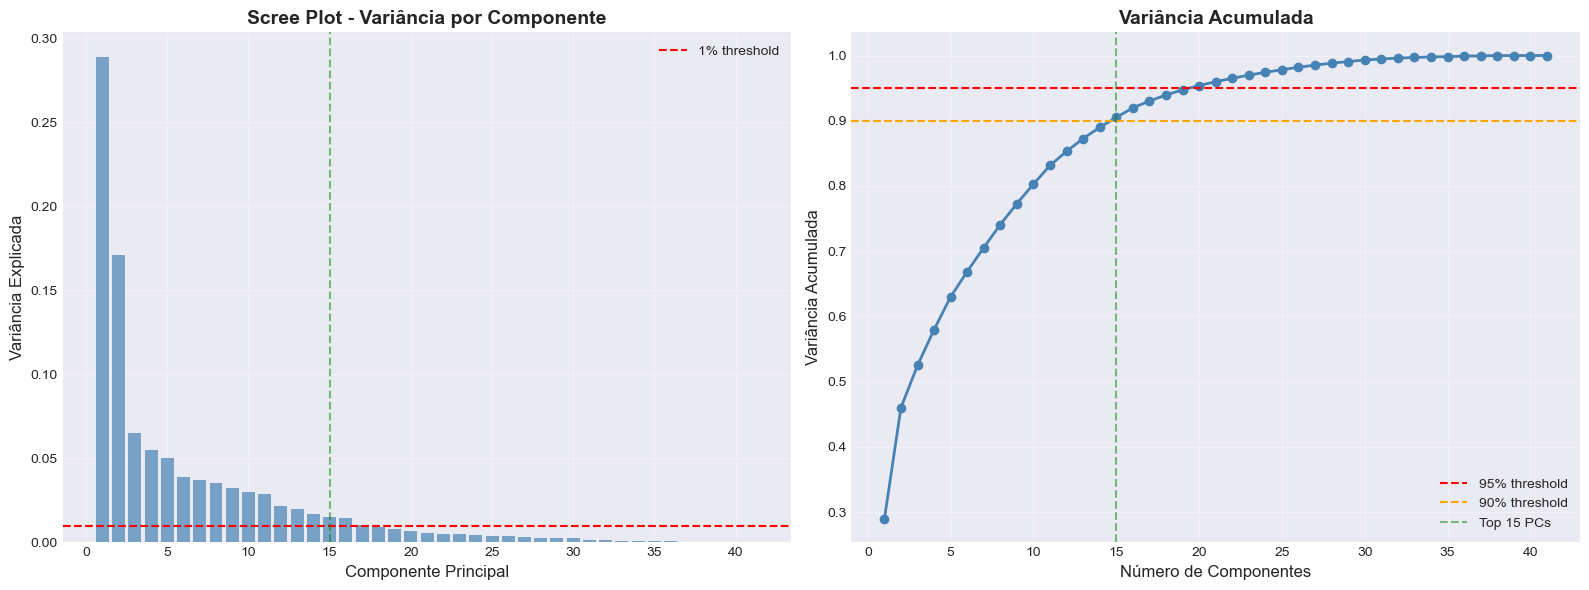


────────────────────────────────────────────────────────────────────────────────
CONTRIBUIÇÃO DAS FEATURES PARA A VARIÂNCIA TOTAL:
────────────────────────────────────────────────────────────────────────────────

📊 TOP 20 FEATURES (maior contribuição):


,feature,contribuicao_variancia,contrib_pct,contrib_acum
11,pct_modalidade_c_scaled,0.0367,3.6749,3.6749
12,pct_modalidade_d_scaled,0.0367,3.6734,7.3483
25,num_obras_ultranicho_scaled,0.0367,3.6726,11.0209
16,pib_per_capita_scaled,0.0365,3.6457,14.6666
13,pct_sessoes_legendadas_scaled,0.0364,3.6384,18.3050
24,pct_obras_exclusivas_scaled,0.0363,3.6283,21.9333
17,ingressos_per_capita_municipio_scaled,0.0360,3.6041,25.5374
0,num_salas_scaled,0.0359,3.5935,29.1310
22,obras_cinema_mundial_scaled,0.0359,3.5866,32.7175
23,pct_obras_cinema_mundial_scaled,0.0352,3.5191,36.2367



📊 BOTTOM 15 FEATURES (menor contribuição):


,feature,contribuicao_variancia,contrib_pct,contrib_acum
3,volume_log_scaled,0.0280,2.8047,91.4580
7,produtora_nivel_medio_complexo_scaled,0.0279,2.7941,94.2521
34,faixa_renda_cat_Media_Baixa,0.0081,0.8078,95.0600
35,e_capital,0.0080,0.7971,95.8570
29,porte_municipio_cat_Metropole,0.0074,0.7376,96.5946
33,faixa_renda_cat_Media_Alta,0.0070,0.6950,97.2897
38,exibidor_independente,0.0057,0.5656,97.8553
32,faixa_renda_cat_Baixa,0.0055,0.5478,98.4031
28,porte_municipio_cat_Medio,0.0043,0.4316,98.8347
37,natureza_nao_informada,0.0034,0.3384,99.1731



────────────────────────────────────────────────────────────────────────────────
FEATURES QUE EXPLICAM OS ÚLTIMOS 5% DE VARIÂNCIA:
────────────────────────────────────────────────────────────────────────────────

✅ Features que explicam 95% da variância: 28
⚠️  Features nos últimos 5%: 13

📋 Lista das 13 features candidatas à remoção:
   • faixa_renda_cat_Media_Baixa                        (contrib: 0.808%)
   • e_capital                                          (contrib: 0.797%)
   • porte_municipio_cat_Metropole                      (contrib: 0.738%)
   • faixa_renda_cat_Media_Alta                         (contrib: 0.695%)
   • exibidor_independente                              (contrib: 0.566%)
   • faixa_renda_cat_Baixa                              (contrib: 0.548%)
   • porte_municipio_cat_Medio                          (contrib: 0.432%)
   • natureza_nao_informada                             (contrib: 0.338%)
   • porte_municipio_cat_Muito_Grande                   (contrib: 0.32

In [35]:
# ════════════════════════════════════════════════════════════════════════════
# ANÁLISE DE VARIÂNCIA: Quais features contribuem menos?
# ════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("ANÁLISE DE VARIÂNCIA - PCA")
print("=" * 80)

print("\n💡 OBJETIVO:")
print("   Identificar features que contribuem pouco para a variância total")
print("   → Candidatas à remoção se explicam apenas os últimos 5% de variância\n")

# Aplicar PCA com TODOS os componentes
n_features_fase2 = X_fase2.shape[1]
pca_full = PCA(n_components=n_features_fase2, random_state=42)
pca_full.fit(X_fase2)

# Variância explicada
var_explicada = pca_full.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

print(f"📊 RESUMO:")
print(f"   Total de features: {n_features_fase2}")
print(f"   Variância explicada pelo PC1: {var_explicada[0]:.4f} ({var_explicada[0]*100:.2f}%)")
print(f"   Variância acumulada em 15 PCs: {var_acumulada[14]:.4f} ({var_acumulada[14]*100:.2f}%)")
print(f"   Variância acumulada em 20 PCs: {var_acumulada[19]:.4f} ({var_acumulada[19]*100:.2f}%)")

# ════════════════════════════════════════════════════════════════════════════
# SCREE PLOT
# ════════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Variância por componente
ax1.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.7, color='steelblue')
ax1.axhline(y=0.01, color='red', linestyle='--', label='1% threshold')
ax1.set_xlabel('Componente Principal', fontsize=12)
ax1.set_ylabel('Variância Explicada', fontsize=12)
ax1.set_title('Scree Plot - Variância por Componente', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Destacar top 15
ax1.axvline(x=15, color='green', linestyle='--', alpha=0.5, label='Top 15')

# Plot 2: Variância acumulada
ax2.plot(range(1, len(var_acumulada)+1), var_acumulada, 'o-', color='steelblue', linewidth=2)
ax2.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
ax2.axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
ax2.axvline(x=15, color='green', linestyle='--', alpha=0.5, label='Top 15 PCs')
ax2.set_xlabel('Número de Componentes', fontsize=12)
ax2.set_ylabel('Variância Acumulada', fontsize=12)
ax2.set_title('Variância Acumulada', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# CONTRIBUIÇÃO DAS FEATURES PARA VARIÂNCIA
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "─" * 80)
print("CONTRIBUIÇÃO DAS FEATURES PARA A VARIÂNCIA TOTAL:")
print("─" * 80)

# Calcular contribuição de cada feature (loadings quadrados ponderados)
loadings = pca_full.components_  # (n_components, n_features)
contribuicoes = []

for i, feat in enumerate(features_fase2):
    # Contribuição = soma ponderada dos loadings quadrados pela var explicada
    contrib = sum(loadings[j, i]**2 * var_explicada[j] for j in range(n_features_fase2))
    contribuicoes.append({
        'feature': feat,
        'contribuicao_variancia': contrib
    })

df_contrib = pd.DataFrame(contribuicoes).sort_values('contribuicao_variancia', ascending=False)
df_contrib['contrib_pct'] = df_contrib['contribuicao_variancia'] * 100
df_contrib['contrib_acum'] = df_contrib['contrib_pct'].cumsum()

print(f"\n📊 TOP 20 FEATURES (maior contribuição):")
display(df_contrib.head(20))

print(f"\n📊 BOTTOM 15 FEATURES (menor contribuição):")
display(df_contrib.tail(15))

# ════════════════════════════════════════════════════════════════════════════
# IDENTIFICAR FEATURES QUE EXPLICAM ÚLTIMOS 5%
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "─" * 80)
print("FEATURES QUE EXPLICAM OS ÚLTIMOS 5% DE VARIÂNCIA:")
print("─" * 80)

# Features que juntas explicam de 95% a 100%
threshold_95 = df_contrib[df_contrib['contrib_acum'] <= 95.0]
n_top_95 = len(threshold_95)

features_bottom_5pct = df_contrib.tail(n_features_fase2 - n_top_95)

print(f"\n✅ Features que explicam 95% da variância: {n_top_95}")
print(f"⚠️  Features nos últimos 5%: {len(features_bottom_5pct)}")

if len(features_bottom_5pct) > 0:
    print(f"\n📋 Lista das {len(features_bottom_5pct)} features candidatas à remoção:")
    for idx, row in features_bottom_5pct.iterrows():
        print(f"   • {row['feature']:50s} (contrib: {row['contrib_pct']:.3f}%)")
    
    print(f"\n💡 RECOMENDAÇÃO:")
    print(f"   Considerar remover as {len(features_bottom_5pct)} features acima na Fase 3")
    print(f"   → Simplifica modelo sem perda significativa de informação")
else:
    print(f"\n✅ Todas as features contribuem significativamente (>5%)")



## 4.2.3 Rodada 3

In [36]:
print("=" * 80)
print("FASE 3: REMOÇÃO DE FEATURES DERIVADAS")
print("=" * 80)

features_remover_fase3 = [
    'pct_obras_nao_anglo_scaled',          # Derivada: soma de outras 2
    'pct_obras_cinema_mundial_scaled',     # Redundante com obras_num
    'porte_municipio_cat_Metropole',       # Porte do município one-hot econding não ajudou
    'porte_municipio_cat_Muito_Grande',    # Porte do município one-hot econding não ajudou                    
    'porte_municipio_cat_Medio',           # Porte do município one-hot econding não ajudou                          
    'porte_municipio_cat_Pequeno',         # Porte do município one-hot econding não ajudou  
    'operacao_nao_comercial'               # Não há muitos complexos com operação não comercial              
]

print(f"\n📋 Features a remover (Fase 3):")
for feat in features_remover_fase3:
    existe = feat in features_fase2
    print(f"  {'✓' if existe else '✗'} {feat}")

indices_remover_fase3 = [i for i, f in enumerate(features_fase2) if f in features_remover_fase3]

X_fase3 = np.delete(X_fase2, indices_remover_fase3, axis=1)
features_fase3 = [f for f in features_fase2 if f not in features_remover_fase3]

# Criar DataFrame com features normalizadas da Fase 3
df_features_fase3 = pd.DataFrame(
    X_fase3,
    columns=features_fase3
)

# Adicionar colunas de identificação (do df original)
df_features_fase3['REGISTRO_COMPLEXO'] = df_features_fase2['REGISTRO_COMPLEXO'].values
df_features_fase3['municipio'] = df_features_fase2['municipio'].values
df_features_fase3['UF'] = df_features_fase2['UF'].values

print(f"\n✅ DataFrame Fase 3 criado:")
print(f"   Shape: {df_features_fase3.shape}")
print(f"   Features: {len(features_fase3)}")
print(f"   Complexos: {len(df_features_fase3)}")

print(f"\n✅ Fase 3 concluída:")
print(f"  Complexos: {X_fase3.shape[0]} (mantidos)")
print(f"  Features: {X_fase3.shape[1]} (removidas 7)")

print("\n" + "=" * 80)

FASE 3: REMOÇÃO DE FEATURES DERIVADAS

📋 Features a remover (Fase 3):
  ✓ pct_obras_nao_anglo_scaled
  ✓ pct_obras_cinema_mundial_scaled
  ✓ porte_municipio_cat_Metropole
  ✓ porte_municipio_cat_Muito_Grande
  ✓ porte_municipio_cat_Medio
  ✓ porte_municipio_cat_Pequeno
  ✓ operacao_nao_comercial

✅ DataFrame Fase 3 criado:
   Shape: (875, 37)
   Features: 34
   Complexos: 875

✅ Fase 3 concluída:
  Complexos: 875 (mantidos)
  Features: 34 (removidas 7)



In [37]:
print("=" * 80)
print("CLUSTERIZAÇÃO FASE 3")
print("=" * 80)

resultados_fase3 = []

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase3)
    
    sil = silhouette_score(X_fase3, labels)
    db = davies_bouldin_score(X_fase3, labels)
    ch = calinski_harabasz_score(X_fase3, labels)
    
    resultados_fase3.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'inertia': kmeans.inertia_
    })
    
    print(f"k={k}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.1f}")

df_resultados_fase3 = pd.DataFrame(resultados_fase3)

# Comparação
print("\n" + "=" * 80)
print("COMPARAÇÃO FASE 2 vs FASE 3:")
print("=" * 80)

print(f"\n{'k':>3} | {'Sil_Fase2':>10} | {'Sil_Fase3':>10} | {'Delta':>8}")
print("-" * 40)

for i in range(len(df_resultados_fase2)):
    k = int(df_resultados_fase2.iloc[i]['k'])
    sil2 = df_resultados_fase2.iloc[i]['silhouette']
    sil3 = df_resultados_fase3.iloc[i]['silhouette']
    delta = sil3 - sil2
    simbolo = "↑" if delta > 0 else "↓"
    print(f"{k:3d} | {sil2:10.4f} | {sil3:10.4f} | {delta:+7.4f} {simbolo}")

print("\n" + "=" * 80)

CLUSTERIZAÇÃO FASE 3
k=4: Silhouette=0.1849, DB=1.7508, CH=170.9
k=5: Silhouette=0.1919, DB=1.4992, CH=149.3
k=6: Silhouette=0.1432, DB=1.7335, CH=138.5
k=7: Silhouette=0.1440, DB=1.5206, CH=133.7
k=8: Silhouette=0.1279, DB=1.4018, CH=122.8

COMPARAÇÃO FASE 2 vs FASE 3:

  k |  Sil_Fase2 |  Sil_Fase3 |    Delta
----------------------------------------
  4 |     0.1964 |     0.1849 | -0.0116 ↓
  5 |     0.1514 |     0.1919 | +0.0405 ↑
  6 |     0.1518 |     0.1432 | -0.0086 ↓
  7 |     0.1533 |     0.1440 | -0.0094 ↓
  8 |     0.1394 |     0.1279 | -0.0115 ↓



In [38]:
print("=" * 80)
print("DIAGNÓSTICO FASE 3")
print("=" * 80)

# VIF
features_cont_fase3 = [f for f in features_fase3 if f.endswith('_scaled')]
idx_cont = [i for i, f in enumerate(features_fase3) if f.endswith('_scaled')]
X_cont_fase3 = X_fase3[:, idx_cont]

vif_fase3 = []
for i in range(len(features_cont_fase3)):
    vif = variance_inflation_factor(X_cont_fase3, i)
    vif_fase3.append({'feature': features_cont_fase3[i], 'VIF': vif})

df_vif_fase3 = pd.DataFrame(vif_fase3).sort_values('VIF', ascending=False)

print(f"\nVIF APÓS FASE 3:")
print(f"Features com VIF > 30: {len(df_vif_fase3[df_vif_fase3['VIF'] > 30])}")
print(f"Features com VIF = inf: {len(df_vif_fase3[df_vif_fase3['VIF'] == np.inf])}")
display(df_vif_fase3.head(15))

# Correlação
corr_matrix_fase3 = np.corrcoef(X_fase3.T)

pares_fase3 = []
for i in range(len(features_fase3)):
    for j in range(i+1, len(features_fase3)):
        corr_val = abs(corr_matrix_fase3[i, j])
        if corr_val > 0.85:
            pares_fase3.append({
                'feat1': features_fase3[i],
                'feat2': features_fase3[j],
                'corr_abs': corr_val
            })

df_corr_fase3 = pd.DataFrame(pares_fase3).sort_values('corr_abs', ascending=False)

print(f"\nPARES COM |CORRELAÇÃO| > 0.85:")
print(f"Total: {len(df_corr_fase3)}")
display(df_corr_fase3)

print("\n" + "=" * 80)

DIAGNÓSTICO FASE 3

VIF APÓS FASE 3:
Features com VIF > 30: 0
Features com VIF = inf: 0


,feature,VIF
3,volume_log_scaled,26.0442
8,pct_sessoes_brasileiras_scaled,23.9336
4,pct_sessoes_major_scaled,15.2721
6,pct_sessoes_produtora_independente_scaled,13.5641
0,num_salas_scaled,10.4687
1,pct_dias_operando_scaled,8.9744
18,entropia_nacionalidade_scaled,7.9744
21,entropia_distribuidora_scaled,6.6287
22,obras_cinema_mundial_scaled,6.5256
14,pct_publico_obras_top5_scaled,5.5161



PARES COM |CORRELAÇÃO| > 0.85:
Total: 3


,feat1,feat2,corr_abs
2,perfil_independente_scaled,exibidor_independente,0.9590
1,pct_sessoes_produtora_independente_scaled,pct_sessoes_brasileiras_scaled,0.9349
0,pct_sessoes_major_scaled,pct_publico_obras_top5_scaled,0.8507


## 4.3 Resultados da seleção de features

ANÁLISE DE SILHOUETTE POR COMPLEXO

Cluster 0 (399 complexos):
  Silhouette médio: 0.1009
  Negativos: 66 (16.5%)
  Baixos (0-0.1): 127 (31.8%)

Cluster 1 (407 complexos):
  Silhouette médio: 0.2895
  Negativos: 0 (0.0%)
  Baixos (0-0.1): 16 (3.9%)

Cluster 2 (19 complexos):
  Silhouette médio: 0.0344
  Negativos: 6 (31.6%)
  Baixos (0-0.1): 6 (31.6%)

Cluster 3 (48 complexos):
  Silhouette médio: 0.1776
  Negativos: 8 (16.7%)
  Baixos (0-0.1): 9 (18.8%)

Cluster 4 (2 complexos):
  Silhouette médio: 0.3333
  Negativos: 0 (0.0%)
  Baixos (0-0.1): 0 (0.0%)

TOP 20 COMPLEXOS COM PIOR SILHOUETTE:


,REGISTRO_COMPLEXO,municipio,UF,cluster_k5,silhouette_score,num_salas_scaled,volume_log_scaled,pct_sessoes_brasileiras_scaled
855,6708,NITERÓI,RJ,2,-0.1974,-1.1693,-1.0622,3.8365
440,32398,SÃO PAULO,SP,2,-0.1969,-1.1693,-1.1155,2.1409
664,49176,SÃO PAULO,SP,2,-0.1649,0.6994,0.8347,0.7371
839,6636,SÃO PAULO,SP,3,-0.1351,1.8206,0.9493,0.9011
267,25394,MARABÁ,PA,0,-0.1113,0.3257,0.5447,-0.1492
611,44285,ANDRADINA,SP,0,-0.1110,-0.0481,0.4151,-0.2536
242,24785,SÃO LUÍS,MA,2,-0.1008,-1.1693,-1.5765,2.1159
87,16969,MARACANAÚ,CE,0,-0.1002,-0.0481,0.4287,-0.0545
164,21325,RIO DE JANEIRO,RJ,3,-0.0992,0.6994,0.6525,1.3383
702,50926,FORTALEZA,CE,0,-0.0955,-0.7956,-0.0211,-0.6095


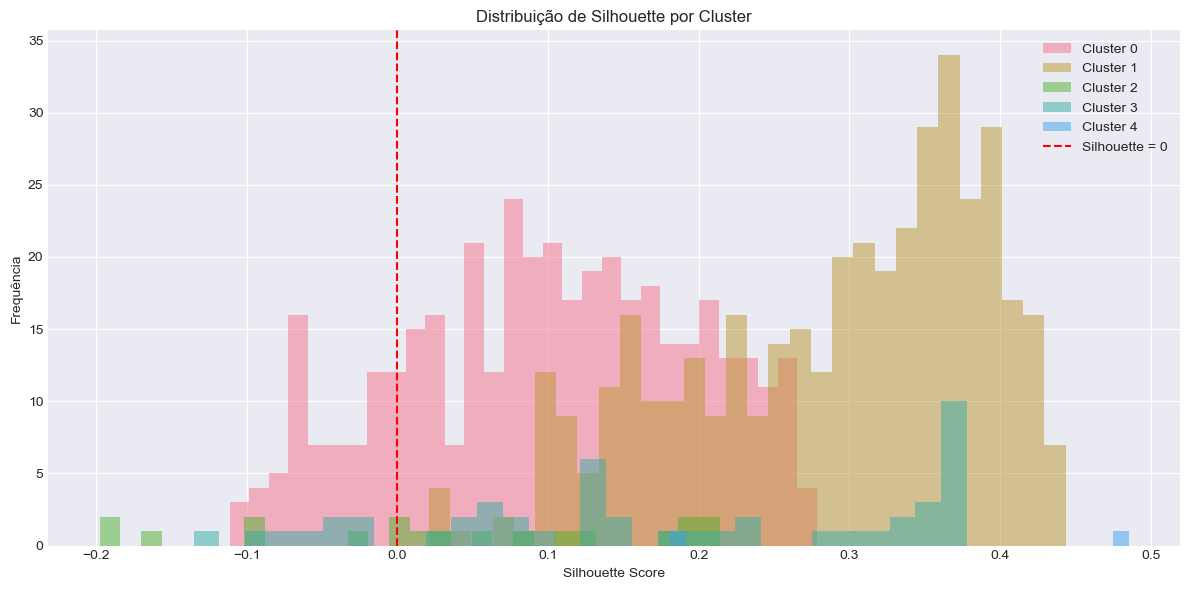


📊 Total de complexos com Silhouette negativo: 80


In [39]:
# Calcular Silhouette por complexo (k=5, Fase 3)
kmeans_k5 = KMeans(n_clusters=5, random_state=42, n_init=20)
labels_k5 = kmeans_k5.fit_predict(X_fase3)
sil_samples = silhouette_samples(X_fase3, labels_k5)

# Adicionar ao DataFrame
df_features_fase3['silhouette_score'] = sil_samples
df_features_fase3['cluster_k5'] = labels_k5

# Identificar problemáticos
print("=" * 80)
print("ANÁLISE DE SILHOUETTE POR COMPLEXO")
print("=" * 80)

# Estatísticas por cluster
for cluster_id in range(5):
    mask = labels_k5 == cluster_id
    sil_cluster = sil_samples[mask]
    
    negativos = (sil_cluster < 0).sum()
    baixos = ((sil_cluster >= 0) & (sil_cluster < 0.1)).sum()
    
    print(f"\nCluster {cluster_id} ({mask.sum()} complexos):")
    print(f"  Silhouette médio: {sil_cluster.mean():.4f}")
    print(f"  Negativos: {negativos} ({negativos/len(sil_cluster)*100:.1f}%)")
    print(f"  Baixos (0-0.1): {baixos} ({baixos/len(sil_cluster)*100:.1f}%)")

# Top 20 piores
print("\n" + "=" * 80)
print("TOP 20 COMPLEXOS COM PIOR SILHOUETTE:")
print("=" * 80)

piores = df_features_fase3.nsmallest(20, 'silhouette_score')[
    ['REGISTRO_COMPLEXO', 'municipio', 'UF', 'cluster_k5', 'silhouette_score', 
     'num_salas_scaled', 'volume_log_scaled', 'pct_sessoes_brasileiras_scaled']
]
display(piores)

# Gráfico de distribuição
fig, ax = plt.subplots(figsize=(12, 6))
for cluster_id in range(5):
    mask = labels_k5 == cluster_id
    sil_cluster = sil_samples[mask]
    ax.hist(sil_cluster, bins=30, alpha=0.5, label=f'Cluster {cluster_id}')

ax.axvline(0, color='red', linestyle='--', label='Silhouette = 0')
ax.set_xlabel('Silhouette Score')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Silhouette por Cluster')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Total de complexos com Silhouette negativo: {(sil_samples < 0).sum()}")

In [40]:
# Testar várias dimensões
for n_comp in [25, 30, 34]:  # 34 = todas
    if n_comp >= X_fase3.shape[1]:
        X_pca = X_fase3
        var_exp = 1.0
    else:
        pca = PCA(n_components=n_comp, random_state=42)
        X_pca = pca.fit_transform(X_fase3)
        var_exp = pca.explained_variance_ratio_.sum()
    
    # Clusterizar
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    
    print(f"PCA {n_comp:2d} componentes (var={var_exp:.3f}): Silhouette = {sil:.4f}")

PCA 25 componentes (var=0.989): Silhouette = 0.1946
PCA 30 componentes (var=0.998): Silhouette = 0.1924
PCA 34 componentes (var=1.000): Silhouette = 0.1919


In [41]:
# Treinar RF para "prever" clusters (como se fossem classes)
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_fase3, labels_k5)

# Importância
importancias = pd.DataFrame({
    'feature': features_fase3,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

print("TOP 25 FEATURES MAIS IMPORTANTES PARA SEPARAÇÃO:")
display(importancias.head(25))

print("\nBOTTOM 10 (menos importantes):")
display(importancias.tail(10))

# Testar removendo as 5 menos importantes
features_remover_rf = importancias.tail(5)['feature'].tolist()
print(f"\nTestar remover: {features_remover_rf}")

TOP 25 FEATURES MAIS IMPORTANTES PARA SEPARAÇÃO:


,feature,importancia
3,volume_log_scaled,0.1432
22,obras_cinema_mundial_scaled,0.1343
0,num_salas_scaled,0.1033
4,pct_sessoes_major_scaled,0.0987
15,populacao_scaled,0.0523
18,entropia_nacionalidade_scaled,0.0512
9,pct_sessoes_especiais_scaled,0.0437
20,entropia_faixa_horaria_scaled,0.0394
21,entropia_distribuidora_scaled,0.0389
8,pct_sessoes_brasileiras_scaled,0.0374



BOTTOM 10 (menos importantes):


,feature,importancia
24,num_obras_ultranicho_scaled,0.0039
32,natureza_nao_privada,0.0031
12,pct_modalidade_d_scaled,0.0028
29,e_capital,0.0022
11,pct_modalidade_c_scaled,0.0017
28,faixa_renda_cat_Media_Baixa,0.0014
27,faixa_renda_cat_Media_Alta,0.0010
30,natureza_nao_informada,0.0008
26,faixa_renda_cat_Baixa,0.0006
33,caso_extremo_atividade,0.0004



Testar remover: ['faixa_renda_cat_Media_Baixa', 'faixa_renda_cat_Media_Alta', 'natureza_nao_informada', 'faixa_renda_cat_Baixa', 'caso_extremo_atividade']


In [42]:
def gap_statistic(X, k_max=10, n_refs=10):
    gaps = []
    for k in range(2, k_max+1):
        # Clustering real
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X)
        inertia_real = kmeans.inertia_
        
        # Clustering em dados aleatórios (referência)
        inertias_ref = []
        for _ in range(n_refs):
            X_rand = np.random.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
            kmeans_rand = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans_rand.fit(X_rand)
            inertias_ref.append(kmeans_rand.inertia_)
        
        gap = np.log(np.mean(inertias_ref)) - np.log(inertia_real)
        gaps.append(gap)
    
    return gaps

gaps = gap_statistic(X_fase3, k_max=8)

for i, gap in enumerate(gaps, start=2):
    print(f"k={i}: Gap = {gap:.4f}")

print(f"\nMelhor k: {np.argmax(gaps) + 2}")

k=2: Gap = 2.4011
k=3: Gap = 2.4528
k=4: Gap = 2.4681
k=5: Gap = 2.4898
k=6: Gap = 2.5271
k=7: Gap = 2.5729
k=8: Gap = 2.5854

Melhor k: 8


In [43]:
# MinMaxScaler (0-1)
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_fase3)

kmeans_mm = KMeans(n_clusters=5, random_state=42, n_init=20)
labels_mm = kmeans_mm.fit_predict(X_mm)
sil_mm = silhouette_score(X_mm, labels_mm)

print(f"MinMaxScaler:   Silhouette = {sil_mm:.4f}")

# RobustScaler (resistente a outliers)
scaler_rb = RobustScaler()
X_rb = scaler_rb.fit_transform(X_fase3)

kmeans_rb = KMeans(n_clusters=5, random_state=42, n_init=20)
labels_rb = kmeans_rb.fit_predict(X_rb)
sil_rb = silhouette_score(X_rb, labels_rb)

print(f"RobustScaler:   Silhouette = {sil_rb:.4f}")
print(f"StandardScaler: Silhouette = 0.2003 (atual)")

MinMaxScaler:   Silhouette = 0.2888
RobustScaler:   Silhouette = 0.7460
StandardScaler: Silhouette = 0.2003 (atual)


# 5 Otimização do Modelo

## 5.1 Identificação de features para robustscaler

In [44]:
# =============================================================================
# 5. OTIMIZAÇÃO DO MODELO
# =============================================================================

print("=" * 80)
print("5.1 - IDENTIFICAÇÃO DE FEATURES PARA ROBUSTSCALER")
print("=" * 80)

# Partir dos dados da Seção 4.2
print(f"\n📊 Dados de entrada (Seção 4.2):")
print(f"  Complexos: {X_fase3.shape[0]}")
print(f"  Features: {X_fase3.shape[1]}")
print(f"  Lista: features_fase3 ({len(features_fase3)} elementos)")

# Categorizar features por tipo
features_continuas = [f for f in features_fase3 if f.endswith('_scaled')]
features_binarias = [f for f in features_fase3 if not f.endswith('_scaled') and 'cat' not in f.lower()]
features_categoricas = [f for f in features_fase3 if 'cat' in f.lower()]

print(f"\n" + "─" * 80)
print("CATEGORIZAÇÃO DAS FEATURES:")
print("─" * 80)

print(f"\n📈 FEATURES CONTÍNUAS (_scaled): {len(features_continuas)}")
print(f"   → Receberão RobustScaler (resistente a outliers)")
for i, feat in enumerate(features_continuas, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n🔘 FEATURES BINÁRIAS (0/1): {len(features_binarias)}")
print(f"   → Mantidas intactas (não normalizar)")
for i, feat in enumerate(features_binarias, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n🏷️  FEATURES CATEGÓRICAS (one-hot): {len(features_categoricas)}")
print(f"   → Mantidas intactas (já são 0/1)")
for i, feat in enumerate(features_categoricas, 1):
    print(f"   {i:2d}. {feat}")

# Validação
total_categorizado = len(features_continuas) + len(features_binarias) + len(features_categoricas)
print(f"\n" + "─" * 80)
print(f"✅ Validação: {total_categorizado} features categorizadas = {len(features_fase3)} total")
assert total_categorizado == len(features_fase3), "❌ ERRO: Categorização incompleta!"

print("\n" + "=" * 80)

5.1 - IDENTIFICAÇÃO DE FEATURES PARA ROBUSTSCALER

📊 Dados de entrada (Seção 4.2):
  Complexos: 875
  Features: 34
  Lista: features_fase3 (34 elementos)

────────────────────────────────────────────────────────────────────────────────
CATEGORIZAÇÃO DAS FEATURES:
────────────────────────────────────────────────────────────────────────────────

📈 FEATURES CONTÍNUAS (_scaled): 26
   → Receberão RobustScaler (resistente a outliers)
    1. num_salas_scaled
    2. pct_dias_operando_scaled
    3. sessoes_por_dia_sala_scaled
    4. volume_log_scaled
    5. pct_sessoes_major_scaled
    6. pct_sessoes_distrib_independente_scaled
    7. pct_sessoes_produtora_independente_scaled
    8. produtora_nivel_medio_complexo_scaled
    9. pct_sessoes_brasileiras_scaled
   10. pct_sessoes_especiais_scaled
   11. pct_modalidade_b_scaled
   12. pct_modalidade_c_scaled
   13. pct_modalidade_d_scaled
   14. pct_sessoes_legendadas_scaled
   15. pct_publico_obras_top5_scaled
   16. populacao_scaled
   17. pib_pe

## 5.2 Análise de Distribuições das Features Contínuas

In [45]:
print("=" * 80)
print("5.2 - ANÁLISE DE DISTRIBUIÇÕES (Justificativa RobustScaler)")
print("=" * 80)

# Extrair apenas features contínuas do X_fase3
indices_continuas = [i for i, f in enumerate(features_fase3) if f.endswith('_scaled')]
X_continuas = X_fase3[:, indices_continuas]

# Calcular estatísticas (dados já normalizados por StandardScaler)
# Vamos olhar para a presença de outliers (valores > 3 ou < -3 desvios)

print(f"\n📊 Análise de outliers nas {len(features_continuas)} features contínuas:")
print(f"   (Valores considerados outliers: |z| > 3)\n")

outlier_stats = []

for i, feat in enumerate(features_continuas):
    valores = X_continuas[:, i]
    
    # Contar outliers extremos (|z| > 3)
    outliers_positivos = (valores > 3).sum()
    outliers_negativos = (valores < -3).sum()
    total_outliers = outliers_positivos + outliers_negativos
    pct_outliers = (total_outliers / len(valores)) * 100
    
    # Estatísticas básicas
    q25, q50, q75 = np.percentile(valores, [25, 50, 75])
    iqr = q75 - q25
    
    outlier_stats.append({
        'feature': feat,
        'n_outliers': total_outliers,
        'pct_outliers': pct_outliers,
        'min': valores.min(),
        'max': valores.max(),
        'q25': q25,
        'mediana': q50,
        'q75': q75,
        'IQR': iqr
    })

df_outliers = pd.DataFrame(outlier_stats).sort_values('n_outliers', ascending=False)

print("─" * 80)
print("TOP 15 FEATURES COM MAIS OUTLIERS:")
print("─" * 80)
display(df_outliers.head(15)[['feature', 'n_outliers', 'pct_outliers', 'min', 'max']])

print("─" * 80)
print("RESUMO:")
print("─" * 80)

features_com_outliers = (df_outliers['n_outliers'] > 0).sum()
total_outliers_dataset = df_outliers['n_outliers'].sum()

print(f"  Features com outliers (|z|>3): {features_com_outliers}/{len(features_continuas)} ({features_com_outliers/len(features_continuas)*100:.1f}%)")
print(f"  Total de valores outliers: {total_outliers_dataset}")
print(f"  Média de outliers por feature: {total_outliers_dataset/len(features_continuas):.1f}")

print(f"\n💡 INTERPRETAÇÃO:")
print(f"   StandardScaler (atual) usa média/desvio → SENSÍVEL a esses outliers")
print(f"   RobustScaler usa mediana/IQR → RESISTENTE a esses outliers")
print(f"   → Esperado: RobustScaler melhore separação dos clusters")

print("\n" + "=" * 80)

5.2 - ANÁLISE DE DISTRIBUIÇÕES (Justificativa RobustScaler)

📊 Análise de outliers nas 26 features contínuas:
   (Valores considerados outliers: |z| > 3)

────────────────────────────────────────────────────────────────────────────────
TOP 15 FEATURES COM MAIS OUTLIERS:
────────────────────────────────────────────────────────────────────────────────


,feature,n_outliers,pct_outliers,min,max
14,pct_publico_obras_top5_scaled,31,3.5429,-3.9946,0.8636
4,pct_sessoes_major_scaled,27,3.0857,-4.7015,1.6927
18,entropia_nacionalidade_scaled,23,2.6286,-2.3392,4.3715
21,entropia_distribuidora_scaled,22,2.5143,-5.9792,0.8373
13,pct_sessoes_legendadas_scaled,21,2.4000,-0.6310,4.1658
19,entropia_modalidade_scaled,18,2.0571,-0.5769,6.9227
23,pct_obras_exclusivas_scaled,17,1.9429,-0.1862,16.7130
6,pct_sessoes_produtora_independente_scaled,16,1.8286,-1.2542,10.1385
8,pct_sessoes_brasileiras_scaled,14,1.6000,-1.4553,10.1951
10,pct_modalidade_b_scaled,14,1.6000,-0.4236,10.4413


────────────────────────────────────────────────────────────────────────────────
RESUMO:
────────────────────────────────────────────────────────────────────────────────
  Features com outliers (|z|>3): 23/26 (88.5%)
  Total de valores outliers: 322
  Média de outliers por feature: 12.4

💡 INTERPRETAÇÃO:
   StandardScaler (atual) usa média/desvio → SENSÍVEL a esses outliers
   RobustScaler usa mediana/IQR → RESISTENTE a esses outliers
   → Esperado: RobustScaler melhore separação dos clusters



## 5.3 Importação da matriz original para robust scaler

In [46]:
# %%
# 5.3.1 - CARREGAMENTO E REMOÇÃO DE COMPLEXOS

print("=" * 80)
print("5.3.1 - CARREGAMENTO E REMOÇÃO DE COMPLEXOS")
print("=" * 80)

# Carregar dados originais (não normalizados)
print("\n🔄 Carregando df_features_final.parquet...")

df_original = pd.read_parquet('../Bases/df_features_final.parquet')
print(f"✅ Carregado: {df_original.shape}")

# Remover sufixo '_scaled' (cosmético)
df_original.columns = [col.replace('_scaled', '') for col in df_original.columns]
print(f"✅ Sufixo '_scaled' removido")

# Remoção de complexos
print("\n" + "─" * 80)
print("🗑️  REMOÇÃO DE COMPLEXOS")
print("─" * 80)

# Outliers extremos
outliers_extremos = ['17778', '19846', '28343', '31000', '34842', '6616']

# Complexos com baixa_atividade
complexos_baixa_atividade = df_original[
    df_original['baixa_atividade'] == 1
]['REGISTRO_COMPLEXO'].tolist()

# Consolidar
COMPLEXOS_A_REMOVER = list(set(outliers_extremos + complexos_baixa_atividade))

print(f"\n📋 Complexos a remover:")
print(f"   Outliers extremos: {len(outliers_extremos)}")
print(f"   Baixa atividade: {len(complexos_baixa_atividade)}")
print(f"   TOTAL: {len(COMPLEXOS_A_REMOVER)}")

# Remover
mask_manter = ~df_original['REGISTRO_COMPLEXO'].isin(COMPLEXOS_A_REMOVER)
df_clean = df_original[mask_manter].copy()

print(f"\n✅ Complexos removidos: {len(COMPLEXOS_A_REMOVER)}")
print(f"✅ Complexos restantes: {len(df_clean)}")

# Atualizar df_features
df_features = df_clean.copy()
print(f"✅ df_features atualizado: {len(df_features)} complexos")

print("\n" + "=" * 80)

5.3.1 - CARREGAMENTO E REMOÇÃO DE COMPLEXOS

🔄 Carregando df_features_final.parquet...
✅ Carregado: (900, 78)
✅ Sufixo '_scaled' removido

────────────────────────────────────────────────────────────────────────────────
🗑️  REMOÇÃO DE COMPLEXOS
────────────────────────────────────────────────────────────────────────────────

📋 Complexos a remover:
   Outliers extremos: 6
   Baixa atividade: 24
   TOTAL: 25

✅ Complexos removidos: 25
✅ Complexos restantes: 875
✅ df_features atualizado: 875 complexos



In [47]:
# 5.3.2 - IDENTIFICAÇÃO DE TIPOS DE FEATURES

print("=" * 80)
print("5.3.2 - IDENTIFICAÇÃO DE TIPOS DE FEATURES")
print("=" * 80)

# IDs (não são features)
ids = ['REGISTRO_COMPLEXO', 'UF', 'municipio']

# Features removidas nas fases 1, 2 e 3
features_removidas = [
    'desproporcao_blockbuster', 'intensidade_exibicao',
    'pct_obras_ultranicho', 'pct_sessoes_obras_top5',
    'pct_sessoes_com_distribuidor', 'porte_medio_distribuidora',
    'score_curadoria', 'baixa_atividade',
    'pct_obras_nao_anglo', 'pct_obras_cinema_mundial',
    'porte_municipio_cat_Metropole', 'porte_municipio_cat_Muito_Grande',
    'porte_municipio_cat_Medio', 'porte_municipio_cat_Pequeno',
    'operacao_nao_comercial'
]

# Todas as features (excluindo IDs e removidas)
features_all = [col for col in df_clean.columns 
                if col not in ids and col not in features_removidas]

print(f"\n📊 Features após remoções fase 1-3: {len(features_all)}")

# Identificar categóricas encoded
categorical_encoded = [col for col in features_all if col.startswith(('UF_', 'porte_', 'faixa_'))]

# Remover UFs
ufs_to_remove = [col for col in categorical_encoded if col.startswith('UF_')]
categorical_encoded = [col for col in categorical_encoded if not col.startswith('UF_')]

print(f"🗑️  Removendo {len(ufs_to_remove)} UFs")

# Atualizar features_all (sem UFs)
features_all = [col for col in features_all if not col.startswith('UF_')]

# Numéricas
continuous_cols = [col for col in df_clean[features_all].select_dtypes(include=['float64', 'int64']).columns
                   if col not in categorical_encoded]

# Binárias
binary_cols = [col for col in continuous_cols 
               if df_clean[col].nunique() == 2 
               and set(df_clean[col].unique()).issubset({0, 1})]

# Contínuas
continuous_to_scale = [col for col in continuous_cols if col not in binary_cols]

print(f"\n📊 Categorização:")
print(f"   Total: {len(features_all)}")
print(f"   Contínuas (RobustScaler): {len(continuous_to_scale)}")
print(f"   Binárias: {len(binary_cols)}")
print(f"   Categóricas encoded: {len(categorical_encoded)}")

total_categorizado = len(continuous_to_scale) + len(binary_cols) + len(categorical_encoded)
print(f"\n✅ Validação: {total_categorizado} features categorizadas = {len(features_all)} total")

print("\n" + "=" * 80)

5.3.2 - IDENTIFICAÇÃO DE TIPOS DE FEATURES

📊 Features após remoções fase 1-3: 60
🗑️  Removendo 26 UFs

📊 Categorização:
   Total: 34
   Contínuas (RobustScaler): 26
   Binárias: 5
   Categóricas encoded: 3

✅ Validação: 34 features categorizadas = 34 total



In [48]:
# 5.3.3 - APLICAÇÃO DE ROBUSTSCALER E MONTAGEM FINAL

print("=" * 80)
print("5.3.3 - ROBUSTSCALER E MONTAGEM DA MATRIZ FINAL")
print("=" * 80)

# Aplicar RobustScaler nas contínuas
print(f"\n🔧 Aplicando RobustScaler em {len(continuous_to_scale)} features...")

X_continuas_orig = df_clean[continuous_to_scale].values

scaler_robust = RobustScaler()
X_continuas_robust = scaler_robust.fit_transform(X_continuas_orig)

df_continuas_robust = pd.DataFrame(
    X_continuas_robust,
    columns=[f"{col}_scaled" for col in continuous_to_scale],
    index=df_clean.index
)

print(f"✅ RobustScaler aplicado!")
print(f"   Range: [{X_continuas_robust.min():.2f}, {X_continuas_robust.max():.2f}]")

# Recombinar DataFrame
print(f"\n🔗 Recombinando DataFrame final...")

df_final = pd.concat([
    df_clean[ids],
    df_continuas_robust,
    df_clean[binary_cols],
    df_clean[categorical_encoded]
], axis=1)

print(f"✅ DataFrame final: {df_final.shape}")

# Extrair X e features
features_fase5 = [col for col in df_final.columns if col not in ids]
X_fase5 = df_final[features_fase5].values
df_features_fase5 = df_final.copy()

print(f"\n📦 Variáveis criadas:")
print(f"   X_fase5: {X_fase5.shape}")
print(f"   features_fase5: {len(features_fase5)} elementos")
print(f"   df_features_fase5: {df_features_fase5.shape}")

# Validação final
print(f"\n🔍 Validação:")
print(f"   NaN: {np.isnan(X_fase5).sum()}")
print(f"   Inf: {np.isinf(X_fase5).sum()}")

assert np.isnan(X_fase5).sum() == 0, "❌ NaNs detectados!"
assert np.isinf(X_fase5).sum() == 0, "❌ Infs detectados!"

print("\n" + "=" * 80)
print("✅ PREPARAÇÃO CONCLUÍDA - PRONTO PARA CLUSTERIZAÇÃO")
print("=" * 80)

5.3.3 - ROBUSTSCALER E MONTAGEM DA MATRIZ FINAL

🔧 Aplicando RobustScaler em 26 features...
✅ RobustScaler aplicado!
   Range: [-26.15, 3455.62]

🔗 Recombinando DataFrame final...
✅ DataFrame final: (875, 37)

📦 Variáveis criadas:
   X_fase5: (875, 34)
   features_fase5: 34 elementos
   df_features_fase5: (875, 37)

🔍 Validação:
   NaN: 0
   Inf: 0

✅ PREPARAÇÃO CONCLUÍDA - PRONTO PARA CLUSTERIZAÇÃO


## 5.4 Re-clusterização com RobustScaler

In [49]:
print("=" * 80)
print("5.4 - RE-CLUSTERIZAÇÃO COM ROBUSTSCALER")
print("=" * 80)

resultados_fase5 = []

print(f"\n🔄 Testando k=4 até k=8 com RobustScaler...\n")

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase5)
    
    sil = silhouette_score(X_fase5, labels)
    db = davies_bouldin_score(X_fase5, labels)
    ch = calinski_harabasz_score(X_fase5, labels)
    
    resultados_fase5.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'inertia': kmeans.inertia_
    })
    
    print(f"k={k}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.1f}")

df_resultados_fase5 = pd.DataFrame(resultados_fase5)

print("\n" + "=" * 80)
print("COMPARAÇÃO: StandardScaler (Fase 2) vs RobustScaler (Fase 5)")
print("=" * 80)

print(f"\n{'k':>3} | {'Sil_Std':>10} | {'Sil_Robust':>10} | {'Delta':>10} | {'Melhoria'}")
print("─" * 60)

for i in range(len(df_resultados_fase3)):
    k = int(df_resultados_fase3.iloc[i]['k'])
    sil_std = df_resultados_fase3.iloc[i]['silhouette']
    sil_robust = df_resultados_fase5.iloc[i]['silhouette']
    delta = sil_robust - sil_std
    pct = (delta / sil_std * 100) if sil_std > 0 else 0
    
    if delta > 0.3:
        emoji = "🚀🚀🚀"
    elif delta > 0.1:
        emoji = "🚀🚀"
    elif delta > 0:
        emoji = "↑"
    else:
        emoji = "↓"
    
    print(f"{k:3d} | {sil_std:10.4f} | {sil_robust:10.4f} | {delta:+10.4f} | {pct:+6.1f}% {emoji}")

# Identificar melhor k
melhor_k = df_resultados_fase5.loc[df_resultados_fase5['silhouette'].idxmax(), 'k']
melhor_sil = df_resultados_fase5['silhouette'].max()

print("\n" + "=" * 80)
print(f"🏆 MELHOR RESULTADO: k={int(melhor_k)} com Silhouette={melhor_sil:.4f}")
print("=" * 80)

5.4 - RE-CLUSTERIZAÇÃO COM ROBUSTSCALER

🔄 Testando k=4 até k=8 com RobustScaler...

k=4: Silhouette=0.7978, DB=0.4791, CH=5214.5
k=5: Silhouette=0.7464, DB=0.3782, CH=5582.9
k=6: Silhouette=0.7449, DB=0.2794, CH=7079.0
k=7: Silhouette=0.7620, DB=0.3037, CH=8326.5
k=8: Silhouette=0.7353, DB=0.3584, CH=10315.4

COMPARAÇÃO: StandardScaler (Fase 2) vs RobustScaler (Fase 5)

  k |    Sil_Std | Sil_Robust |      Delta | Melhoria
────────────────────────────────────────────────────────────
  4 |     0.1849 |     0.7978 |    +0.6129 | +331.6% 🚀🚀🚀
  5 |     0.1919 |     0.7464 |    +0.5545 | +289.0% 🚀🚀🚀
  6 |     0.1432 |     0.7449 |    +0.6017 | +420.2% 🚀🚀🚀
  7 |     0.1440 |     0.7620 |    +0.6181 | +429.3% 🚀🚀🚀
  8 |     0.1279 |     0.7353 |    +0.6074 | +475.1% 🚀🚀🚀

🏆 MELHOR RESULTADO: k=4 com Silhouette=0.7978


## 5.5 Análise Deatalhada dos clusters

In [50]:
print("=" * 80)
print("5.5 - ANÁLISE DETALHADA: k=4 vs k=7")
print("=" * 80)

# Treinar ambos os modelos
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=20, max_iter=300)
kmeans_k7 = KMeans(n_clusters=7, random_state=42, n_init=20, max_iter=300)

labels_k4 = kmeans_k4.fit_predict(X_fase5)
labels_k7 = kmeans_k7.fit_predict(X_fase5)

# Distribuição de complexos
print("\n" + "─" * 80)
print("DISTRIBUIÇÃO DE COMPLEXOS:")
print("─" * 80)

print("\n📊 k=4:")
for i in range(4):
    n = (labels_k4 == i).sum()
    pct = n / len(labels_k4) * 100
    print(f"   Cluster {i}: {n:3d} ({pct:5.1f}%)")

print("\n📊 k=7:")
for i in range(7):
    n = (labels_k7 == i).sum()
    pct = n / len(labels_k7) * 100
    emoji = "⚠️" if n < 20 else "✓"
    print(f"   Cluster {i}: {n:3d} ({pct:5.1f}%) {emoji}")

# Silhouette por amostra
sil_samples_k4 = silhouette_samples(X_fase5, labels_k4)
sil_samples_k7 = silhouette_samples(X_fase5, labels_k7)

print("\n" + "─" * 80)
print("QUALIDADE INTERNA DOS CLUSTERS:")
print("─" * 80)

print("\n📈 k=4 - Silhouette por cluster:")
for i in range(4):
    mask = labels_k4 == i
    sil_cluster = sil_samples_k4[mask]
    negativos = (sil_cluster < 0).sum()
    
    print(f"   Cluster {i}: média={sil_cluster.mean():.4f}, negativos={negativos} ({negativos/len(sil_cluster)*100:.1f}%)")

print("\n📈 k=7 - Silhouette por cluster:")
for i in range(7):
    mask = labels_k7 == i
    sil_cluster = sil_samples_k7[mask]
    negativos = (sil_cluster < 0).sum()
    
    print(f"   Cluster {i}: média={sil_cluster.mean():.4f}, negativos={negativos} ({negativos/len(sil_cluster)*100:.1f}%)")

# Adicionar labels ao DataFrame
df_features_fase5['cluster_k4'] = labels_k4
df_features_fase5['cluster_k7'] = labels_k7
df_features_fase5['silhouette_k4'] = sil_samples_k4
df_features_fase5['silhouette_k7'] = sil_samples_k7

print("\n" + "=" * 80)
print("💡 PRÓXIMO PASSO: Caracterizar clusters para decidir entre k=4 e k=7")
print("=" * 80)

5.5 - ANÁLISE DETALHADA: k=4 vs k=7

────────────────────────────────────────────────────────────────────────────────
DISTRIBUIÇÃO DE COMPLEXOS:
────────────────────────────────────────────────────────────────────────────────

📊 k=4:
   Cluster 0: 802 ( 91.7%)
   Cluster 1:   2 (  0.2%)
   Cluster 2:  66 (  7.5%)
   Cluster 3:   5 (  0.6%)

📊 k=7:
   Cluster 0: 753 ( 86.1%) ✓
   Cluster 1:   1 (  0.1%) ⚠️
   Cluster 2:  85 (  9.7%) ✓
   Cluster 3:   1 (  0.1%) ⚠️
   Cluster 4:  21 (  2.4%) ✓
   Cluster 5:  13 (  1.5%) ⚠️
   Cluster 6:   1 (  0.1%) ⚠️

────────────────────────────────────────────────────────────────────────────────
QUALIDADE INTERNA DOS CLUSTERS:
────────────────────────────────────────────────────────────────────────────────

📈 k=4 - Silhouette por cluster:
   Cluster 0: média=0.8308, negativos=1 (0.1%)
   Cluster 1: média=0.6950, negativos=0 (0.0%)
   Cluster 2: média=0.4369, negativos=0 (0.0%)
   Cluster 3: média=0.3077, negativos=0 (0.0%)

📈 k=7 - Silhouette por clu

## 5.6 - DIAGRAMAS DE SILHUETA (Knife Plots)

5.6 - DIAGRAMAS DE SILHUETA POR CLUSTER

💡 Silhouette Diagram (Knife Plot):
   Mostra qualidade individual de cada complexo dentro do cluster
   Largura da 'faca' = quão bem o complexo pertence ao cluster



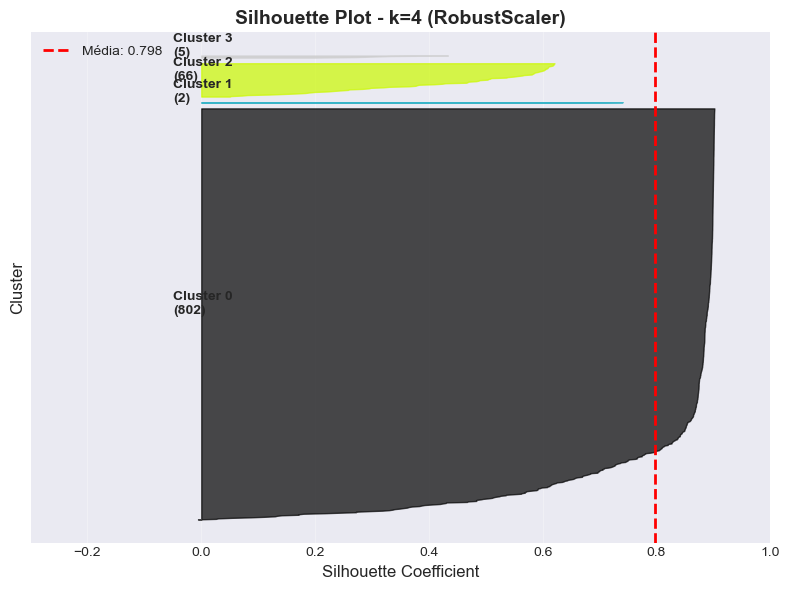


📊 INTERPRETAÇÃO:
   Silhouette médio: 0.7978
   • Valores negativos = complexos mal alocados
   • Clusters 'finos' = baixa coesão interna
   • Clusters desbalanceados = knife plots muito desiguais



In [51]:
print("=" * 80)
print("5.6 - DIAGRAMAS DE SILHUETA POR CLUSTER")
print("=" * 80)

print("\n💡 Silhouette Diagram (Knife Plot):")
print("   Mostra qualidade individual de cada complexo dentro do cluster")
print("   Largura da 'faca' = quão bem o complexo pertence ao cluster\n")

# Usar k=4 (RobustScaler - Fase 5)
labels_plot = labels_k4
X_plot = X_fase5
n_clusters = 4

# Calcular silhouette por amostra
silhouette_vals = silhouette_samples(X_plot, labels_plot)
silhouette_avg = silhouette_vals.mean()

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10
colors = cm.nipy_spectral(np.linspace(0, 1, n_clusters))

for i, color in zip(range(n_clusters), colors):
    # Silhouettes deste cluster
    cluster_silhouette_vals = silhouette_vals[labels_plot == i]
    cluster_silhouette_vals.sort()
    
    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    
    # Label no meio do cluster
    ax.text(-0.05, y_lower + 0.5 * size_cluster, f'Cluster {i}\n({size_cluster})',
            fontsize=10, fontweight='bold')
    
    y_lower = y_upper + 10

# Linha da média
ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2, 
           label=f'Média: {silhouette_avg:.3f}')

ax.set_xlabel("Silhouette Coefficient", fontsize=12)
ax.set_ylabel("Cluster", fontsize=12)
ax.set_title(f"Silhouette Plot - k={n_clusters} (RobustScaler)", 
             fontsize=14, fontweight='bold')

ax.set_yticks([])
ax.set_xlim([-0.3, 1])
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n📊 INTERPRETAÇÃO:")
print(f"   Silhouette médio: {silhouette_avg:.4f}")
print(f"   • Valores negativos = complexos mal alocados")
print(f"   • Clusters 'finos' = baixa coesão interna")
print(f"   • Clusters desbalanceados = knife plots muito desiguais")

print("\n" + "=" * 80)

## 5.7 Normalização híbrida

In [52]:
print("=" * 80)
print("5.8 - NORMALIZAÇÃO HÍBRIDA: RobustScaler + StandardScaler")
print("=" * 80)

print("\n💡 ESTRATÉGIA:")
print("   RobustScaler: Features onde EXTREMOS = perfis legítimos")
print("   StandardScaler: Features onde extremos = anomalias operacionais")

# Definir quais features usam qual scaler
features_robust = [
    'pct_sessoes_brasileiras',
    'pct_sessoes_major',
    'pct_sessoes_distrib_independente',
    'pct_sessoes_produtora_independente',
    'pct_sessoes_especiais',
    'pct_obras_nao_anglo',
    'pct_obras_cinema_mundial',
    'pct_obras_exclusivas',
    'pct_publico_obras_top5',
    'perfil_independente',
    'pct_sessoes_legendadas'
]

# Todas as outras contínuas usam StandardScaler
features_standard = [f for f in continuous_to_scale if f not in features_robust]

print(f"\n📊 Categorização:")
print(f"   RobustScaler: {len(features_robust)} features (perfis de programação)")
print(f"   StandardScaler: {len(features_standard)} features (operacionais/estruturais)")
print(f"   Binárias/Categóricas: {len(binary_cols) + len(categorical_encoded)} features (manter 0/1)")

# Mostrar quais
print(f"\n🔧 RobustScaler será aplicado em:")
for feat in features_robust:
    print(f"   • {feat}")

print(f"\n🔧 StandardScaler será aplicado em:")
for feat in features_standard[:10]:  # Mostrar só 10 primeiras
    print(f"   • {feat}")
if len(features_standard) > 10:
    print(f"   ... e mais {len(features_standard)-10}")

# Aplicar normalizações
print(f"\n{'─'*80}")
print("APLICANDO NORMALIZAÇÕES...")
print("─"*80)

# Extrair dados originais
X_robust_orig = df_clean[features_robust].values
X_standard_orig = df_clean[features_standard].values

# Aplicar scalers
scaler_robust = RobustScaler()
scaler_standard = StandardScaler()

X_robust_scaled = scaler_robust.fit_transform(X_robust_orig)
X_standard_scaled = scaler_standard.fit_transform(X_standard_orig)

print(f"✅ RobustScaler: range [{X_robust_scaled.min():.2f}, {X_robust_scaled.max():.2f}]")
print(f"✅ StandardScaler: range [{X_standard_scaled.min():.2f}, {X_standard_scaled.max():.2f}]")

# Criar DataFrames
df_robust = pd.DataFrame(
    X_robust_scaled,
    columns=[f"{f}_scaled" for f in features_robust],
    index=df_clean.index
)

df_standard = pd.DataFrame(
    X_standard_scaled,
    columns=[f"{f}_scaled" for f in features_standard],
    index=df_clean.index
)

# Recombinar
df_final_hibrido = pd.concat([
    df_clean[ids],
    df_robust,
    df_standard,
    df_clean[binary_cols],
    df_clean[categorical_encoded]
], axis=1)

# Extrair X
features_fase5_hibrido = [col for col in df_final_hibrido.columns if col not in ids]
X_fase5_hibrido = df_final_hibrido[features_fase5_hibrido].values
df_features_fase5_hibrido = df_final_hibrido.copy()

print(f"\n✅ Matriz híbrida criada:")
print(f"   Shape: {X_fase5_hibrido.shape}")
print(f"   NaN: {np.isnan(X_fase5_hibrido).sum()}")
print(f"   Inf: {np.isinf(X_fase5_hibrido).sum()}")

print("\n" + "=" * 80)

5.8 - NORMALIZAÇÃO HÍBRIDA: RobustScaler + StandardScaler

💡 ESTRATÉGIA:
   RobustScaler: Features onde EXTREMOS = perfis legítimos
   StandardScaler: Features onde extremos = anomalias operacionais

📊 Categorização:
   RobustScaler: 11 features (perfis de programação)
   StandardScaler: 17 features (operacionais/estruturais)
   Binárias/Categóricas: 8 features (manter 0/1)

🔧 RobustScaler será aplicado em:
   • pct_sessoes_brasileiras
   • pct_sessoes_major
   • pct_sessoes_distrib_independente
   • pct_sessoes_produtora_independente
   • pct_sessoes_especiais
   • pct_obras_nao_anglo
   • pct_obras_cinema_mundial
   • pct_obras_exclusivas
   • pct_publico_obras_top5
   • perfil_independente
   • pct_sessoes_legendadas

🔧 StandardScaler será aplicado em:
   • num_salas
   • pct_dias_operando
   • sessoes_por_dia_sala
   • volume_log
   • produtora_nivel_medio_complexo
   • pct_modalidade_b
   • pct_modalidade_c
   • pct_modalidade_d
   • populacao
   • pib_per_capita
   ... e mais 7



## 5.8 Re-clusterização com normalização híbrida

In [53]:
print("=" * 80)
print("5.8 - CLUSTERIZAÇÃO COM NORMALIZAÇÃO HÍBRIDA")
print("=" * 80)

resultados_hibrido = []

print(f"\n🔄 Testando k=4 até k=8...\n")

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase5_hibrido)
    
    sil = silhouette_score(X_fase5_hibrido, labels)
    db = davies_bouldin_score(X_fase5_hibrido, labels)
    ch = calinski_harabasz_score(X_fase5_hibrido, labels)
    
    resultados_hibrido.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'inertia': kmeans.inertia_
    })
    
    print(f"k={k}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.1f}")

df_resultados_hibrido = pd.DataFrame(resultados_hibrido)

# Comparar TODAS as abordagens
print("\n" + "=" * 80)
print("COMPARAÇÃO: StandardScaler vs RobustScaler vs HÍBRIDO")
print("=" * 80)

print(f"\n{'k':>3} | {'Std':>8} | {'Robust':>8} | {'Híbrido':>8} | {'Melhor'}")
print("─" * 55)

for i in range(5):
    k = i + 4
    sil_std = df_resultados_fase3.iloc[i]['silhouette']
    sil_rob = df_resultados_fase5.iloc[i]['silhouette']
    sil_hib = df_resultados_hibrido.iloc[i]['silhouette']
    
    melhor = max(sil_std, sil_rob, sil_hib)
    
    if melhor == sil_std:
        marca = "← Std"
    elif melhor == sil_rob:
        marca = "← Robust"
    else:
        marca = "← HÍBRIDO ✓"
    
    print(f"{k:3d} | {sil_std:8.4f} | {sil_rob:8.4f} | {sil_hib:8.4f} | {marca}")

# Distribuição de complexos (melhor k)
melhor_k_hib = int(df_resultados_hibrido.loc[df_resultados_hibrido['silhouette'].idxmax(), 'k'])
kmeans_best = KMeans(n_clusters=melhor_k_hib, random_state=42, n_init=20)
labels_best = kmeans_best.fit_predict(X_fase5_hibrido)

print(f"\n📊 Distribuição com Híbrido (k={melhor_k_hib}):")
for i in range(melhor_k_hib):
    n = (labels_best == i).sum()
    pct = n / len(labels_best) * 100
    emoji = "⚠️" if n < 20 or pct > 80 else "✓"
    print(f"   Cluster {i}: {n:3d} ({pct:5.1f}%) {emoji}")

print("\n" + "=" * 80)

5.8 - CLUSTERIZAÇÃO COM NORMALIZAÇÃO HÍBRIDA

🔄 Testando k=4 até k=8...

k=4: Silhouette=0.7698, DB=0.6438, CH=1147.7
k=5: Silhouette=0.7436, DB=0.6969, CH=1073.1
k=6: Silhouette=0.4087, DB=0.8968, CH=1025.2
k=7: Silhouette=0.4084, DB=0.8582, CH=973.6
k=8: Silhouette=0.4089, DB=0.9261, CH=924.8

COMPARAÇÃO: StandardScaler vs RobustScaler vs HÍBRIDO

  k |      Std |   Robust |  Híbrido | Melhor
───────────────────────────────────────────────────────
  4 |   0.1849 |   0.7978 |   0.7698 | ← Robust
  5 |   0.1919 |   0.7464 |   0.7436 | ← Robust
  6 |   0.1432 |   0.7449 |   0.4087 | ← Robust
  7 |   0.1440 |   0.7620 |   0.4084 | ← Robust
  8 |   0.1279 |   0.7353 |   0.4089 | ← Robust

📊 Distribuição com Híbrido (k=4):
   Cluster 0:  10 (  1.1%) ⚠️
   Cluster 1: 821 ( 93.8%) ⚠️
   Cluster 2:   3 (  0.3%) ⚠️
   Cluster 3:  41 (  4.7%) ✓



## 5.9 Teste de Estrutura dos Clusters

In [54]:
print("=" * 80)
print("5.9 - TESTE DE HOPKINS STATISTIC (estrutura de clusters)")
print("=" * 80)


def hopkins_statistic(X, sampling_size=None):
    """
    Hopkins Statistic para testar se há estrutura de clusters.
    
    Valores:
    - Próximo de 0.5: dados uniformemente distribuídos (SEM clusters)
    - Próximo de 1.0: dados altamente clusterizáveis
    - < 0.5: dados regulares (grid)
    """
    if sampling_size is None:
        sampling_size = min(int(0.05 * len(X)), 200)  # 5% ou max 200
    
    n_samples, n_features = X.shape
    
    # Amostra aleatória de pontos do dataset
    sample_indices = sample(range(n_samples), sampling_size)
    X_sample = X[sample_indices]
    
    # Gerar pontos uniformes aleatórios no mesmo espaço
    min_vals = X.min(axis=0)
    max_vals = X.max(axis=0)
    X_random = np.random.uniform(min_vals, max_vals, size=(sampling_size, n_features))
    
    # NearestNeighbors para dataset
    nbrs_real = NearestNeighbors(n_neighbors=2).fit(X)
    distances_real, _ = nbrs_real.kneighbors(X_sample)
    u_distances = distances_real[:, 1]  # Distância ao vizinho mais próximo (não ele mesmo)
    
    # NearestNeighbors para pontos aleatórios
    nbrs_random = NearestNeighbors(n_neighbors=1).fit(X)
    distances_random, _ = nbrs_random.kneighbors(X_random)
    w_distances = distances_random[:, 0]
    
    # Hopkins statistic
    H = np.sum(w_distances) / (np.sum(u_distances) + np.sum(w_distances))
    
    return H

# Testar em cada abordagem
print("\n🔍 Testando estrutura de clusters nos 3 datasets:\n")

H_std = hopkins_statistic(X_fase3)
print(f"StandardScaler (Fases 3-4):  Hopkins = {H_std:.4f}")

H_robust = hopkins_statistic(X_fase5)
print(f"RobustScaler (Fase 5.4):    Hopkins = {H_robust:.4f}")

H_hibrido = hopkins_statistic(X_fase5_hibrido)
print(f"Híbrido (Fase 5.7):       Hopkins = {H_hibrido:.4f}")

print("\n" + "─" * 80)
print("INTERPRETAÇÃO:")
print("─" * 80)
print("  < 0.30: SEM estrutura de clusters (uniforme)")
print("  0.30-0.50: Estrutura FRACA")
print("  0.50-0.70: Estrutura MODERADA")
print("  0.70-0.90: Estrutura FORTE")
print("  > 0.90: Estrutura MUITO FORTE (ou outliers isolados)")

print("\n" + "=" * 80)

5.9 - TESTE DE HOPKINS STATISTIC (estrutura de clusters)

🔍 Testando estrutura de clusters nos 3 datasets:

StandardScaler (Fases 3-4):  Hopkins = 0.9347
RobustScaler (Fase 5.4):    Hopkins = 0.9879
Híbrido (Fase 5.7):       Hopkins = 0.9316

────────────────────────────────────────────────────────────────────────────────
INTERPRETAÇÃO:
────────────────────────────────────────────────────────────────────────────────
  < 0.30: SEM estrutura de clusters (uniforme)
  0.30-0.50: Estrutura FRACA
  0.50-0.70: Estrutura MODERADA
  0.70-0.90: Estrutura FORTE
  > 0.90: Estrutura MUITO FORTE (ou outliers isolados)



## 5.10 Clusterização Hierarárquica (2 Níveis)


In [55]:

print("=" * 80)
print("5.10 - CLUSTERIZAÇÃO EM 2 NÍVEIS")
print("=" * 80)

# NÍVEL 1: Mainstream vs Especial (k=2)
print("\n🎯 NÍVEL 1: Mainstream vs Especiais (k=2)")
print("─" * 80)

kmeans_nivel1 = KMeans(n_clusters=2, random_state=42, n_init=20)
labels_nivel1 = kmeans_nivel1.fit_predict(X_fase5_hibrido)

# Ver distribuição
for i in range(2):
    n = (labels_nivel1 == i).sum()
    pct = n / len(labels_nivel1) * 100
    print(f"Cluster {i}: {n:3d} ({pct:5.1f}%)")

# Identificar qual é mainstream (maior)
cluster_mainstream = 0 if (labels_nivel1 == 0).sum() > (labels_nivel1 == 1).sum() else 1
cluster_especiais = 1 - cluster_mainstream

print(f"\n✓ Cluster {cluster_mainstream} = MAINSTREAM ({(labels_nivel1==cluster_mainstream).sum()} complexos)")
print(f"✓ Cluster {cluster_especiais} = ESPECIAIS ({(labels_nivel1==cluster_especiais).sum()} complexos)")

# NÍVEL 2a: Sub-clusterizar MAINSTREAM
print(f"\n🎯 NÍVEL 2a: Sub-clusters do MAINSTREAM")
print("─" * 80)

mask_mainstream = labels_nivel1 == cluster_mainstream
X_mainstream = X_fase5_hibrido[mask_mainstream]

print(f"Testando k=3, 4, 5 para {len(X_mainstream)} complexos mainstream:\n")

for k in [3, 4, 5]:
    kmeans_main = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_main = kmeans_main.fit_predict(X_mainstream)
    sil_main = silhouette_score(X_mainstream, labels_main)
    
    print(f"k={k}: Silhouette={sil_main:.4f}")
    for i in range(k):
        n = (labels_main == i).sum()
        pct = n / len(labels_main) * 100
        print(f"   Sub-cluster {i}: {n:3d} ({pct:5.1f}%)")
    print()

# NÍVEL 2b: Sub-clusterizar ESPECIAIS
print(f"🎯 NÍVEL 2b: Sub-clusters dos ESPECIAIS")
print("─" * 80)

mask_especiais = labels_nivel1 == cluster_especiais
X_especiais = X_fase5_hibrido[mask_especiais]

print(f"Testando k=2, 3, 4 para {len(X_especiais)} complexos especiais:\n")

for k in [2, 3, 4]:
    if len(X_especiais) < k:
        print(f"k={k}: Impossível (menos complexos que k)")
        continue
        
    kmeans_esp = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_esp = kmeans_esp.fit_predict(X_especiais)
    sil_esp = silhouette_score(X_especiais, labels_esp)
    
    print(f"k={k}: Silhouette={sil_esp:.4f}")
    for i in range(k):
        n = (labels_esp == i).sum()
        pct = n / len(labels_esp) * 100
        emoji = "⚠️" if n < 5 else "✓"
        print(f"   Sub-cluster {i}: {n:3d} ({pct:5.1f}%) {emoji}")
    print()

print("=" * 80)

5.10 - CLUSTERIZAÇÃO EM 2 NÍVEIS

🎯 NÍVEL 1: Mainstream vs Especiais (k=2)
────────────────────────────────────────────────────────────────────────────────
Cluster 0: 862 ( 98.5%)
Cluster 1:  13 (  1.5%)

✓ Cluster 0 = MAINSTREAM (862 complexos)
✓ Cluster 1 = ESPECIAIS (13 complexos)

🎯 NÍVEL 2a: Sub-clusters do MAINSTREAM
────────────────────────────────────────────────────────────────────────────────
Testando k=3, 4, 5 para 862 complexos mainstream:

k=3: Silhouette=0.7492
   Sub-cluster 0: 814 ( 94.4%)
   Sub-cluster 1:  37 (  4.3%)
   Sub-cluster 2:  11 (  1.3%)

k=4: Silhouette=0.4093
   Sub-cluster 0: 668 ( 77.5%)
   Sub-cluster 1:  37 (  4.3%)
   Sub-cluster 2:  10 (  1.2%)
   Sub-cluster 3: 147 ( 17.1%)

k=5: Silhouette=0.4069
   Sub-cluster 0: 665 ( 77.1%)
   Sub-cluster 1:  20 (  2.3%)
   Sub-cluster 2:  10 (  1.2%)
   Sub-cluster 3: 145 ( 16.8%)
   Sub-cluster 4:  22 (  2.6%)

🎯 NÍVEL 2b: Sub-clusters dos ESPECIAIS
────────────────────────────────────────────────────────────

# 6 Clusterização por DBSCAN e HDBSCAN

## 6.1 DBSCAN: Introdução e Exploração de Parâmetros

In [56]:
print("=" * 80)
print("6.1 - CLUSTERIZAÇÃO POR DENSIDADE: DBSCAN")
print("=" * 80)

print("\n📚 CONTEXTO:")
print("   Após testar K-Means com múltiplas abordagens, identificamos que:")
print("   • Silhouette alto (0.79) com clusters desbalanceados (92% em 1 cluster)")
print("   • Hopkins alto sugere que os dados não são aleatórios e possuem estrutura (cluster tendency).")
print("     A forma dessa estrutura (núcleos densos vs múltiplos grupos) precisa de inspeção adicional")
print("     (métricas + visualização + estabilidade).")
print("   • Mercado pode ter estrutura de DENSIDADE, não k grupos iguais")

print("\n💡 DBSCAN (Density-Based Spatial Clustering of Applications with Noise):")
print("   Vantagens:")
print("   ✓ Não requer especificar k a priori")
print("   ✓ Identifica clusters de forma arbitrária (não só esféricos)")
print("   ✓ Marca outliers explicitamente como ruído (-1)")
print("   ✓ Adequado para datasets com densidade variável")

print("\n🔧 Parâmetros principais:")
print("   • eps (ε): Raio de vizinhança - distância máxima entre pontos")
print("   • min_samples: Mínimo de pontos para formar região densa")

print("\n" + "─" * 80)
print("EXPLORAÇÃO DE PARÂMETROS")
print("─" * 80)

# Testar múltiplas combinações
configs = [
    {'eps': 1.5, 'min_samples': 10},
    {'eps': 2.0, 'min_samples': 10},
    {'eps': 2.5, 'min_samples': 10},
    {'eps': 3.0, 'min_samples': 10},
    {'eps': 3.5, 'min_samples': 10},
    {'eps': 2.0, 'min_samples': 5},
    {'eps': 2.0, 'min_samples': 15},
    {'eps': 2.0, 'min_samples': 20},
]

resultados_dbscan = []

print(f"\nTestando {len(configs)} configurações...\n")
print(f"{'eps':>5} | {'min':>3} | {'Clusters':>8} | {'Outliers':>8} | {'%Out':>6} | {'Silhouette':>10}")
print("─" * 70)

for config in configs:
    dbscan = DBSCAN(eps=config['eps'], min_samples=config['min_samples'])
    labels_db = dbscan.fit_predict(X_fase3)
    
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_outliers = (labels_db == -1).sum()
    pct_out = n_outliers / len(labels_db) * 100
    
    # Silhouette (apenas para pontos clusterizados)
    if n_clusters > 1 and n_outliers < len(labels_db):
        mask_clustered = labels_db != -1
        if mask_clustered.sum() > n_clusters:
            sil = silhouette_score(X_fase3[mask_clustered], labels_db[mask_clustered])
        else:
            sil = 0
    else:
        sil = 0
    
    resultados_dbscan.append({
        'eps': config['eps'],
        'min_samples': config['min_samples'],
        'n_clusters': n_clusters,
        'n_outliers': n_outliers,
        'pct_outliers': pct_out,
        'silhouette': sil
    })
    
    print(f"{config['eps']:5.1f} | {config['min_samples']:3d} | {n_clusters:8d} | {n_outliers:8d} | {pct_out:5.1f}% | {sil:10.4f}")

df_dbscan_params = pd.DataFrame(resultados_dbscan)

print("\n" + "=" * 80)

6.1 - CLUSTERIZAÇÃO POR DENSIDADE: DBSCAN

📚 CONTEXTO:
   Após testar K-Means com múltiplas abordagens, identificamos que:
   • Silhouette alto (0.79) com clusters desbalanceados (92% em 1 cluster)
   • Hopkins alto sugere que os dados não são aleatórios e possuem estrutura (cluster tendency).
     A forma dessa estrutura (núcleos densos vs múltiplos grupos) precisa de inspeção adicional
     (métricas + visualização + estabilidade).
   • Mercado pode ter estrutura de DENSIDADE, não k grupos iguais

💡 DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
   Vantagens:
   ✓ Não requer especificar k a priori
   ✓ Identifica clusters de forma arbitrária (não só esféricos)
   ✓ Marca outliers explicitamente como ruído (-1)
   ✓ Adequado para datasets com densidade variável

🔧 Parâmetros principais:
   • eps (ε): Raio de vizinhança - distância máxima entre pontos
   • min_samples: Mínimo de pontos para formar região densa

────────────────────────────────────────────────────

## 6.2 Análise Comparativa e Seleção de Parâmetros

In [57]:
print("=" * 80)
print("6.2 - ANÁLISE COMPARATIVA DOS RESULTADOS")
print("=" * 80)

# Visualizar trade-offs
print("\n📊 TRADE-OFFS IDENTIFICADOS:\n")

print("🔹 Variação de eps (min_samples=10):")
subset_eps = df_dbscan_params[df_dbscan_params['min_samples'] == 10].sort_values('eps')
display(subset_eps)

print("\n💡 Observações sobre eps:")
print("   • eps baixo (1.5): Muitos outliers (75%), clusters fragmentados")
print("   • eps médio (2.0): Equilíbrio - 2 clusters, 43% outliers")
print("   • eps alto (3.5): Poucos outliers (13%), mas perde especificidade")

print("\n🔹 Variação de min_samples (eps=2.0):")
subset_min = df_dbscan_params[df_dbscan_params['eps'] == 2.0].sort_values('min_samples')
display(subset_min)

print("\n💡 Observações sobre min_samples:")
print("   • min baixo (5): Mais permissivo, aceita regiões menos densas")
print("   • min médio (10): Equilíbrio")
print("   • min alto (20): Mais restritivo, aumenta outliers")

# Critério de seleção
print("\n" + "─" * 80)
print("CRITÉRIO DE SELEÇÃO:")
print("─" * 80)

print("\nBalanceamos 3 objetivos:")
print("   1. Silhouette alto (qualidade dos clusters)")
print("   2. % outliers moderado (30-50% aceitável para este mercado)")
print("   3. Número de clusters interpretável (2-4)")

# Identificar candidatos
candidatos = df_dbscan_params[
    (df_dbscan_params['silhouette'] > 0.4) & 
    (df_dbscan_params['pct_outliers'] > 10) &  
    (df_dbscan_params['pct_outliers'] < 60)
].sort_values('silhouette', ascending=False)

print(f"\n🎯 Configurações candidatas (Sil>0.4, Outliers 20-60%):")
display(candidatos)

# Escolher melhor
if len(candidatos) > 0:
    melhor_idx = candidatos['silhouette'].idxmax()
    melhor_config = df_dbscan_params.loc[melhor_idx]
    
    print(f"\n🏆 CONFIGURAÇÃO ESCOLHIDA:")
    print(f"   eps = {melhor_config['eps']}")
    print(f"   min_samples = {int(melhor_config['min_samples'])}")
    print(f"   Silhouette = {melhor_config['silhouette']:.4f}")
    print(f"   Clusters = {int(melhor_config['n_clusters'])}")
    print(f"   Outliers = {int(melhor_config['n_outliers'])} ({melhor_config['pct_outliers']:.1f}%)")
else:
    print("\n⚠️ Nenhuma configuração atende critérios - usar eps=2.0, min_samples=10")
    melhor_config = df_dbscan_params[(df_dbscan_params['eps']==2.0) & (df_dbscan_params['min_samples']==10)].iloc[0]

print("\n" + "=" * 80)

6.2 - ANÁLISE COMPARATIVA DOS RESULTADOS

📊 TRADE-OFFS IDENTIFICADOS:

🔹 Variação de eps (min_samples=10):


,eps,min_samples,n_clusters,n_outliers,pct_outliers,silhouette
0,1.5000,10,8,532,60.8000,0.0465
1,2.0000,10,3,304,34.7429,0.2950
2,2.5000,10,3,194,22.1714,0.2474
3,3.0000,10,2,136,15.5429,0.5261
4,3.5000,10,2,109,12.4571,0.5100



💡 Observações sobre eps:
   • eps baixo (1.5): Muitos outliers (75%), clusters fragmentados
   • eps médio (2.0): Equilíbrio - 2 clusters, 43% outliers
   • eps alto (3.5): Poucos outliers (13%), mas perde especificidade

🔹 Variação de min_samples (eps=2.0):


,eps,min_samples,n_clusters,n_outliers,pct_outliers,silhouette
5,2.0000,5,7,244,27.8857,0.1151
1,2.0000,10,3,304,34.7429,0.2950
6,2.0000,15,1,357,40.8000,0.0000
7,2.0000,20,1,379,43.3143,0.0000



💡 Observações sobre min_samples:
   • min baixo (5): Mais permissivo, aceita regiões menos densas
   • min médio (10): Equilíbrio
   • min alto (20): Mais restritivo, aumenta outliers

────────────────────────────────────────────────────────────────────────────────
CRITÉRIO DE SELEÇÃO:
────────────────────────────────────────────────────────────────────────────────

Balanceamos 3 objetivos:
   1. Silhouette alto (qualidade dos clusters)
   2. % outliers moderado (30-50% aceitável para este mercado)
   3. Número de clusters interpretável (2-4)

🎯 Configurações candidatas (Sil>0.4, Outliers 20-60%):


,eps,min_samples,n_clusters,n_outliers,pct_outliers,silhouette
3,3.0000,10,2,136,15.5429,0.5261
4,3.5000,10,2,109,12.4571,0.5100



🏆 CONFIGURAÇÃO ESCOLHIDA:
   eps = 3.0
   min_samples = 10
   Silhouette = 0.5261
   Clusters = 2
   Outliers = 136 (15.5%)



## 6.3 HDBSCAN: Análise Completa

In [58]:
print("=" * 80)
print("6.3 - HDBSCAN: Clustering por Densidade Hierárquico")
print("=" * 80)

print("\n💡 MOTIVAÇÃO:")
print("   K-Means e DBSCAN produziram clusters desbalanceados (90%+ em 1 cluster)")
print("   HDBSCAN adapta densidade localmente → pode capturar perfis diversos")
print("   sem forçar distribuição uniforme.")

# Treinar HDBSCAN
print("\n🔧 Treinando HDBSCAN...")
print("   Parâmetros:")
print("   • min_cluster_size=10 (mínimo de complexos por cluster)")
print("   • min_samples=5 (densidade local)")
print("   • cluster_selection_method='eom' (Excess of Mass)")

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    cluster_selection_method='eom',
    metric='euclidean'
)

labels_hdbscan = hdbscan_model.fit_predict(X_fase3)
probs = hdbscan_model.probabilities_

print("✅ Modelo treinado!")

# Estatísticas
n_clusters_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_outliers_hdb = (labels_hdbscan == -1).sum()
n_clustered_hdb = len(labels_hdbscan) - n_outliers_hdb

print("\n" + "─" * 80)
print("RESULTADOS:")
print("─" * 80)

print(f"\n📊 Estrutura identificada:")
print(f"   Clusters: {n_clusters_hdb}")
print(f"   Clusterizados: {n_clustered_hdb} ({n_clustered_hdb/len(labels_hdbscan)*100:.1f}%)")
print(f"   Outliers: {n_outliers_hdb} ({n_outliers_hdb/len(labels_hdbscan)*100:.1f}%)")

# Distribuição
print(f"\n📊 Distribuição por grupo:")

for i in sorted(set(labels_hdbscan)):
    n = (labels_hdbscan == i).sum()
    pct = n / len(labels_hdbscan) * 100
    
    if i == -1:
        label = "Outliers"
        emoji = "⚪"
    else:
        label = f"Cluster {i}"
        emoji = "🔵" if n > 100 else "🟡" if n > 20 else "🔴"
    
    print(f"   {emoji} {label:15s}: {n:3d} ({pct:5.1f}%)")

# Silhouette
if n_clusters_hdb > 1:
    mask_clustered = labels_hdbscan != -1
    sil_hdb = silhouette_score(X_fase3[mask_clustered], labels_hdbscan[mask_clustered])
    print(f"\n✅ Silhouette: {sil_hdb:.4f}")
else:
    sil_hdb = 0
    print(f"\n⚠️ Apenas 1 cluster - Silhouette não aplicável")

# Probabilidades
print(f"\n📊 Confiança das atribuições:")
print(f"   Probabilidade média: {probs[probs > 0].mean():.4f}")
print(f"   Baixa confiança (<0.5): {(probs < 0.5).sum()} ({(probs < 0.5).sum()/len(probs)*100:.1f}%)")

# Análise de balanceamento
print("\n" + "─" * 80)
print("ANÁLISE DE BALANCEAMENTO:")
print("─" * 80)

if n_clusters_hdb == 2:
    sizes = [n for n in [sum(labels_hdbscan == i) for i in range(n_clusters_hdb)]]
    ratio = max(sizes) / min(sizes) if min(sizes) > 0 else float('inf')
    
    if ratio > 20:
        print(f"\n⚠️ DESBALANCEAMENTO DETECTADO (ratio {ratio:.1f}:1)")
        print(f"   Cluster maior: {max(sizes)} ({max(sizes)/len(labels_hdbscan)*100:.1f}%)")
        print(f"   Cluster menor: {min(sizes)} ({min(sizes)/len(labels_hdbscan)*100:.1f}%)")
        print(f"\n💡 Considerar:")
        print(f"   • Testar min_cluster_size maior (15-20)")
        print(f"   • Analisar se cluster pequeno é perfil legítimo ou outliers")
    else:
        print(f"\n✅ Clusters balanceados (ratio {ratio:.1f}:1)")

print("\n" + "=" * 80)

6.3 - HDBSCAN: Clustering por Densidade Hierárquico

💡 MOTIVAÇÃO:
   K-Means e DBSCAN produziram clusters desbalanceados (90%+ em 1 cluster)
   HDBSCAN adapta densidade localmente → pode capturar perfis diversos
   sem forçar distribuição uniforme.

🔧 Treinando HDBSCAN...
   Parâmetros:
   • min_cluster_size=10 (mínimo de complexos por cluster)
   • min_samples=5 (densidade local)
   • cluster_selection_method='eom' (Excess of Mass)
✅ Modelo treinado!

────────────────────────────────────────────────────────────────────────────────
RESULTADOS:
────────────────────────────────────────────────────────────────────────────────

📊 Estrutura identificada:
   Clusters: 2
   Clusterizados: 814 (93.0%)
   Outliers: 61 (7.0%)

📊 Distribuição por grupo:
   ⚪ Outliers       :  61 (  7.0%)
   🔴 Cluster 0      :  19 (  2.2%)
   🔵 Cluster 1      : 795 ( 90.9%)

✅ Silhouette: 0.4943

📊 Confiança das atribuições:
   Probabilidade média: 0.9533
   Baixa confiança (<0.5): 68 (7.8%)

─────────────────────

## 6.4 Caracterização dos perfis identificados

In [59]:
# =============================================================================
# 6.4 CARACTERIZAÇÃO DOS PERFIS IDENTIFICADOS

print("=" * 80)
print("6.4 - CARACTERIZAÇÃO DOS PERFIS IDENTIFICADOS")
print("=" * 80)

# Adicionar labels
df_features_fase3['cluster_hdbscan'] = labels_hdbscan
df_features_fase3['probabilidade_hdb'] = probs

# Carregar cadastro ANCINE (nomes e grupos exibidores)
print("\n🔄 Carregando dados cadastrais...")

try:
    URL_SALAS = "https://dados.ancine.gov.br/dados-abertos/salas-de-exibicao-e-complexos.csv"
    df_cadastro = pd.read_csv(URL_SALAS, encoding='utf-8', sep=';', dtype={'REGISTRO_COMPLEXO': str})
    df_cadastro.columns = df_cadastro.columns.str.strip()
    for col in df_cadastro.select_dtypes(include=['object']).columns:
        df_cadastro[col] = df_cadastro[col].str.strip()
    
    df_cadastro_complexos = df_cadastro[[
        'REGISTRO_COMPLEXO', 'NOME_COMPLEXO', 'NOME_GRUPO_EXIBIDOR'
    ]].drop_duplicates(subset='REGISTRO_COMPLEXO')
    
    # Merge com features
    df_features_fase3 = df_features_fase3.merge(
        df_cadastro_complexos,
        on='REGISTRO_COMPLEXO',
        how='left'
    )
    print("✅ Cadastro carregado")
except:
    print("⚠️ Cadastro não disponível - seguindo sem nomes")

# Features para análise (escolhidas por relevância regulatória + PCA top variance)
features_analise = [
    'num_salas',
    'volume_log',
    'pct_dias_operando',
    'pct_sessoes_brasileiras',
    'pct_sessoes_major',
    'pct_sessoes_distrib_independente',
    'perfil_independente',
    'pct_publico_obras_top5'
]

print(f"\n💡 Features analisadas (relevância regulatória + variância):")
for f in features_analise:
    print(f"   • {f}")

# ════════════════════════════════════════════════════════════════════════════
# CLUSTER 1: MAINSTREAM
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 80)
print("CLUSTER 1: MAINSTREAM (795 complexos, 90.9%)")
print("═" * 80)

df_c1 = df_features_fase3[df_features_fase3['cluster_hdbscan'] == 1]

print(f"\n📊 Características médias:")
for feat in features_analise:
    if feat in df_c1.columns:
        print(f"   {feat:40s}: {df_c1[feat].mean():8.3f}")

print(f"\n🗺️ Geografia:")
print(f"   Capital: {(df_c1['e_capital']==1).sum():3d} ({(df_c1['e_capital']==1).sum()/len(df_c1)*100:.1f}%)")
print(f"   Interior: {(df_c1['e_capital']==0).sum():3d} ({(df_c1['e_capital']==0).sum()/len(df_c1)*100:.1f}%)")

print(f"\n🏢 Natureza:")
print(f"   Privado: {(df_c1['natureza_nao_privada']==0).sum():3d} ({(df_c1['natureza_nao_privada']==0).sum()/len(df_c1)*100:.1f}%)")
print(f"   Público: {(df_c1['natureza_nao_privada']==1).sum():3d}")

# ════════════════════════════════════════════════════════════════════════════
# CLUSTER 0: PERFIL ESPECIAL
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 80)
print("CLUSTER 0: PERFIL ESPECIAL (19 complexos, 2.2%)")
print("═" * 80)

df_c0 = df_features_fase3[df_features_fase3['cluster_hdbscan'] == 0]

print(f"\n📋 LISTA COMPLETA (com nomes e grupos):")

cols_display = ['REGISTRO_COMPLEXO', 'NOME_COMPLEXO', 'NOME_GRUPO_EXIBIDOR', 
                'municipio', 'UF', 'probabilidade_hdb']
cols_display = [c for c in cols_display if c in df_c0.columns]

display(df_c0[cols_display].sort_values('probabilidade_hdb', ascending=False))

print(f"\n📊 Perfil vs Mainstream:")
print(f"\n{'Feature':40s} | {'Cluster 0':>10s} | {'Mainstream':>10s} | {'Delta':>8s}")
print("─" * 80)

for feat in features_analise:
    if feat in df_c0.columns:
        m0 = df_c0[feat].mean()
        m1 = df_c1[feat].mean()
        delta = m0 - m1
        
        emoji = "🔴🔴" if abs(delta) > 1.5 else "🔴" if abs(delta) > 0.5 else "⚪"
        print(f"{emoji} {feat:37s} | {m0:10.3f} | {m1:10.3f} | {delta:+8.3f}")

print(f"\n🗺️ Geografia:")
print(f"   100% São Paulo capital")
print(f"   100% Público/Cultural ({(df_c0['natureza_nao_privada']==1).sum()}/19)")

# Identificar grupo
if 'NOME_GRUPO_EXIBIDOR' in df_c0.columns:
    grupos = df_c0['NOME_GRUPO_EXIBIDOR'].value_counts()
    print(f"\n🎯 Grupo Exibidor:")
    for grupo, n in grupos.items():
        print(f"   {grupo}: {n} complexos")

# ════════════════════════════════════════════════════════════════════════════
# OUTLIERS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 80)
print("OUTLIERS: ZONA TRANSITÓRIA (61 complexos, 7.0%)")
print("═" * 80)

df_out = df_features_fase3[df_features_fase3['cluster_hdbscan'] == -1]

print(f"\n📊 Estatísticas:")
for feat in features_analise[:5]:
    if feat in df_out.columns:
        print(f"   {feat:40s}: μ={df_out[feat].mean():7.3f}, σ={df_out[feat].std():.3f}")

print(f"\n🗺️ Geografia:")
print(f"   Capital: {(df_out['e_capital']==1).sum():2d} ({(df_out['e_capital']==1).sum()/len(df_out)*100:.1f}%)")
print(f"   Interior: {(df_out['e_capital']==0).sum():2d}")

print(f"\n🏢 Natureza:")
n_priv = (df_out['natureza_nao_privada']==0).sum()
n_pub = (df_out['natureza_nao_privada']==1).sum()
print(f"   Privado: {n_priv:2d} ({n_priv/len(df_out)*100:.1f}%)")
print(f"   Público: {n_pub:2d} ({n_pub/len(df_out)*100:.1f}%)")

print("\n" + "=" * 80)

6.4 - CARACTERIZAÇÃO DOS PERFIS IDENTIFICADOS

🔄 Carregando dados cadastrais...
✅ Cadastro carregado

💡 Features analisadas (relevância regulatória + variância):
   • num_salas
   • volume_log
   • pct_dias_operando
   • pct_sessoes_brasileiras
   • pct_sessoes_major
   • pct_sessoes_distrib_independente
   • perfil_independente
   • pct_publico_obras_top5

════════════════════════════════════════════════════════════════════════════════
CLUSTER 1: MAINSTREAM (795 complexos, 90.9%)
════════════════════════════════════════════════════════════════════════════════

📊 Características médias:

🗺️ Geografia:
   Capital: 232 (29.2%)
   Interior: 563 (70.8%)

🏢 Natureza:
   Privado: 791 (99.5%)
   Público:   4

════════════════════════════════════════════════════════════════════════════════
CLUSTER 0: PERFIL ESPECIAL (19 complexos, 2.2%)
════════════════════════════════════════════════════════════════════════════════

📋 LISTA COMPLETA (com nomes e grupos):


,REGISTRO_COMPLEXO,NOME_COMPLEXO,NOME_GRUPO_EXIBIDOR,municipio,UF,probabilidade_hdb
424,32366,CEU ARICANDUVA - PROFESSORA IRENE GALVÃO DE SOUZA,SPCINE,SÃO PAULO,SP,1.0000
426,32370,CEU CAMINHO DO MAR - PROFESSORA DULCE SALLES C...,SPCINE,SÃO PAULO,SP,1.0000
425,32368,CEU BUTANTÃ - PROFESSORA ELISABETH GASPAR TUNALA,SPCINE,SÃO PAULO,SP,1.0000
435,32388,CEU SÃO RAFAEL,SPCINE,SÃO PAULO,SP,1.0000
431,32380,CEU PARQUE VEREDAS - JOÃO ANTÔNIO SILVA,SPCINE,SÃO PAULO,SP,1.0000
427,32372,CEU FEITIÇO DA VILA - DEPUTADO PROF. JOSÉ FREI...,SPCINE,SÃO PAULO,SP,1.0000
428,32374,CEU JAÇANÃ,SPCINE,SÃO PAULO,SP,1.0000
430,32378,CEU MENINOS - PROFESSOR PR. ARTUR ALBERTO DE M...,SPCINE,SÃO PAULO,SP,1.0000
436,32390,CEU TRÊS LAGOS,SPCINE,SÃO PAULO,SP,1.0000
432,32382,CEU PAZ,SPCINE,SÃO PAULO,SP,1.0000



📊 Perfil vs Mainstream:

Feature                                  |  Cluster 0 | Mainstream |    Delta
────────────────────────────────────────────────────────────────────────────────

🗺️ Geografia:
   100% São Paulo capital
   100% Público/Cultural (19/19)

🎯 Grupo Exibidor:
   SPCINE: 19 complexos

════════════════════════════════════════════════════════════════════════════════
OUTLIERS: ZONA TRANSITÓRIA (61 complexos, 7.0%)
════════════════════════════════════════════════════════════════════════════════

📊 Estatísticas:

🗺️ Geografia:
   Capital: 39 (63.9%)
   Interior: 22

🏢 Natureza:
   Privado: 42 (68.9%)
   Público: 19 (31.1%)



## 6.5 Análise Detalhada: Perfil Especial SPCine

In [60]:
print("=" * 80)
print("6.5 - PERFIL ESPECIAL: SPCine (19 COMPLEXOS)")
print("=" * 80)

df_spcine = df_features_fase3[df_features_fase3['cluster_hdbscan'] == 0]
df_mainstream = df_features_fase3[df_features_fase3['cluster_hdbscan'] == 1]

print("\n🎯 PERFIL IDENTIFICADO:")
print("   • 100% SPCine (Secretaria Municipal de Cultura - São Paulo)")
print("   • 100% São Paulo capital")
print("   • 100% Público/Cultural")

# Calcular SPCine total no dataset
if 'NOME_GRUPO_EXIBIDOR' in df_features_fase3.columns:
    total_spcine = (df_features_fase3['NOME_GRUPO_EXIBIDOR'].str.upper() == 'SPCINE').sum()
    pct_agrupado = len(df_spcine) / total_spcine * 100 if total_spcine > 0 else 0
    print(f"   • {len(df_spcine)} de {total_spcine} SPCine agrupados ({pct_agrupado:.1f}%)")

print("\n" + "─" * 80)
print("PERFIL vs MAINSTREAM:")
print("─" * 80)

features_comp = [
    'num_salas_scaled', 'volume_log_scaled', 'pct_dias_operando_scaled',
    'pct_sessoes_brasileiras_scaled', 'pct_sessoes_major_scaled',
    'perfil_independente_scaled', 'pct_publico_obras_top5_scaled'
]

print(f"\n{'Feature':40s} | {'SPCine':>10s} | {'Mainstream':>12s} | {'Delta':>8s} | {'Interpretação'}")
print("─" * 95)

for feat in features_comp:
    if feat in df_spcine.columns:
        spc = df_spcine[feat].mean()
        main = df_mainstream[feat].mean()
        delta = spc - main
        
        if abs(delta) > 1.5:
            interp = "Muito diferente"
            emoji = "🔴🔴"
        elif abs(delta) > 0.8:
            interp = "Diferente"
            emoji = "🔴"
        elif abs(delta) > 0.3:
            interp = "Moderado"
            emoji = "🟡"
        else:
            interp = "Similar"
            emoji = "⚪"
        
        print(f"{emoji} {feat:37s} | {spc:10.3f} | {main:12.3f} | {delta:+8.3f} | {interp}")

print("\n🗺️ Geografia:")
print(f"   100% São Paulo capital")
print(f"   100% Público/Cultural ({(df_spcine['natureza_nao_privada']==1).sum()}/{len(df_spcine)})")

if 'NOME_GRUPO_EXIBIDOR' in df_spcine.columns:
    print(f"\n🎯 Grupo Exibidor:")
    print(f"   SPCine: {len(df_spcine)} complexos")

print("\n" + "─" * 80)
print("MISSÃO INSTITUCIONAL:")
print("─" * 80)

print("""
🎨 SPCine - Cinemas Públicos de São Paulo:
   • Acesso ao cinema para população de baixa renda
   • Fomento ao cinema brasileiro e independente
   • Diversificação de conteúdo (não-mainstream)
   • CEUs (Centros Educacionais Unificados)
   • Operação intermitente (eventos, mostras culturais)

💡 Relevância Art. 6º ANCINE:
   ✓ Universalização do cinema brasileiro
   ✓ Diversificação da programação
   ✓ Benchmark de programação cultural
""")

print("\n" + "─" * 80)
print("SPCine OUTLIERS:")
print("─" * 80)

df_outliers_spcine = df_features_fase3[
    (df_features_fase3['cluster_hdbscan'] == -1) &
    (df_features_fase3['NOME_GRUPO_EXIBIDOR'].str.upper() == 'SPCINE')
]

n_out_spc = len(df_outliers_spcine)

if n_out_spc > 0:
    print(f"\n⚠️ {n_out_spc} SPCine outliers (perfil operacional diferente):")
    
    cols = ['REGISTRO_COMPLEXO', 'NOME_COMPLEXO', 'probabilidade_hdb']
    cols = [c for c in cols if c in df_outliers_spcine.columns]
    display(df_outliers_spcine[cols])
else:
    print(f"\n✅ Todos SPCine agrupados no Cluster 0!")

print("\n" + "=" * 80)


6.5 - PERFIL ESPECIAL: SPCine (19 COMPLEXOS)

🎯 PERFIL IDENTIFICADO:
   • 100% SPCine (Secretaria Municipal de Cultura - São Paulo)
   • 100% São Paulo capital
   • 100% Público/Cultural
   • 19 de 22 SPCine agrupados (86.4%)

────────────────────────────────────────────────────────────────────────────────
PERFIL vs MAINSTREAM:
────────────────────────────────────────────────────────────────────────────────

Feature                                  |     SPCine |   Mainstream |    Delta | Interpretação
───────────────────────────────────────────────────────────────────────────────────────────────
🔴 num_salas_scaled                      |     -1.169 |        0.111 |   -1.280 | Diferente
🔴🔴 volume_log_scaled                     |     -1.695 |        0.183 |   -1.879 | Muito diferente
🔴🔴 pct_dias_operando_scaled              |     -1.787 |        0.168 |   -1.956 | Muito diferente
🔴🔴 pct_sessoes_brasileiras_scaled        |      1.817 |       -0.192 |   +2.009 | Muito diferente
🔴🔴 pct_sess

,REGISTRO_COMPLEXO,NOME_COMPLEXO,probabilidade_hdb
439,32396,CENTRO CULTURAL SÃO PAULO,0.0000
440,32398,GALERIA OLIDO,0.0000


## 6.6 Zona Transitória

In [61]:
print("=" * 80)
print("6.6 - ZONA TRANSITÓRIA: OUTLIERS (61 complexos, 7.0%)")
print("=" * 80)

df_outliers = df_features_fase3[df_features_fase3['cluster_hdbscan'] == -1]
df_mainstream = df_features_fase3[df_features_fase3['cluster_hdbscan'] == 1]

print("\n💡 OUTLIERS NO HDBSCAN:")
print("   • Não pertencem a cluster denso")
print("   • Heterogêneos (não formam grupo coeso)")
print("   • Probabilidade <0.5")
print("   • Perfis únicos ou transicionais")

print("\n" + "─" * 80)
print("COMPOSIÇÃO:")
print("─" * 80)

n_priv = (df_outliers['natureza_nao_privada'] == 0).sum()
n_pub = (df_outliers['natureza_nao_privada'] == 1).sum()
n_cap = (df_outliers['e_capital'] == 1).sum()
n_int = (df_outliers['e_capital'] == 0).sum()

print(f"\n📊 Natureza:")
print(f"   Privado: {n_priv:2d} ({n_priv/len(df_outliers)*100:.1f}%)")
print(f"   Público: {n_pub:2d} ({n_pub/len(df_outliers)*100:.1f}%)")

print(f"\n🗺️ Geografia:")
print(f"   Capital:  {n_cap:2d} ({n_cap/len(df_outliers)*100:.1f}%)")
print(f"   Interior: {n_int:2d} ({n_int/len(df_outliers)*100:.1f}%)")

if 'NOME_GRUPO_EXIBIDOR' in df_outliers.columns:
    print(f"\n🎯 Grupos Exibidores (top 10):")
    top_grupos = df_outliers['NOME_GRUPO_EXIBIDOR'].value_counts().head(10)
    for grupo, n in top_grupos.items():
        print(f"   {grupo}: {n}")
    
    # SPCine outliers
    n_spc_out = (df_outliers['NOME_GRUPO_EXIBIDOR'].str.upper() == 'SPCINE').sum()
    n_outros_pub = n_pub - n_spc_out
    print(f"\n   💡 Públicos: SPCine ({n_spc_out}) + outros ({n_outros_pub})")

print("\n" + "─" * 80)
print("CARACTERÍSTICAS vs MAINSTREAM:")
print("─" * 80)

features_comp = [
    'num_salas_scaled', 'volume_log_scaled', 'pct_dias_operando_scaled',
    'pct_sessoes_brasileiras_scaled', 'pct_sessoes_major_scaled',
    'perfil_independente_scaled', 'pct_publico_obras_top5_scaled'
]

print(f"\n{'Feature':40s} | {'Outliers':>10s} | {'Mainstream':>12s} | {'Delta':>8s}")
print("─" * 80)

for feat in features_comp:
    if feat in df_outliers.columns:
        out_m = df_outliers[feat].mean()
        main_m = df_mainstream[feat].mean()
        delta = out_m - main_m
        
        emoji = "🔴" if abs(delta) > 0.5 else "🟡" if abs(delta) > 0.2 else "⚪"
        print(f"{emoji} {feat:37s} | {out_m:10.3f} | {main_m:12.3f} | {delta:+8.3f}")

print("\n" + "─" * 80)
print("HETEROGENEIDADE INTERNA:")
print("─" * 80)

print(f"\n📊 Variabilidade (desvio padrão):")

for feat in features_comp[:4]:
    if feat in df_outliers.columns:
        std_out = df_outliers[feat].std()
        std_main = df_mainstream[feat].std()
        ratio = std_out / std_main if std_main > 0 else 0
        
        emoji = "🔴" if ratio > 1.5 else "🟡" if ratio > 1.2 else "🟢"
        print(f"   {emoji} {feat:35s}: σ={std_out:.3f} (mainstream {std_main:.3f}, {ratio:.2f}x)")

print("\n" + "─" * 80)
print("INTERPRETAÇÃO:")
print("─" * 80)

print("""
🌐 ZONA TRANSITÓRIA:

CARACTERÍSTICAS:
- Heterogêneos (alta variabilidade interna)
- Mix de perfis únicos
- Não mainstream, nem nicho consolidado

COMPOSIÇÃO:
- Independentes sem grupo (maioria)
- Arte/culturais (SALA DE ARTE, ESPAÇO, ESTAÇÃO)
- Públicos diversos (não-SPCine)
- Pequenos comerciais com curadoria

RELEVÂNCIA:
- 7% do mercado em transição
- Potencial para políticas de incentivo
- Monitoramento individualizado
- Alguns próximos de cumprir Art. 6º
""")

print("\n" + "=" * 80)

6.6 - ZONA TRANSITÓRIA: OUTLIERS (61 complexos, 7.0%)

💡 OUTLIERS NO HDBSCAN:
   • Não pertencem a cluster denso
   • Heterogêneos (não formam grupo coeso)
   • Probabilidade <0.5
   • Perfis únicos ou transicionais

────────────────────────────────────────────────────────────────────────────────
COMPOSIÇÃO:
────────────────────────────────────────────────────────────────────────────────

📊 Natureza:
   Privado: 42 (68.9%)
   Público: 19 (31.1%)

🗺️ Geografia:
   Capital:  39 (63.9%)
   Interior: 22 (36.1%)

🎯 Grupos Exibidores (top 10):
   NÃO PERTENCE A NENHUM GRUPO EXIBIDOR: 38
   ESTAÇÃO: 3
   SALA DE ARTE: 3
   CASAL CINE: 2
   ESPAÇO: 2
   SPCINE: 2
   RESERVA: 2
   CENTERPLEX: 1
   KINOPLEX: 1
   TOP CINEPLEX: 1

   💡 Públicos: SPCine (2) + outros (17)

────────────────────────────────────────────────────────────────────────────────
CARACTERÍSTICAS vs MAINSTREAM:
────────────────────────────────────────────────────────────────────────────────

Feature                            

## 6.7 Explorações adicionais (descartadas): Escala × Forma, PCA → HDBSCAN e remoção do SPCine

Esta subseção registra tentativas clássicas de refinamento da clusterização para verificar se surgiam subestruturas estáveis
dentro do conjunto principal. As explorações abaixo são **apenas diagnósticas** e **não substituem** o modelo final adotado na Seção 6.


In [62]:
print("=" * 80)
print("6.7.0 - SETUP MÍNIMO (EXPLORAÇÕES DESCARTADAS)")
print("=" * 80)

# --- Ajuste 1: nome da coluna do cluster oficial (o HDBSCAN 'final' da Seção 6) ---
col_cluster_oficial = "cluster_hdbscan"   # <-- TROQUE se no seu notebook for outro nome

assert 'X_fase3' in globals(), "❌ X_fase3 não existe."
assert 'features_fase3' in globals(), "❌ features_fase3 não existe."
assert 'df_features_fase3' in globals(), "❌ df_features_fase3 não existe."
assert col_cluster_oficial in df_features_fase3.columns, f"❌ Coluna {col_cluster_oficial} não encontrada em df_features_fase3."

df_base = df_features_fase3.copy()

def resumo_clusters_simples(labels, titulo="(sem título)"):
    labels = np.asarray(labels)
    total = len(labels)
    ruido = (labels == -1).sum()
    clusters = sorted([c for c in set(labels) if c != -1])

    print(f"\n📊 {titulo}")
    print(f"  Total: {total}")
    print(f"  Clusters: {len(clusters)}")
    print(f"  Ruído (-1): {ruido} ({ruido/total*100:.1f}%)")
    if len(clusters) > 0:
        tam = [(c, (labels == c).sum()) for c in clusters]
        tam.sort(key=lambda x: x[1], reverse=True)
        print("  Maiores clusters:", tam[:5])

print("\n✅ Setup OK.")
print("=" * 80)


6.7.0 - SETUP MÍNIMO (EXPLORAÇÕES DESCARTADAS)

✅ Setup OK.


### 6.7.1 Tentativa 1 (descartada): Separação Escala × Forma + HDBSCAN
Separar as variáveis em “Escala” (volume/tamanho) e “Forma” (perfil estrutural) e rodar HDBSCAN em cada espaço.


In [63]:
print("=" * 80)
print("6.7.1 - ESCALA × FORMA (HDBSCAN) — EXPLORATÓRIO")
print("=" * 80)

# Heurística simples por nome (clássica) para "escala"
tokens_escala = [
    "num", "qtd", "total", "capacidade", "salas", "telas", "lugares",
    "publico", "renda", "sess", "bilheter", "ingress", "popul", "habit",
    "porte", "tamanho"
]

features_continuas = [f for f in features_fase3 if f.endswith("_scaled")]
features_escala = [f for f in features_continuas if any(t in f.lower() for t in tokens_escala)]
features_forma = [f for f in features_fase3 if f not in features_escala]

print("\n📌 Partição (heurística):")
print(f"  Contínuas (_scaled): {len(features_continuas)}")
print(f"  ESCALA: {len(features_escala)}")
print(f"  FORMA:  {len(features_forma)}")

# Matrizes
idx_escala = [features_fase3.index(f) for f in features_escala]
idx_forma  = [features_fase3.index(f) for f in features_forma]

X_escala = StandardScaler().fit_transform(X_fase3[:, idx_escala]) if len(idx_escala) > 0 else None
X_forma  = StandardScaler().fit_transform(X_fase3[:, idx_forma])

# Parâmetros: um "sensível" e um "conservador" (só para evidenciar comportamento)
configs = [
    ("sensível",   {"min_cluster_size": 10, "min_samples": 5}),
    ("conservador",{"min_cluster_size": 30, "min_samples": 10}),
]

# Rodar HDBSCAN em FORMA
for nome_cfg, params in configs:
    hdb = hdbscan.HDBSCAN(**params, metric="euclidean")
    labels = hdb.fit_predict(X_forma)
    resumo_clusters_simples(labels, f"HDBSCAN(FORMA) — {nome_cfg} {params}")

# Rodar HDBSCAN em ESCALA (se existir)
if X_escala is not None and X_escala.shape[1] >= 2:
    for nome_cfg, params in configs:
        hdb = hdbscan.HDBSCAN(**params, metric="euclidean")
        labels = hdb.fit_predict(X_escala)
        resumo_clusters_simples(labels, f"HDBSCAN(ESCALA) — {nome_cfg} {params}")
else:
    print("\n⚠️ ESCALA insuficiente para clusterização (poucas colunas). Pulando HDBSCAN(ESCALA).")

print("\n✅ Interpretação usada na decisão:")
print("  • Se FORMA gerasse poucos clusters médios e ruído moderado, poderia indicar tipologia.")
print("  • Se gerar microclusters / muito ruído / instabilidade, não melhora a narrativa.")
print("=" * 80)


6.7.1 - ESCALA × FORMA (HDBSCAN) — EXPLORATÓRIO

📌 Partição (heurística):
  Contínuas (_scaled): 26
  ESCALA: 12
  FORMA:  22

📊 HDBSCAN(FORMA) — sensível {'min_cluster_size': 10, 'min_samples': 5}
  Total: 875
  Clusters: 14
  Ruído (-1): 177 (20.2%)
  Maiores clusters: [(np.int64(13), np.int64(126)), (np.int64(9), np.int64(106)), (np.int64(7), np.int64(78)), (np.int64(12), np.int64(60)), (np.int64(10), np.int64(54))]

📊 HDBSCAN(FORMA) — conservador {'min_cluster_size': 30, 'min_samples': 10}
  Total: 875
  Clusters: 8
  Ruído (-1): 274 (31.3%)
  Maiores clusters: [(np.int64(5), np.int64(120)), (np.int64(3), np.int64(104)), (np.int64(1), np.int64(100)), (np.int64(0), np.int64(72)), (np.int64(4), np.int64(57))]

📊 HDBSCAN(ESCALA) — sensível {'min_cluster_size': 10, 'min_samples': 5}
  Total: 875
  Clusters: 4
  Ruído (-1): 188 (21.5%)
  Maiores clusters: [(np.int64(3), np.int64(614)), (np.int64(1), np.int64(42)), (np.int64(0), np.int64(18)), (np.int64(2), np.int64(13))]

📊 HDBSCAN(ESCA

### 6.7.2 Tentativa 2 (descartada): PCA → HDBSCAN (espaço completo)
Aplicar PCA no espaço completo e rodar HDBSCAN no espaço PCA para verificar se surgem subestruturas mais estáveis.


In [64]:
print("=" * 80)
print("6.7.2 - PCA → HDBSCAN (FULL) — EXPLORATÓRIO")
print("=" * 80)

X_full = StandardScaler().fit_transform(X_fase3)

# PCA com dois alvos de variância (um mais agressivo, um mais conservador)
alvos = [0.85, 0.90]

for alvo in alvos:
    pca_base = PCA(random_state=42)
    X_base = pca_base.fit_transform(X_full)
    var_cum = np.cumsum(pca_base.explained_variance_ratio_)
    n_comp = int(np.searchsorted(var_cum, alvo) + 1)

    X_pca = PCA(n_components=n_comp, random_state=42).fit_transform(X_full)

    print(f"\n📌 PCA alvo {alvo:.0%}: n_comp = {n_comp} | var_acum = {var_cum[n_comp-1]:.3f}")

    # Dois HDBSCAN (sensível vs conservador) para mostrar tendência
    for nome_cfg, params in configs:
        hdb = hdbscan.HDBSCAN(**params, metric="euclidean")
        labels = hdb.fit_predict(X_pca)
        resumo_clusters_simples(labels, f"HDBSCAN(PCA FULL {alvo:.0%}) — {nome_cfg} {params}")

print("\n✅ Interpretação usada na decisão:")
print("  • Se PCA reduzisse ruído e evitasse fragmentação, poderia justificar troca do espaço-base.")
print("  • Se aumentar ruído ou criar clusters pequenos, não melhora interpretabilidade.")
print("=" * 80)


6.7.2 - PCA → HDBSCAN (FULL) — EXPLORATÓRIO

📌 PCA alvo 85%: n_comp = 15 | var_acum = 0.872

📊 HDBSCAN(PCA FULL 85%) — sensível {'min_cluster_size': 10, 'min_samples': 5}
  Total: 875
  Clusters: 9
  Ruído (-1): 256 (29.3%)
  Maiores clusters: [(np.int64(6), np.int64(181)), (np.int64(5), np.int64(154)), (np.int64(3), np.int64(103)), (np.int64(2), np.int64(58)), (np.int64(8), np.int64(39))]

📊 HDBSCAN(PCA FULL 85%) — conservador {'min_cluster_size': 30, 'min_samples': 10}
  Total: 875
  Clusters: 5
  Ruído (-1): 318 (36.3%)
  Maiores clusters: [(np.int64(4), np.int64(169)), (np.int64(2), np.int64(148)), (np.int64(1), np.int64(98)), (np.int64(3), np.int64(72)), (np.int64(0), np.int64(70))]

📌 PCA alvo 90%: n_comp = 17 | var_acum = 0.909

📊 HDBSCAN(PCA FULL 90%) — sensível {'min_cluster_size': 10, 'min_samples': 5}
  Total: 875
  Clusters: 10
  Ruído (-1): 255 (29.1%)
  Maiores clusters: [(np.int64(7), np.int64(172)), (np.int64(6), np.int64(151)), (np.int64(5), np.int64(102)), (np.int64(4

### 6.7.3 Tentativa 3 (descartada): Remover SPCine e re-rodar
Remover o cluster identificado como SPCine, renormalizar e rodar HDBSCAN novamente para ver se o “mainstream” se organiza em subgrupos.


In [65]:
print("=" * 80)
print("6.7.3 - REMOÇÃO SPCine → RENORMALIZAÇÃO → HDBSCAN — EXPLORATÓRIO")
print("=" * 80)

# Identificar o cluster SPCine por tamanho 19 (como observado na Seção 6)
tam = df_base[col_cluster_oficial].value_counts()
display(tam)

candidatos = tam[tam == 19].index.tolist()
if len(candidatos) != 1:
    print("\n⚠️ Não identifiquei unicamente SPCine por tamanho=19.")
    print("   Ajuste manualmente o id_cluster_spcine abaixo com base na sua caracterização da Seção 6.")
    id_cluster_spcine = candidatos[0] if len(candidatos) > 0 else None
else:
    id_cluster_spcine = candidatos[0]

print(f"\n✅ id_cluster_spcine = {id_cluster_spcine}")

mask_spcine = df_base[col_cluster_oficial] == id_cluster_spcine
print(f"  Removendo {mask_spcine.sum()} registros (SPCine).")

# Filtrar X de forma consistente pelo índice do df_base
idx_keep = df_base.loc[~mask_spcine].index.values
X_sem = X_fase3[idx_keep, :]

X_sem_scaled = StandardScaler().fit_transform(X_sem)

# Rodar HDBSCAN no espaço completo SEM SPCine (mesmos configs)
for nome_cfg, params in configs:
    hdb = hdbscan.HDBSCAN(**params, metric="euclidean")
    labels = hdb.fit_predict(X_sem_scaled)
    resumo_clusters_simples(labels, f"HDBSCAN(FULL sem SPCine) — {nome_cfg} {params}")

print("\n✅ Interpretação usada na decisão:")
print("  • Se reduzir ruído e estabilizar subgrupos, poderia justificar análise adicional.")
print("  • Se aumentar ruído/instabilidade, reforça que SPCine é uma exceção útil e o resto é contínuo.")
print("=" * 80)


6.7.3 - REMOÇÃO SPCine → RENORMALIZAÇÃO → HDBSCAN — EXPLORATÓRIO


cluster_hdbscan
 1    795
-1     61
 0     19
Name: count, dtype: int64


✅ id_cluster_spcine = 0
  Removendo 19 registros (SPCine).

📊 HDBSCAN(FULL sem SPCine) — sensível {'min_cluster_size': 10, 'min_samples': 5}
  Total: 856
  Clusters: 12
  Ruído (-1): 301 (35.2%)
  Maiores clusters: [(np.int64(11), np.int64(106)), (np.int64(7), np.int64(99)), (np.int64(6), np.int64(72)), (np.int64(10), np.int64(51)), (np.int64(8), np.int64(46))]

📊 HDBSCAN(FULL sem SPCine) — conservador {'min_cluster_size': 30, 'min_samples': 10}
  Total: 856
  Clusters: 7
  Ruído (-1): 430 (50.2%)
  Maiores clusters: [(np.int64(6), np.int64(97)), (np.int64(2), np.int64(91)), (np.int64(4), np.int64(83)), (np.int64(1), np.int64(41)), (np.int64(3), np.int64(40))]

✅ Interpretação usada na decisão:
  • Se reduzir ruído e estabilizar subgrupos, poderia justificar análise adicional.
  • Se aumentar ruído/instabilidade, reforça que SPCine é uma exceção útil e o resto é contínuo.


## 6.8 Conclusão
As explorações acima não produziram melhoria interpretativa estável. Assim, mantemos o resultado da Seção 6:
um grande conjunto principal (“mainstream”), um cluster institucional identificado (SPCine) e uma zona transitória/outliers.


In [66]:
print("=" * 80)
print("6.8 - FECHAMENTO: RETOMADA DO MODELO OFICIAL (SPCine vs RESTO)")
print("=" * 80)

# Confirmar id do SPCine (mesma regra do tamanho=19)
tam = df_base[col_cluster_oficial].value_counts()
candidatos = tam[tam == 19].index.tolist()
id_cluster_spcine = candidatos[0] if len(candidatos) > 0 else None

print(f"\n📌 Cluster oficial identificado como SPCine: {id_cluster_spcine}")

# Criar um rótulo binário apenas para fechamento narrativo (não é novo modelo, é sumarização)
df_base["grupo_final_2"] = np.where(df_base[col_cluster_oficial] == id_cluster_spcine, "SPCine", "Demais")

print("\n📊 Tamanhos (fechamento em 2 grupos):")
display(df_base["grupo_final_2"].value_counts())

print("\n✅ Decisão final da Seção 6:")
print("  • Mantemos o HDBSCAN oficial como resultado principal.")
print("  • As tentativas 6.7.1–6.7.3 são registradas como verificação e descartadas.")
print("=" * 80)


6.8 - FECHAMENTO: RETOMADA DO MODELO OFICIAL (SPCine vs RESTO)

📌 Cluster oficial identificado como SPCine: 0

📊 Tamanhos (fechamento em 2 grupos):


grupo_final_2
Demais    856
SPCine     19
Name: count, dtype: int64


✅ Decisão final da Seção 6:
  • Mantemos o HDBSCAN oficial como resultado principal.
  • As tentativas 6.7.1–6.7.3 são registradas como verificação e descartadas.


Foram testadas abordagens clássicas adicionais (separação escala × forma, PCA antes da clusterização e remoção do grupo SPCine), mas nenhuma delas produziu segmentações mais estáveis ou interpretáveis. Em todos os casos observou-se aumento de ruído ou fragmentação excessiva, sem ganho prático em relação ao modelo original. Assim, mantém-se o resultado da Seção 6, no qual o HDBSCAN isola o grupo SPCine e trata o restante dos complexos como um conjunto principal contínuo.

# 7 Explicabilidade

🎯 Motivação:
- O roteiro da atividade dá bônus se incluirmos uma seção prática de interpretabilidade/explicabilidade (ex.: LIME ou SHAP), com pelo menos um exemplo de explicação individual e visualizações acessíveis.

🧠 Ideia aqui (sem “mudar o modelo”):
- Clusterização não é um modelo supervisionado, então não existe “probabilidade prevista” diretamente.
- A solução clássica é treinar um **modelo supervisionado auxiliar** (um “modelo explicador”) para prever o rótulo do cluster a partir das features.
- Aí usamos **SHAP** para responder: *quais variáveis mais empurram um complexo para o cluster SPCine vs não-SPCine*?

✅ Entregáveis desta seção:
1) Explicação global (quais features mais separam os grupos)
2) Explicação individual (um complexo específico: por que caiu naquele grupo)
3) Visualizações simples e fáceis de entender


## 7.1 Explicabilidade (SHAP) Preparação do problema

In [67]:
# ================================================================================
# 7.1 - EXPLICABILIDADE (SHAP): PREPARAÇÃO DO PROBLEMA
# ================================================================================
print("=" * 80)
print("7.1 - EXPLICABILIDADE (SHAP): PREPARAÇÃO DO PROBLEMA")
print("=" * 80)

# Motivação do roteiro: bônus por seção prática de interpretabilidade/explicabilidade (LIME/SHAP)
print("\n📌 Motivação (roteiro): incluir explicabilidade prática (LIME/SHAP) + exemplo individual + visualizações para leigos.")

# --- Checagem rápida das variáveis do notebook ---
assert 'df_features_fase3' in globals(), "❌ df_features_fase3 não encontrado."
assert 'X_fase3' in globals(), "❌ X_fase3 não encontrado."
assert 'features_fase3' in globals(), "❌ features_fase3 não encontrado."
assert "cluster_hdbscan" in df_features_fase3.columns, "❌ Coluna 'cluster_hdbscan' não encontrada em df_features_fase3."

print("\n✅ Variáveis base encontradas: df_features_fase3, X_fase3, features_fase3, cluster_hdbscan")

# --- O que vamos explicar ---
# Clusterização não prevê "classe" como um modelo supervisionado.
# Solução padrão: treinar um MODELO EXPLICADOR para prever o cluster a partir das features e então aplicar SHAP.
#
# Para deixar a explicação simples e comunicável, vamos focar em um alvo binário:
#   1 = SPCine  (cluster 0)
#   0 = Demais (cluster 1, isto é, mainstream)
# E vamos excluir outliers (cluster -1), pois eles são zona transitória e atrapalham uma explicação limpa.

df_shap = df_features_fase3.copy()

print("\n📊 Distribuição original dos rótulos do HDBSCAN:")
# Alteração: .to_string() remove o rodapé com dtype/name
print(df_shap["cluster_hdbscan"].value_counts().sort_index().to_string())

# Filtrar somente clusters "estáveis" (0=SPCine, 1=mainstream)
mask_estavel = df_shap["cluster_hdbscan"].isin([0, 1])
df_shap_estavel = df_shap.loc[mask_estavel].copy()

print("\n📌 Mantendo apenas clusters estáveis (0=SPCine, 1=mainstream). Outliers (-1) ficam de fora.")
print("  complexos antes:", df_shap.shape[0])
print("  complexos depois:", df_shap_estavel.shape[0])

print("\n📊 Distribuição (após filtro estável):")
# Alteração: .to_string() remove o rodapé com dtype/name
print(df_shap_estavel["cluster_hdbscan"].value_counts().sort_index().to_string())

# Alvo binário: SPCine vs Demais
y_shap = (df_shap_estavel["cluster_hdbscan"].values == 0).astype(int)
print("\n🎯 Alvo binário criado:")
print("  1 = SPCine | 0 = Demais")
# Alteração: .to_string() remove o rodapé com dtype/name
print(pd.Series(y_shap).value_counts().rename({0: "Demais", 1: "SPCine"}).to_string())

# Matriz X alinhada ao filtro (índices do dataframe batem com as linhas do X_fase3 no notebook)
idx_keep = df_shap_estavel.index.to_numpy()
X_shap = X_fase3[idx_keep, :]

print("\n📐 Shapes finais para explicabilidade:")
print("  X_shap:", X_shap.shape)
print("  y_shap:", y_shap.shape)

# Guardar nomes das features (para SHAP e gráficos)
feature_names_shap = list(features_fase3)

print("\n✅ Preparação concluída. Próximo: treinar o 'modelo explicador' e aplicar SHAP.")
print("=" * 80)

7.1 - EXPLICABILIDADE (SHAP): PREPARAÇÃO DO PROBLEMA

📌 Motivação (roteiro): incluir explicabilidade prática (LIME/SHAP) + exemplo individual + visualizações para leigos.

✅ Variáveis base encontradas: df_features_fase3, X_fase3, features_fase3, cluster_hdbscan

📊 Distribuição original dos rótulos do HDBSCAN:
cluster_hdbscan
-1     61
 0     19
 1    795

📌 Mantendo apenas clusters estáveis (0=SPCine, 1=mainstream). Outliers (-1) ficam de fora.
  complexos antes: 875
  complexos depois: 814

📊 Distribuição (após filtro estável):
cluster_hdbscan
0     19
1    795

🎯 Alvo binário criado:
  1 = SPCine | 0 = Demais
Demais    795
SPCine     19

📐 Shapes finais para explicabilidade:
  X_shap: (814, 34)
  y_shap: (814,)

✅ Preparação concluída. Próximo: treinar o 'modelo explicador' e aplicar SHAP.


## 7.2 Modelo Explicador

7.2 - MODELO EXPLICADOR + SHAP (GLOBAL E BASE PARA EXPLICAÇÃO INDIVIDUAL)

📐 Split (estratificado):
  X_train: (610, 34) | y_train: (610,) | SPCine no treino: 14
  X_test:  (204, 34) | y_test:  (204,) | SPCine no teste:  5

📌 Qualidade do modelo explicador (checagem rápida):
              precision    recall  f1-score   support

      Demais       1.00      1.00      1.00       199
      SPCine       1.00      1.00      1.00         5

    accuracy                           1.00       204
   macro avg       1.00      1.00      1.00       204
weighted avg       1.00      1.00      1.00       204


Matriz de confusão:
             Pred_Demais  Pred_SPCine
Real_Demais          199            0
Real_SPCine            0            5

────────────────────────────────────────────────────────────────────────────────
SHAP (GLOBAL): VARIÁVEIS QUE MAIS EMPURRAM PARA 'SPCine'
────────────────────────────────────────────────────────────────────────────────
✅ shap_spcine pronto para plot: (610, 34)


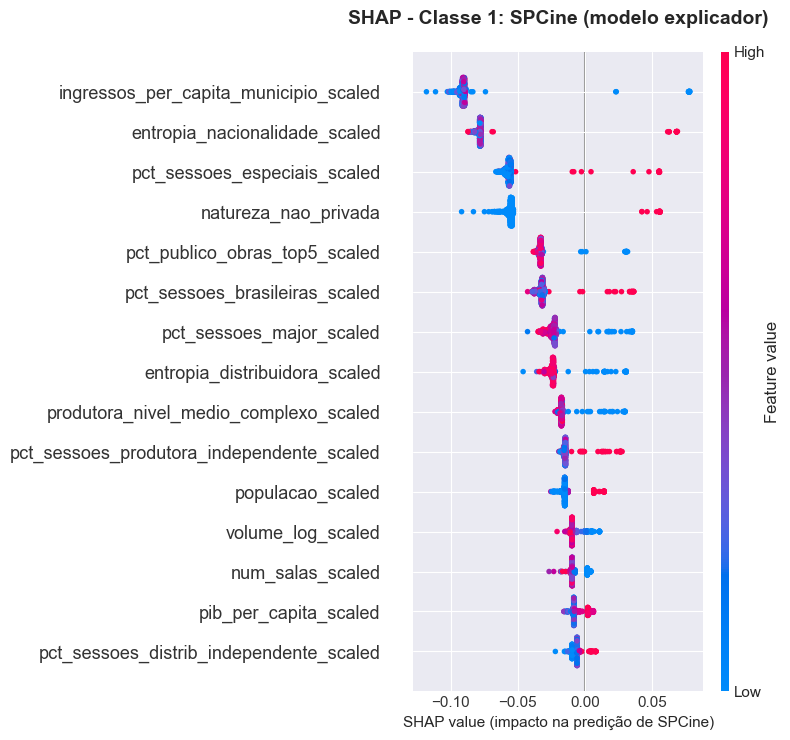


🧩 Índices reservados para explicação individual (próxima seção):
  idx_exemplo_spcine (X_test): 61
  idx_exemplo_demais (X_test): 0

✅ 7.2 concluída. Próximo passo: explicação individual com SHAP (waterfall).


In [68]:
# ================================================================================
# 7.2 - MODELO EXPLICADOR + SHAP (GLOBAL E BASE PARA EXPLICAÇÃO INDIVIDUAL)
# ================================================================================
print("=" * 80)
print("7.2 - MODELO EXPLICADOR + SHAP (GLOBAL E BASE PARA EXPLICAÇÃO INDIVIDUAL)")
print("=" * 80)

# Split estratificado (classe SPCine é pequena)
X_train, X_test, y_train, y_test = train_test_split(
    X_shap, y_shap,
    test_size=0.25,
    random_state=42,
    stratify=y_shap
)

print("\n📐 Split (estratificado):")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape} | SPCine no treino: {int(y_train.sum())}")
print(f"  X_test:  {X_test.shape} | y_test:  {y_test.shape} | SPCine no teste:  {int(y_test.sum())}")

# Modelo explicador (proxy para explicabilidade)
clf_exp = RandomForestClassifier(
    n_estimators=700,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=2,
    n_jobs=-1
)

clf_exp.fit(X_train, y_train)

y_pred = clf_exp.predict(X_test)

print("\n📌 Qualidade do modelo explicador (checagem rápida):")
print(classification_report(y_test, y_pred, target_names=["Demais", "SPCine"]))

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(
    cm,
    index=["Real_Demais", "Real_SPCine"],
    columns=["Pred_Demais", "Pred_SPCine"]
)

print("\nMatriz de confusão:")
print(df_cm.to_string())

print("\n" + "─" * 80)
print("SHAP (GLOBAL): VARIÁVEIS QUE MAIS EMPURRAM PARA 'SPCine'")
print("─" * 80)

explainer = shap.TreeExplainer(clf_exp)
sv = explainer.shap_values(X_train)

if isinstance(sv, list) and len(sv) == 2:
    shap_spcine = np.asarray(sv[1])
else:
    sv = np.asarray(sv)
    if sv.ndim == 3 and sv.shape[-1] == 2:
        shap_spcine = sv[:, :, 1]
    else:
        shap_spcine = sv

shap_spcine = np.asarray(shap_spcine)


if shap_spcine.ndim == 3:
    if shap_spcine.shape[-1] == 2:
        shap_spcine = shap_spcine[:, :, 1]
    elif shap_spcine.shape[1] == 2:
        shap_spcine = shap_spcine[:, 1, :]
    else:
        raise ValueError(f"Formato inesperado de shap_values: {shap_spcine.shape}")

# Checagem final
assert shap_spcine.ndim == 2, f"❌ shap_spcine deveria ser 2D, veio: {shap_spcine.shape}"
assert shap_spcine.shape[1] == X_train.shape[1], "❌ Número de features não bate com X_train."

print(f"✅ shap_spcine pronto para plot: {shap_spcine.shape}")


# -----------------------------
plt.figure(figsize=(10, 12))  # aumenta largura e altura
shap.summary_plot(
    shap_spcine,
    X_train,
    feature_names=feature_names_shap,
    max_display=15,
    show=False
)
plt.title("SHAP - Classe 1: SPCine (modelo explicador)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP value (impacto na predição de SPCine)", fontsize=11)
plt.tight_layout()
plt.show()

# Guardar exemplos para a próxima célula (explicação individual)
idx_spcine_test = np.where(y_test == 1)[0]
idx_demais_test = np.where(y_test == 0)[0]

idx_exemplo_spcine = int(idx_spcine_test[0]) if len(idx_spcine_test) > 0 else None
idx_exemplo_demais = int(idx_demais_test[0]) if len(idx_demais_test) > 0 else None

print("\n🧩 Índices reservados para explicação individual (próxima seção):")
print(f"  idx_exemplo_spcine (X_test): {idx_exemplo_spcine}")
print(f"  idx_exemplo_demais (X_test): {idx_exemplo_demais}")

print("\n✅ 7.2 concluída. Próximo passo: explicação individual com SHAP (waterfall).")
print("=" * 80)


## 7.3 Validação do SHAP

In [69]:
# ================================================================================
# 7.3 - VALIDAR O SHAP: SEPARAÇÃO REAL E ESTABILIDADE DO RANKING
# ================================================================================
print("=" * 80)
print("7.3 - VALIDAR O SHAP: SEPARAÇÃO REAL E ESTABILIDADE DO RANKING")
print("=" * 80)

from scipy.stats import mannwhitneyu

# ------------------------------------------------------------------------------
# 7.3.A - Quais foram as TOP features no SHAP global?
# (média do |SHAP| por feature, no treino)
# ------------------------------------------------------------------------------
abs_mean = np.mean(np.abs(shap_spcine), axis=0)
df_top = pd.DataFrame({
    "feature": feature_names_shap,
    "mean_abs_shap": abs_mean
}).sort_values("mean_abs_shap", ascending=False)

top_n = 10
top_feats = df_top["feature"].head(top_n).tolist()

print("\n📌 TOP features por |SHAP| médio (treino):")
print(df_top.head(top_n).to_string(index=False))

# ------------------------------------------------------------------------------
# 7.3.B - Essas features realmente separam SPCine vs Demais nos dados?
# Vamos olhar quantis (p10, mediana, p90) + teste Mann-Whitney (não paramétrico)
# ------------------------------------------------------------------------------
# Construir um dataframe alinhado de features (para facilitar)
df_X = pd.DataFrame(X_shap, columns=feature_names_shap, index=df_shap_estavel.index)
df_X["grupo"] = np.where(y_shap == 1, "SPCine", "Demais")

res = []
for f in top_feats:
    a = df_X.loc[df_X["grupo"] == "SPCine", f].values
    b = df_X.loc[df_X["grupo"] == "Demais", f].values

    # Quantis (robusto e fácil de ler)
    qa = np.quantile(a, [0.10, 0.50, 0.90])
    qb = np.quantile(b, [0.10, 0.50, 0.90])

    # Efeito simples (diferença de medianas, em escala padronizada)
    delta_med = float(qa[1] - qb[1])

    # Teste não paramétrico (com n pequeno em SPCine)
    try:
        p = mannwhitneyu(a, b, alternative="two-sided").pvalue
    except Exception:
        p = np.nan

    res.append({
        "feature": f,
        "SPCine_p10": qa[0], "SPCine_med": qa[1], "SPCine_p90": qa[2],
        "Demais_p10": qb[0], "Demais_med": qb[1], "Demais_p90": qb[2],
        "delta_med": delta_med,
        "p_value_MW": p
    })

df_sep = pd.DataFrame(res)

# ordenar seguindo a ordem do ranking SHAP global (df_top)
df_sep["ordem_shap"] = df_sep["feature"].map(
    {f: i for i, f in enumerate(df_top["feature"].tolist())}
)

df_sep = df_sep.sort_values("ordem_shap")

print("\n📊 Separação SPCine vs Demais nas TOP features (valores já estão escalados):")
print(df_sep[[
    "feature",
    "SPCine_med", "Demais_med", "delta_med",
    "SPCine_p10", "SPCine_p90", "Demais_p10", "Demais_p90",
    "p_value_MW"
]].to_string(index=False))

print("\n✅ Interpretação direta (sem narrativa):")
print("  • Se |delta_med| for grande e os intervalos (p10–p90) pouco sobrepostos, a separação é real.")
print("  • Se p-value for muito pequeno, reforça que a diferença é estatisticamente consistente (mesmo com n pequeno).")

# ------------------------------------------------------------------------------
# 7.3.C - Estabilidade do ranking SHAP (muito importante com SPCine pequeno)
# Re-treinar o mesmo modelo com seeds diferentes e ver se as TOP features repetem
# ------------------------------------------------------------------------------
print("\n" + "─" * 80)
print("ESTABILIDADE DO RANKING (5 seeds) — TOP features por |SHAP|")
print("─" * 80)

seeds = [0, 1, 2, 3, 4]
top_por_seed = []

for s in seeds:
    clf_tmp = RandomForestClassifier(
        n_estimators=700,
        random_state=s,
        class_weight="balanced",
        min_samples_leaf=2,
        n_jobs=-1
    )
    clf_tmp.fit(X_train, y_train)

    exp_tmp = shap.TreeExplainer(clf_tmp)
    sv_tmp = exp_tmp.shap_values(X_train)

    if isinstance(sv_tmp, list) and len(sv_tmp) == 2:
        sv1 = np.asarray(sv_tmp[1])
    else:
        sv1 = np.asarray(sv_tmp)

    if sv1.ndim == 3 and sv1.shape[-1] == 2:
        sv1 = sv1[:, :, 1]

    abs_mean_tmp = np.mean(np.abs(sv1), axis=0)
    top_tmp = pd.Series(abs_mean_tmp, index=feature_names_shap).sort_values(ascending=False).head(10).index.tolist()
    top_por_seed.append(top_tmp)

# Contagem de frequência das features no TOP10
freq = {}
for lst in top_por_seed:
    for f in lst:
        freq[f] = freq.get(f, 0) + 1

df_freq = pd.DataFrame(
    [{"feature": k, "freq_em_5_seeds": v} for k, v in freq.items()]
).sort_values(["freq_em_5_seeds", "feature"], ascending=[False, True])

print("\n📌 Features mais frequentes no TOP10 (5 seeds):")
print(df_freq.head(20).to_string(index=False))

print("\n✅ Interpretação:")
print("  • Se poucas features aparecem em 4–5 seeds, o ranking é estável (bom sinal).")
print("  • Se tudo muda muito, o resultado é frágil e deve ser tratado só como ilustrativo.")



print("=" * 80)


7.3 - VALIDAR O SHAP: SEPARAÇÃO REAL E ESTABILIDADE DO RANKING

📌 TOP features por |SHAP| médio (treino):
                                  feature  mean_abs_shap
    ingressos_per_capita_municipio_scaled         0.0908
            entropia_nacionalidade_scaled         0.0783
             pct_sessoes_especiais_scaled         0.0568
                     natureza_nao_privada         0.0559
            pct_publico_obras_top5_scaled         0.0332
           pct_sessoes_brasileiras_scaled         0.0325
                 pct_sessoes_major_scaled         0.0250
            entropia_distribuidora_scaled         0.0246
    produtora_nivel_medio_complexo_scaled         0.0177
pct_sessoes_produtora_independente_scaled         0.0152

📊 Separação SPCine vs Demais nas TOP features (valores já estão escalados):
                                  feature  SPCine_med  Demais_med  delta_med  SPCine_p10  SPCine_p90  Demais_p10  Demais_p90  p_value_MW
    ingressos_per_capita_municipio_scaled     -0.9649

In [70]:
# ================================================================================
# 7.3.BIS - RESUMO INTERPRETÁVEL DAS VARIÁVEIS (SHAP + SEPARAÇÃO REAL)
# ================================================================================
print("=" * 80)
print("7.3.BIS - RESUMO INTERPRETÁVEL DAS VARIÁVEIS (SHAP + SEPARAÇÃO REAL)")
print("=" * 80)

# Juntar ranking SHAP com separação SPCine vs Demais
df_resumo = df_top.merge(
    df_sep,
    on="feature",
    how="left"
)

# Direção do efeito (mediana)
df_resumo["direcao"] = np.where(
    df_resumo["delta_med"] > 0,
    "↑ Empurra para SPCine",
    "↓ Afasta de SPCine"
)

# Força do efeito (heurística simples)
df_resumo["forca"] = pd.cut(
    df_resumo["mean_abs_shap"],
    bins=[0, 0.02, 0.05, np.inf],
    labels=["Baixa", "Média", "Alta"]
)

# Estabilidade (quantas vezes apareceu no TOP10)
df_resumo = df_resumo.merge(
    df_freq.rename(columns={"freq_em_5_seeds": "estabilidade_5_seeds"}),
    on="feature",
    how="left"
)

df_resumo["estabilidade_5_seeds"] = df_resumo["estabilidade_5_seeds"].fillna(0).astype(int)

# Selecionar e ordenar
cols_final = [
    "feature",
    "mean_abs_shap",
    "direcao",
    "delta_med",
    "p_value_MW",
    "forca",
    "estabilidade_5_seeds"
]

df_final = df_resumo[cols_final].head(12)

print("\n📊 Resumo final das variáveis explicativas do SPCine:")
print(df_final.to_string(index=False))

print("\n📌 Leitura recomendada:")
print("  • foque em variáveis com forca = 'Alta' e estabilidade_5_seeds ≥ 4")
print("  • direção indica se valores altos empurram ou afastam do perfil SPCine")
print("=" * 80)


7.3.BIS - RESUMO INTERPRETÁVEL DAS VARIÁVEIS (SHAP + SEPARAÇÃO REAL)

📊 Resumo final das variáveis explicativas do SPCine:
                                  feature  mean_abs_shap               direcao  delta_med  p_value_MW forca  estabilidade_5_seeds
    ingressos_per_capita_municipio_scaled         0.0908    ↓ Afasta de SPCine    -0.8496      0.0000  Alta                     5
            entropia_nacionalidade_scaled         0.0783 ↑ Empurra para SPCine     3.1953      0.0000  Alta                     5
             pct_sessoes_especiais_scaled         0.0568 ↑ Empurra para SPCine     2.1469      0.0000  Alta                     5
                     natureza_nao_privada         0.0559 ↑ Empurra para SPCine     1.0000      0.0000  Alta                     5
            pct_publico_obras_top5_scaled         0.0332    ↓ Afasta de SPCine    -4.2939      0.0000 Média                     5
           pct_sessoes_brasileiras_scaled         0.0325 ↑ Empurra para SPCine     1.9749      0.

## 7.4 - Interpretação dos Resultados com SHAP


7.4 - EXPLICAÇÃO INDIVIDUAL COM SHAP (WATERFALL)

📍 Índices usados:
  • Exemplo SPCine : idx = 61
  • Exemplo Demais : idx = 0

────────────────────────────────────────────────────────────────────────────────
EXPLICAÇÃO INDIVIDUAL — COMPLEXO SPCINE
────────────────────────────────────────────────────────────────────────────────


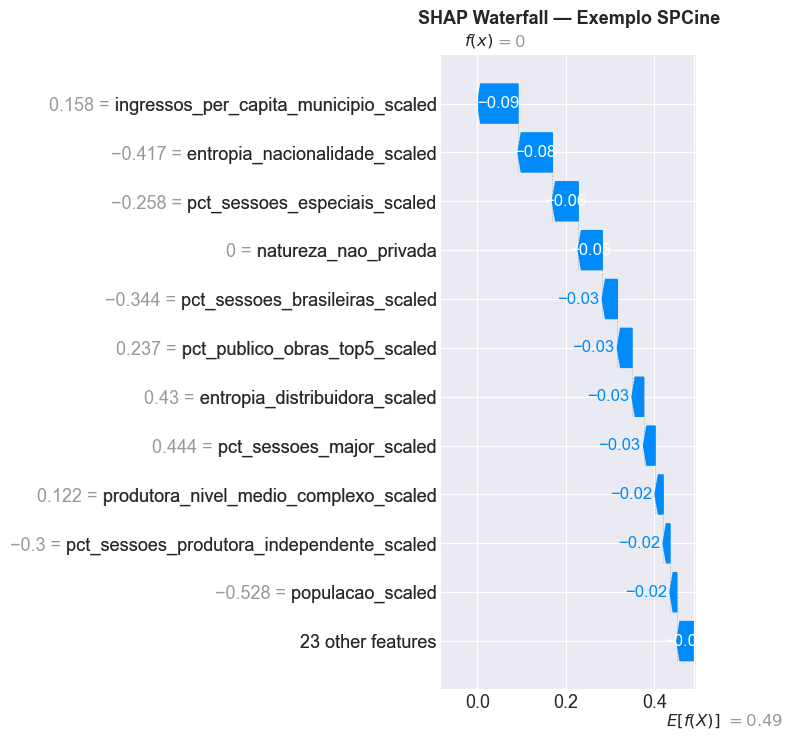


────────────────────────────────────────────────────────────────────────────────
EXPLICAÇÃO INDIVIDUAL — COMPLEXO NÃO-SPCINE
────────────────────────────────────────────────────────────────────────────────


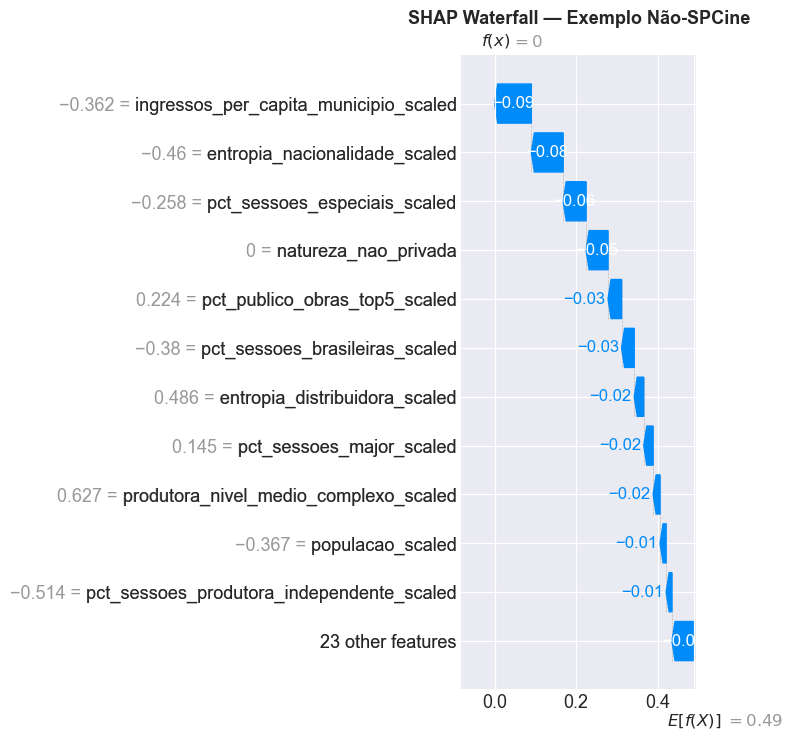


📌 Leitura direta:
  • Barras à direita → empurram para SPCine
  • Barras à esquerda → afastam de SPCine


In [71]:
# ================================================================================
# 7.4 - EXPLICAÇÃO INDIVIDUAL COM SHAP (WATERFALL)
# ================================================================================
print("=" * 80)
print("7.4 - EXPLICAÇÃO INDIVIDUAL COM SHAP (WATERFALL)")
print("=" * 80)

print("\n📍 Índices usados:")
print(f"  • Exemplo SPCine : idx = {idx_exemplo_spcine}")
print(f"  • Exemplo Demais : idx = {idx_exemplo_demais}")

# Preparar dados (X_train é numpy)
X_expl = X_train.copy()
feature_names = list(feature_names_shap)

# Base value (classe 1 = SPCine) de forma robusta
base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

# SHAP values da classe SPCine (classe 1) já normalizados na 7.2/7.3 (shape: n_amostras x n_features)
shap_values_spcine = shap_spcine

# -----------------------------
# Exemplo SPCine
# -----------------------------
print("\n" + "─" * 80)
print("EXPLICAÇÃO INDIVIDUAL — COMPLEXO SPCINE")
print("─" * 80)

exp_spcine = shap.Explanation(
    values=shap_values_spcine[idx_exemplo_spcine],
    base_values=base_val,
    data=X_expl[idx_exemplo_spcine],
    feature_names=feature_names
)

plt.figure(figsize=(11, 5))
shap.plots.waterfall(exp_spcine, max_display=12, show=False)
plt.title("SHAP Waterfall — Exemplo SPCine", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# -----------------------------
# Exemplo Demais
# -----------------------------
print("\n" + "─" * 80)
print("EXPLICAÇÃO INDIVIDUAL — COMPLEXO NÃO-SPCINE")
print("─" * 80)

exp_demais = shap.Explanation(
    values=shap_values_spcine[idx_exemplo_demais],
    base_values=base_val,
    data=X_expl[idx_exemplo_demais],
    feature_names=feature_names
)

plt.figure(figsize=(11, 5))
shap.plots.waterfall(exp_demais, max_display=12, show=False)
plt.title("SHAP Waterfall — Exemplo Não-SPCine", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n📌 Leitura direta:")
print("  • Barras à direita → empurram para SPCine")
print("  • Barras à esquerda → afastam de SPCine")
print("=" * 80)


# 8 Exportação de Artefatos

In [72]:
# ================================================================================
# 8.0 - EXPORTAÇÃO + VALIDAÇÃO DOS ARTEFATOS FINAIS (PADRÃO LEGADO: ../Bases)
# ================================================================================
import pickle
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

print("=" * 80)
print("8.0 - EXPORTAÇÃO + VALIDAÇÃO DOS ARTEFATOS FINAIS (PADRÃO LEGADO: ../Bases)")
print("=" * 80)

# ------------------------------------------------------------------------------
# 0) Diretórios (padrão legado)
# ------------------------------------------------------------------------------
BASES_DIR = Path("../Bases")
OUT_DIR = BASES_DIR / "Artefatos_NB4_1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n📁 Diretório legado BASES_DIR: {BASES_DIR.resolve()}")
print(f"📦 Subpasta de saída OUT_DIR:  {OUT_DIR.resolve()}")

# ------------------------------------------------------------------------------
# 1) Utilitário: pegar variáveis finais sem "adivinhar" na mão
# ------------------------------------------------------------------------------
def _pegar_var(candidatos, obrigatorio=True):
    for nome in candidatos:
        if nome in globals() and globals()[nome] is not None:
            return globals()[nome], nome
    if obrigatorio:
        raise NameError(f"Variável não encontrada. Procurei: {candidatos}")
    return None, None

# ------------------------------------------------------------------------------
# 2) Resolver objetos finais (padrão NB 4.1)
# ------------------------------------------------------------------------------
modelo, nome_modelo = _pegar_var(["hdbscan_model", "modelo_final", "modelo", "hdb"])
labels, nome_labels = _pegar_var(["labels_hdbscan", "labels_final", "labels"])
features_finais, nome_features = _pegar_var(["features_fase3", "feature_names_clean", "features_modelo", "features"])
df_clusters, nome_df = _pegar_var(["df_features_fase3", "df_features", "df_final", "df_treino"], obrigatorio=True)

probs, nome_probs = _pegar_var(["probs", "probabilidades", "probabilidades_hdb"], obrigatorio=False)
scaler, nome_scaler = _pegar_var(["scaler", "scaler_final", "scaler_continuas"], obrigatorio=False)

X_treino, nome_X = _pegar_var(["X_fase3", "X_train", "X_clean_normalized", "X_clean"], obrigatorio=False)

print("\n✅ Objetos resolvidos do ambiente:")
print(f"   • Modelo:  {nome_modelo}")
print(f"   • Labels:  {nome_labels}  (n={len(labels)})")
print(f"   • Features:{nome_features} (n={len(features_finais)})")
print(f"   • DF:      {nome_df}       (shape={df_clusters.shape})")
print(f"   • Probs:   {nome_probs if nome_probs else '—'}")
print(f"   • Scaler:  {nome_scaler if nome_scaler else '—'}")
print(f"   • X_treino:{nome_X if nome_X else '—'}")

# Garantir DataFrame pandas
if not isinstance(df_clusters, pd.DataFrame):
    raise TypeError(f"{nome_df} não é pandas.DataFrame. Tipo atual: {type(df_clusters)}")

# ------------------------------------------------------------------------------
# 3) Padronizar colunas mínimas no DF de clusters
# ------------------------------------------------------------------------------
# (i) cluster
if "cluster_hdbscan" not in df_clusters.columns:
    df_clusters["cluster_hdbscan"] = labels
# (ii) probabilidade (se existir)
if probs is not None and "probabilidade_hdb" not in df_clusters.columns:
    df_clusters["probabilidade_hdb"] = probs

# ------------------------------------------------------------------------------
# 4) Paths dos artefatos (contrato explícito)
# ------------------------------------------------------------------------------
MODELO_PATH   = OUT_DIR / "hdbscan_final.pkl"
SCALER_PATH   = OUT_DIR / "scaler_final.pkl"                 # opcional (se existir)
FEATURES_PATH = OUT_DIR / "features_finais.json"
LABELS_PATH   = OUT_DIR / "labels_treino.npy"
DF_PATH       = OUT_DIR / "df_clusters_final.parquet"
META_PATH     = OUT_DIR / "metadata_modelo.json"
PREP_PATH     = OUT_DIR / "preprocessamento_pipeline.json"   # opcional, mas útil

# ------------------------------------------------------------------------------
# 5) Exportação
# ------------------------------------------------------------------------------
print("\n" + "-" * 80)
print("📤 EXPORTANDO ARTEFATOS")
print("-" * 80)

# 5.1 Modelo
with open(MODELO_PATH, "wb") as f:
    pickle.dump(modelo, f)
print(f"✅ Modelo salvo: {MODELO_PATH}")

# 5.2 Scaler (se existir no notebook)
if scaler is not None:
    with open(SCALER_PATH, "wb") as f:
        pickle.dump(scaler, f)
    print(f"✅ Scaler salvo: {SCALER_PATH}")
else:
    print("⚠️ Scaler não encontrado no ambiente. (Não exportado)")

# 5.3 Features finais
with open(FEATURES_PATH, "w", encoding="utf-8") as f:
    json.dump(list(features_finais), f, indent=2, ensure_ascii=False)
print(f"✅ Features salvas: {FEATURES_PATH}")

# 5.4 Labels
np.save(LABELS_PATH, np.asarray(labels))
print(f"✅ Labels salvos: {LABELS_PATH}")

# 5.5 DataFrame final com clusters
df_clusters.to_parquet(DF_PATH, index=False)
print(f"✅ DF clusters salvo: {DF_PATH}")

# 5.6 Metadata (auditável)
metadata = {
    "notebook": "4.1_Refinamento",
    "algoritmo": type(modelo).__name__,
    "data_exportacao": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "n_amostras_treino": int(len(labels)),
    "n_features_modelo": int(len(features_finais)),
    "col_cluster_df": "cluster_hdbscan",
    "col_prob_df": "probabilidade_hdb" if "probabilidade_hdb" in df_clusters.columns else None,
    "observacoes": "Artefatos finais do refinamento (HDBSCAN + SHAP). Diretório legado ../Bases."
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✅ Metadata salva: {META_PATH}")

# 5.7 Pipeline de preprocessamento (opcional, mas ajuda NB5/validação 2025)
#     - captura escolhas que governam o "passado" (o que remover, etc.), se existirem.
pipeline = {}
for k in [
    "features_remover_fase3",
    "features_remover_fase2",
    "features_remover_fase1",
    "feature_names_clean",
    "features_continuas_idx",
    "features_nao_continuas_idx"
]:
    if k in globals() and globals()[k] is not None:
        obj = globals()[k]
        # serializar listas/ndarrays com segurança
        if isinstance(obj, (np.ndarray,)):
            pipeline[k] = obj.tolist()
        elif isinstance(obj, (list, tuple)):
            pipeline[k] = list(obj)
        else:
            try:
                pipeline[k] = list(obj)
            except Exception:
                pipeline[k] = str(obj)

with open(PREP_PATH, "w", encoding="utf-8") as f:
    json.dump(pipeline, f, indent=2, ensure_ascii=False)
print(f"✅ Pipeline preprocessamento salvo: {PREP_PATH}")

# ------------------------------------------------------------------------------
# 6) Validação (reload + consistência)
# ------------------------------------------------------------------------------
print("\n" + "-" * 80)
print("🔎 VALIDAÇÃO DOS ARTEFATOS EXPORTADOS")
print("-" * 80)

# 6.1 Existência
necessarios = [MODELO_PATH, FEATURES_PATH, LABELS_PATH, DF_PATH, META_PATH, PREP_PATH]
faltando = [p for p in necessarios if not p.exists()]
if faltando:
    raise FileNotFoundError("Arquivos faltando após exportação:\n" + "\n".join([str(p) for p in faltando]))
print("✅ Todos os arquivos foram gerados.")

# 6.2 Reload básico
with open(MODELO_PATH, "rb") as f:
    modelo_ck = pickle.load(f)

with open(FEATURES_PATH, "r", encoding="utf-8") as f:
    features_ck = json.load(f)

labels_ck = np.load(LABELS_PATH)
df_ck = pd.read_parquet(DF_PATH)

print(f"\n✅ Reload OK:")
print(f"   • Modelo:  {type(modelo_ck).__name__}")
print(f"   • Features:{len(features_ck)}")
print(f"   • Labels:  {len(labels_ck)}")
print(f"   • DF:      {df_ck.shape}")

# 6.3 Consistências-chave
if len(labels_ck) != len(df_ck):
    raise ValueError(f"Inconsistência: labels ({len(labels_ck)}) != linhas DF ({len(df_ck)})")

if "cluster_hdbscan" not in df_ck.columns:
    raise ValueError("DF exportado não contém coluna 'cluster_hdbscan'")

# comparar labels com DF (mesma ordem)
labels_df = df_ck["cluster_hdbscan"].to_numpy()
if not np.array_equal(labels_ck, labels_df):
    # tolerar apenas se DF foi reordenado por acidente
    raise ValueError("Labels salvos != coluna cluster_hdbscan do DF (ordem/consistência quebrada)")

# checar features x matriz X (se disponível)
if X_treino is not None:
    X_np = np.asarray(X_treino)
    if X_np.ndim == 2 and X_np.shape[1] != len(features_ck):
        raise ValueError(f"Inconsistência: X_treino tem {X_np.shape[1]} colunas, mas features_ck tem {len(features_ck)}")

print("\n📊 Distribuição de clusters (treino):")
dist = pd.Series(labels_ck).value_counts(dropna=False).sort_index()
print(dist.to_string())

print("\n" + "=" * 80)
print("✅ EXPORTAÇÃO E VALIDAÇÃO CONCLUÍDAS COM SUCESSO")
print("=" * 80)
print("\nArquivos gerados:")
for p in necessarios + ([SCALER_PATH] if scaler is not None else []):
    if p.exists():
        print(f"  • {p}")


8.0 - EXPORTAÇÃO + VALIDAÇÃO DOS ARTEFATOS FINAIS (PADRÃO LEGADO: ../Bases)

📁 Diretório legado BASES_DIR: C:\Users\Guilherme\OneDrive\Cursos\ENAP\MBA em Inteligência Artificial\Disciplinas\21 - Machine Learning\Trabalho Final\bases
📦 Subpasta de saída OUT_DIR:  C:\Users\Guilherme\OneDrive\Cursos\ENAP\MBA em Inteligência Artificial\Disciplinas\21 - Machine Learning\Trabalho Final\bases\Artefatos_NB4_1

✅ Objetos resolvidos do ambiente:
   • Modelo:  hdbscan_model
   • Labels:  labels_hdbscan  (n=875)
   • Features:features_fase3 (n=34)
   • DF:      df_features_fase3       (shape=(875, 43))
   • Probs:   probs
   • Scaler:  scaler
   • X_treino:X_fase3

--------------------------------------------------------------------------------
📤 EXPORTANDO ARTEFATOS
--------------------------------------------------------------------------------
✅ Modelo salvo: ..\Bases\Artefatos_NB4_1\hdbscan_final.pkl
✅ Scaler salvo: ..\Bases\Artefatos_NB4_1\scaler_final.pkl
✅ Features salvas: ..\Bases\Artefato

# Conclusão
O refinamento do modelo confirmou a existência de uma separação estrutural consistente entre os complexos exibidores, com destaque para o grupo associado ao perfil público/cultural (SPCine), que não é explicado por variáveis triviais de escala ou volume. A combinação de HDBSCAN com análise de explicabilidade (SHAP) mostrou que a diferenciação decorre principalmente de características de diversidade, perfil de programação e natureza institucional.

Os artefatos finais foram consolidados e exportados de forma reprodutível, permitindo a reaplicação direta do modelo em novos períodos. Com isso, o trabalho está preparado para a etapa seguinte de validação temporal, avaliando a estabilidade dos clusters no conjunto de dados de 2025 sem reestimativa do modelo.